Univariate analysis for the FLT 7T tone learning dataset. Features of this notebook include:
- `grouped_runs`: Early vs. middle vs. final learning stages
- across striatal and cortical regions of interest
- for both `sound-vs-baseline` and `fb-correct-vs-incorrect` BOLD contrasts
- brain–behavior correlations for each analysis

# Imports and definitions

In [1]:
import os
import sys
import json
import argparse

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
import seaborn as sns

from glob import glob
from nilearn.glm.second_level import SecondLevelModel
from nilearn.glm.second_level import make_second_level_design_matrix
from nilearn.image import threshold_img, resample_to_img, binarize_img
from nilearn.glm import threshold_stats_img

In [2]:
from nilearn.masking import apply_mask
from scipy import stats

In [3]:
import statsmodels.api as sm
import pingouin as pg

from statsmodels.formula.api import ols
from statsmodels.stats.anova import AnovaRM

from statsmodels.stats.multitest import multipletests
from scipy.stats import ttest_1samp, ttest_rel

In [4]:
import sys
sys.path.insert(0, '..')   # where stats_fmt.py lives relative to the notebook
from stats_fmt import fmt_t, fmt_F, fmt_p, fmt_r, stat_str, fmt_pingouin_anova
from stats_fmt import export_anova, export_posthoc, export_ttests


In [5]:
# print stats as human-readable
pd.set_option('display.float_format', '{:.4f}'.format)

In [6]:
from nilearn import plotting, datasets, surface

# for plotting slices
mni152_template = datasets.load_mni152_template(resolution=1)
# for plotting on surface
fsaverage = datasets.fetch_surf_fsaverage('fsaverage')

[fetch_surf_fsaverage] Dataset found in /ihome/bchandrasekaran/krs228/nilearn_data/fsaverage


In [7]:
task_label = 'tonecat'
fwhm = 0.00
space_label = 'MNI152NLin2009cAsym'

# define data directories
bidsroot = os.path.join('/bgfs/bchandrasekaran/krs228/data/', 
                        'FLT/',
                        'data_denoised', #'data_bids'
                       )
nilearn_dir = os.path.join(bidsroot, 'derivatives', 'nilearn')
masks_dir = os.path.join(nilearn_dir, 'masks')
# define first-level directory where group-level inputs will be pulled from
l1_dir = os.path.join(nilearn_dir, 'level-1_fwhm-%.02f'%fwhm)

# create output directory
group_out_dir = os.path.join(nilearn_dir, 'group_fwhm-%.02f'%fwhm)
if not os.path.exists(group_out_dir):
        os.makedirs(group_out_dir)
        
deriv_dir = group_out_dir

In [8]:
bidsroot

'/bgfs/bchandrasekaran/krs228/data/FLT/data_denoised'

In [9]:
contrast_list = ['sound', 'resp', 'fb-correct-vs-wrong']

Based on [nilearn documentation](https://nilearn.github.io/stable/auto_examples/05_glm_second_level/plot_thresholding.html#statistical-testing-of-a-second-level-analysis)

### Build the group-level design matrix

#### Read the `participants.tsv` file from the BIDS root directory

In [10]:
participants_fpath = os.path.join(bidsroot, 'participants.tsv')
participants_df = pd.read_csv(participants_fpath, sep='\t')

# subjects to ignore (not fully processed, etc.)
ignore_subs = ['sub-FLT27', # always leave out FLT27 – did not participate
               'sub-FLT07', # bad QA 11/14/23
              ]
participants_df.drop(participants_df[participants_df.participant_id.isin(ignore_subs)].index, inplace=True)

# re-sort by participant ID
participants_df.sort_values(by=['participant_id'], ignore_index=True, inplace=True)

In [11]:
print(participants_df)

   participant_id  age sex         group    FFR_id
0       sub-FLT02   21   F  non-Mandarin 1002.0000
1       sub-FLT03   25   F      Mandarin 2002.0000
2       sub-FLT04   21   F  non-Mandarin 1003.0000
3       sub-FLT05   26   M      Mandarin 3010.0000
4       sub-FLT06   21   F  non-Mandarin 3001.0000
5       sub-FLT08   23   F      Mandarin 2005.0000
6       sub-FLT09   30   F  non-Mandarin 3002.0000
7       sub-FLT10   23   F      Mandarin 2006.0000
8       sub-FLT11   20   F  non-Mandarin 1005.0000
9       sub-FLT12   20   F  non-Mandarin 3004.0000
10      sub-FLT13   23   F  non-Mandarin 3005.0000
11      sub-FLT14   23   M  non-Mandarin 3006.0000
12      sub-FLT15   22   M      Mandarin 2010.0000
13      sub-FLT17   29   F      Mandarin       NaN
14      sub-FLT18   24   M      Mandarin 2016.0000
15      sub-FLT19   24   M      Mandarin 2018.0000
16      sub-FLT20   26   F  non-Mandarin 3008.0000
17      sub-FLT21   21   M      Mandarin 2011.0000
18      sub-FLT22   41   F     

In [12]:
participants_nman_df = participants_df[participants_df.group=='non-Mandarin'].reset_index(drop=True)
print(participants_nman_df)

   participant_id  age sex         group    FFR_id
0       sub-FLT02   21   F  non-Mandarin 1002.0000
1       sub-FLT04   21   F  non-Mandarin 1003.0000
2       sub-FLT06   21   F  non-Mandarin 3001.0000
3       sub-FLT09   30   F  non-Mandarin 3002.0000
4       sub-FLT11   20   F  non-Mandarin 1005.0000
5       sub-FLT12   20   F  non-Mandarin 3004.0000
6       sub-FLT13   23   F  non-Mandarin 3005.0000
7       sub-FLT14   23   M  non-Mandarin 3006.0000
8       sub-FLT20   26   F  non-Mandarin 3008.0000
9       sub-FLT25   19   F  non-Mandarin 1013.0000
10      sub-FLT28   23   F  non-Mandarin       NaN
11      sub-FLT30   25   M  non-Mandarin       NaN


In [13]:
# create group-specific lists of subject IDs
sub_list_mand = list(participants_df.participant_id[participants_df.group=='Mandarin'])
sub_list_nman = list(participants_df.participant_id[participants_df.group=='non-Mandarin'])

In [14]:
print(sub_list_nman)

['sub-FLT02', 'sub-FLT04', 'sub-FLT06', 'sub-FLT09', 'sub-FLT11', 'sub-FLT12', 'sub-FLT13', 'sub-FLT14', 'sub-FLT20', 'sub-FLT25', 'sub-FLT28', 'sub-FLT30']


### Define region dictionary

In [15]:
region_dict = {'auditory': [
                        'L-HG', 'L-PT',  'L-PP', 
                        'L-STGp', 'L-STGa', 
                        'L-ParsOp', 'L-ParsTri',
                        'R-HG', 'R-PT',  'R-PP', 
                        'R-STGp', 'R-STGa', 
                        'R-ParsOp', 'R-ParsTri', 
                          ],
                'tian-S2': [
                    #'pGP-rh', 'pGP-lh',
                    #'aGP-rh', 'aGP-lh',
                    'aCAU-lh',
                    'pCAU-lh',
                    'aPUT-lh',
                    'pPUT-lh',
                    #'NAc-shell-lh',
                    #'NAc-core-lh',
                    'aCAU-rh',
                    'pCAU-rh',
                    'aPUT-rh',
                    'pPUT-rh',
                    #'NAc-shell-rh',
                    #'NAc-core-rh',
                    ],
                'tian-S3': [
                        'CAU-DA-lh', 'CAU-DA-rh', 
                        'CAU-VA-lh', 'CAU-VA-rh', 
                        'pCAU-lh', 'pCAU-rh', 
                        'PUT-DA-lh', 'PUT-DA-rh', 
                        'PUT-DP-lh', 'PUT-DP-rh', 
                        'PUT-VA-lh', 'PUT-VA-rh', 
                        'PUT-VP-lh', 'PUT-VP-rh',
                        'NAc-core-lh',  'NAc-core-rh', 
                        'NAc-shell-lh', 'NAc-shell-rh', 
                         #'aGP-lh', 'pGP-lh', 
                         #'aGP-rh', 'pGP-rh',         
                               ],
           }
network_list  = list(region_dict.keys())
print('network_list:', network_list)

network_list: ['auditory', 'tian-S2', 'tian-S3']


### define key processing functions

In [16]:
# mask stat maps
def mask_stat_maps(region_list, statmap_dict, masks_dir, network_name, space_label):
    roi_mean_dict = {}
    mask_path_list = []
    if network_name=='auditory':
        new_network_name = 'dseg'
    else:
        new_network_name = network_name
    
    for rx, region in enumerate(region_list):
        print(region)
        roi_mean_list = []

        for sub_id in statmap_dict:
            stat_fpath = statmap_dict[sub_id]
            mask_fpath = glob(masks_dir + f'/{sub_id}/space-{space_label}/masks-{new_network_name}/*{region}*.nii.gz')[0]
            print(mask_fpath)
            #print(nib.load(mask_fpath).get_fdata().shape)
            
            mask_img = resample_to_img(mask_fpath, stat_fpath, 
                                       interpolation='nearest',
                                       force_resample=True, 
                                       copy_header=True)
            mask_img = binarize_img(mask_img, two_sided=False, copy_header=True)
            masked_data = apply_mask(stat_fpath, mask_img)
            roi_mean_sub = masked_data.mean()
            

            roi_mean_list.append(roi_mean_sub)

        # save mask_fpaths for later
        mask_path_list.append(mask_fpath)
        
        
        roi_mean_dict[region] = roi_mean_list
    
    return roi_mean_dict, mask_path_list

In [17]:
# create ROI dataframe from dictionary
def make_stats_df(roi_mean_dict, participants_df, network_name):
    roi_df = pd.DataFrame.from_dict(roi_mean_dict)

    roi_df['participant_id'] = participants_df.participant_id
    roi_df['participant_group'] = participants_df.group

    roi_df_long = roi_df.melt(id_vars=["participant_id", "participant_group"], 
                              var_name="region", value_name="beta")

    # create new `hemisphere` column
    if network_name == 'auditory':
        roi_df_long['region_hemi'] = roi_df_long.region
        roi_df_long['hemisphere'] = roi_df_long.region.str[0]
        roi_df_long['region'] = roi_df_long.region.str[2:]
    else: #if network_name == ('tian_subcortical_S3' or 'tian_subcortical_S2'):
        roi_df_long['region_hemi'] = roi_df_long.region
        roi_df_long['hemisphere'] = roi_df_long.region.str[-2:]
        roi_df_long['region'] = roi_df_long.region.str[:-3]

    # Filter for non-Mandarin participants
    #stats_df = roi_df_long[roi_df_long['participant_group'] == 'non-Mandarin']
    
    return roi_df_long # stats_df

In [18]:
# Calculate hemisphere-averaged ROI beta values and create a new dataframe
def bilateral_mean(df):
    return (df.groupby(['participant_id', 'participant_group', 'region', 'learning_stage'], 
                       as_index=False)
              ['beta']
              .mean())

In [19]:
# plot ROI box plots
def plot_roi_box_plots(stats_df):
    fig, ax = plt.subplots(1, 1, figsize=(6,4), dpi=300)
    yrange = [-6, 4.5]

    # Define a color palette
    #palette = ['#e66101', '#5e3c99']  # Example colors, adjust as needed

    # Create the swarm plot with transparent dots
    sns.stripplot(data=stats_df, 
                  x='region', y='beta', 
                  hue='hemisphere',
                  dodge=True,
                  linewidth=0.5,
                  size=3,
                  #alpha=0.6,
                  #palette=palette,  # Use the defined color palette
                  legend=None,
                  ax=ax,
                  zorder=2)  # Lower zorder for the strip plot

    # Make the swarm plot dots transparent
    for collection in ax.collections:
        collection.set_facecolor('none')

    # Create the box plot with colors
    sns.boxplot(data=stats_df, 
                x='region', y='beta', 
                hue='hemisphere',
                dodge=True,
                linewidth=1,
                fliersize=0,
                #palette=palette,  # Use the same color palette
                #legend=None,
                ax=ax,
                zorder=1)  # Higher zorder for the box plot

    #ax.set_ylim(yrange)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center')
    sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
    ax.set_title(f'{contrast_label}')

    # Extend the horizontal dashed line at y=0
    ax.axhline(y=0, color='0.5', linestyle='--', linewidth=0.5)

    fig.tight_layout()
    
    return fig

In [20]:
# plot ROI-mean values on the brain
def plot_roi_slices(roi_mean_dict, mask_path_list, network_name, space_label):
    from nilearn.image import new_img_like
    from nilearn import plotting

    roi_stat_data_list = []
    for rx, region in enumerate(roi_mean_dict):
        print('region:', region)
        mask_fpath = glob(masks_dir + f'/*/space-{space_label}/masks-{network_name}/*{region}*.nii.gz')[0]
        #mask_fpath = region
        #roi_img = nib.load(mask_fpath)
        #roi_data = roi_img.get_fdata()
        
        #roi_img = resample_to_img(mask_fpath, stat_fpath, 
        #                           interpolation='nearest',
        #                           force_resample=True, 
        #                           copy_header=True)
        roi_img = binarize_img(mask_fpath, two_sided=False)
        #roi_data = apply_mask(stat_fpath, roi_img)
        roi_data = roi_img.get_fdata()
        
        roi_stat = np.mean(roi_mean_dict[region])
        #roi_stat = roi_mean_dict.loc[roi_mean_dict['region_hemi'] == 'region', 'beta'].mean()
        roi_stat_data = roi_data * roi_stat

        roi_stat_data_list.append(roi_stat_data)
    
    # add maps together and make nifti img
    roi_stat_map_data = sum(roi_stat_data_list)
    roi_stat_map_img = new_img_like(roi_img, roi_stat_map_data)

    fig, ax = plt.subplots(figsize=(8,3), dpi=300)
    plotting.plot_stat_map(roi_stat_map_img,
                           bg_img=mni152_template,
                           black_bg=False,
                           annotate=False, draw_cross=False,
                           symmetric_cbar=True,
                           cmap='coolwarm',
                           axes=ax)
    #fig.suptitle(title);
    
    return fig

In [21]:
def plot_roi_slices_avg(roi_mean_dict_list, mask_path_list, network_name, space_label):
    from nilearn.image import new_img_like
    from nilearn import plotting

    roi_stat_data_list = []
    all_regions = roi_mean_dict_list[0].keys()  # assumes all dicts share the same regions

    for region in all_regions:
        print('region:', region)
        mask_fpath = glob(masks_dir + f'/*/space-{space_label}/masks-{network_name}/*{region}*.nii.gz')[0]
        roi_img = binarize_img(mask_fpath, two_sided=False)
        roi_data = roi_img.get_fdata()

        # Compute mean across all stages for this region
        roi_stat_values = [roi_dict[region] for roi_dict in roi_mean_dict_list]
        roi_stat = np.mean(roi_stat_values)

        roi_stat_data = roi_data * roi_stat
        roi_stat_data_list.append(roi_stat_data)

    # Combine all ROI maps
    roi_stat_map_data = sum(roi_stat_data_list)
    roi_stat_map_img = new_img_like(roi_img, roi_stat_map_data)

    fig, ax = plt.subplots(figsize=(8,3), dpi=300)
    plotting.plot_stat_map(roi_stat_map_img,
                           bg_img=mni152_template,
                           black_bg=False,
                           annotate=False, draw_cross=False,
                           symmetric_cbar=True,
                           cmap='coolwarm',
                           axes=ax)
    ax.set_title('Mean response across learning stages')
    return fig


In [22]:
def plot_roi_slices_diff(roi_mean_dict_stage1, roi_mean_dict_stage2, mask_path_list, network_name, space_label):
    from nilearn.image import new_img_like
    from nilearn import plotting

    roi_stat_data_list = []
    all_regions = roi_mean_dict_stage1.keys()  # assumes both dicts share the same regions

    for region in all_regions:
        print('region:', region)
        mask_fpath = glob(masks_dir + f'/*/space-{space_label}/masks-{network_name}/*{region}*.nii.gz')[0]
        roi_img = binarize_img(mask_fpath, two_sided=False)
        roi_data = roi_img.get_fdata()

        # Compute difference between stages
        roi_stat_stage1 = np.mean(roi_mean_dict_stage1[region])
        roi_stat_stage2 = np.mean(roi_mean_dict_stage2[region])
        roi_stat_diff = roi_stat_stage2 - roi_stat_stage1


        roi_stat_data = roi_data * roi_stat_diff
        roi_stat_data_list.append(roi_stat_data)

    # Combine all ROI maps
    roi_stat_map_data = sum(roi_stat_data_list)
    roi_stat_map_img = new_img_like(roi_img, roi_stat_map_data)

    fig, ax = plt.subplots(figsize=(8,3), dpi=300)
    plotting.plot_stat_map(roi_stat_map_img,
                           bg_img=mni152_template,
                           black_bg=False,
                           annotate=False, draw_cross=False,
                           symmetric_cbar=True,
                           cmap='coolwarm',
                           axes=ax)
    ax.set_title('Response difference across learning stages')
    return fig


## Load behavioral accuracy outputs for brain-behavior correlations

In [23]:
beh_out_dir = os.path.join(bidsroot, 'derivatives', 'behavior')
acc_df = pd.read_csv(os.path.join(beh_out_dir, 'run_accuracies.tsv'), sep='\t')

In [24]:
acc_df.sort_values(by=['participant_id', 'run'], inplace=True)
acc_df.head(10)

,participant_id,run,accuracy
78,sub-FLT02,run-01,0.4028
79,sub-FLT02,run-02,0.8636
80,sub-FLT02,run-03,0.8500
81,sub-FLT02,run-04,0.8250
82,sub-FLT02,run-05,0.9129
83,sub-FLT02,run-06,0.8958
0,sub-FLT03,run-01,0.9792
1,sub-FLT03,run-02,1.0000
2,sub-FLT03,run-03,0.9792
3,sub-FLT03,run-04,1.0000


mean accuracy = 0.7959


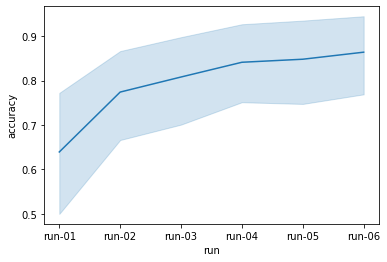

In [25]:
print(f'mean accuracy = {acc_df.accuracy.mean():.04f}')
sns.lineplot(acc_df, x='run', y='accuracy');

## `contrast-sound` for striatal network

In [26]:
# get the beta map for the contrast of interest for each subject
network_name = network_list[1]
contrast_label = contrast_list[0]

statmap_earlythird_dict = {}
for sub_id in sub_list_nman:
    statmap_earlythird_dict[sub_id] = sorted(glob(l1_dir+f'/{sub_id}_space-{space_label}/grouped_runs/earlythird/*{contrast_label}_map-beta.nii.gz'))[0]
    
statmap_middlethird_dict = {}
for sub_id in sub_list_nman:
    statmap_middlethird_dict[sub_id] = sorted(glob(l1_dir+f'/{sub_id}_space-{space_label}/grouped_runs/middlethird/*{contrast_label}_map-beta.nii.gz'))[0]
    
statmap_latethird_dict = {}
for sub_id in sub_list_nman:
    statmap_latethird_dict[sub_id] = sorted(glob(l1_dir+f'/{sub_id}_space-{space_label}/grouped_runs/latethird/*{contrast_label}_map-beta.nii.gz'))[0]

In [27]:
# mask the stat maps per learning stage by region - ONLY RUN ONCE
'''
print(f'masking {contrast_label} stat maps for the {network_name} network')

print(f'creating dictionary for early learning stage')
roi_earlythird_mean_dict, mask_path_list = mask_stat_maps(region_dict[network_name], 
                                               statmap_earlythird_dict, 
                                               masks_dir, 
                                               network_name,
                                               space_label)

print(f'creating dictionary for middle learning stage')
roi_middlethird_mean_dict, mask_path_list = mask_stat_maps(region_dict[network_name], 
                                               statmap_middlethird_dict, 
                                               masks_dir, 
                                               network_name,
                                               space_label)

print(f'creating dictionary for final learning stage')
roi_latethird_mean_dict, mask_path_list = mask_stat_maps(region_dict[network_name], 
                                               statmap_latethird_dict, 
                                               masks_dir, 
                                               network_name,
                                               space_label)

# add `learning_stage` column and combine into single dataframe
roi_earlythird_df_long = make_stats_df(roi_earlythird_mean_dict, participants_nman_df, network_name)
roi_earlythird_df_long['learning_stage'] = 'early'
roi_middlethird_df_long = make_stats_df(roi_middlethird_mean_dict, participants_nman_df, network_name)
roi_middlethird_df_long['learning_stage'] = 'middle'
roi_latethird_df_long = make_stats_df(roi_latethird_mean_dict, participants_nman_df, network_name)
roi_latethird_df_long['learning_stage'] = 'final'

# combine into a single long dataframe
roi_df_long = pd.concat([roi_earlythird_df_long, roi_middlethird_df_long, roi_latethird_df_long],)

# save the DataFrame for easier access
out_fname = f'univariate-results_network-{network_name}_contrast-{contrast_label}.tsv'
roi_df_long.to_csv(os.path.join(group_out_dir, out_fname), sep='\t', index=False)
'''

"\nprint(f'masking {contrast_label} stat maps for the {network_name} network')\n\nprint(f'creating dictionary for early learning stage')\nroi_earlythird_mean_dict, mask_path_list = mask_stat_maps(region_dict[network_name], \n                                               statmap_earlythird_dict, \n                                               masks_dir, \n                                               network_name,\n                                               space_label)\n\nprint(f'creating dictionary for middle learning stage')\nroi_middlethird_mean_dict, mask_path_list = mask_stat_maps(region_dict[network_name], \n                                               statmap_middlethird_dict, \n                                               masks_dir, \n                                               network_name,\n                                               space_label)\n\nprint(f'creating dictionary for final learning stage')\nroi_latethird_mean_dict, mask_path_list = mask_stat_map

In [28]:
# load the DataFrame if already exists
out_fname = f'univariate-results_network-{network_name}_contrast-{contrast_label}.tsv'
roi_df_long = pd.read_csv(os.path.join(group_out_dir, out_fname), sep='\t')

# create a bilateral-averaged dataframe (for across-contrast analysis)
sound_striatum_df = bilateral_mean(roi_df_long)


In [29]:
roi_df_long.participant_id.unique()

array(['sub-FLT02', 'sub-FLT04', 'sub-FLT06', 'sub-FLT09', 'sub-FLT11',
       'sub-FLT12', 'sub-FLT13', 'sub-FLT14', 'sub-FLT20', 'sub-FLT25',
       'sub-FLT28', 'sub-FLT30'], dtype=object)

In [30]:
roi_df_long.region.unique()

array(['aCAU', 'pCAU', 'aPUT', 'pPUT'], dtype=object)

In [31]:
print(network_name)
non_mandarin_df = roi_df_long.copy()

# create a new column based on rostral–caudal axis
non_mandarin_df['Axis'] = ''

if network_name == 'tian-S3':
    non_mandarin_df.loc[(non_mandarin_df['region']=='pCAU'),   'Axis'] = 'Caudal'
    non_mandarin_df.loc[(non_mandarin_df['region']=='PUT-VP'), 'Axis'] = 'Caudal'
    non_mandarin_df.loc[(non_mandarin_df['region']=='PUT-DP'), 'Axis'] = 'Caudal'

    non_mandarin_df.loc[non_mandarin_df['region']=='CAU-DA', 'Axis'] = 'Rostral'
    non_mandarin_df.loc[non_mandarin_df['region']=='CAU-VA', 'Axis'] = 'Rostral'
    non_mandarin_df.loc[non_mandarin_df['region']=='CAU-DP', 'Axis'] = 'Rostral'
    non_mandarin_df.loc[non_mandarin_df['region']=='CAU-VP', 'Axis'] = 'Rostral'

    non_mandarin_df.loc[non_mandarin_df['region']=='PUT-VA', 'Axis'] = 'Rostral'
    non_mandarin_df.loc[non_mandarin_df['region']=='PUT-DA', 'Axis'] = 'Rostral'

    non_mandarin_df.loc[non_mandarin_df['region']=='NAc-shell', 'Axis'] = 'Ventral'
    non_mandarin_df.loc[non_mandarin_df['region']=='NAc-core', 'Axis'] = 'Ventral'

elif network_name == 'tian-S2':
    non_mandarin_df.loc[(non_mandarin_df['region']=='pCAU'), 'Axis'] = 'Caudal'
    non_mandarin_df.loc[(non_mandarin_df['region']=='pPUT'), 'Axis'] = 'Caudal'    
    
    non_mandarin_df.loc[(non_mandarin_df['region']=='aCAU'), 'Axis'] = 'Rostral'
    non_mandarin_df.loc[(non_mandarin_df['region']=='aPUT'), 'Axis'] = 'Rostral'    

    non_mandarin_df.loc[non_mandarin_df['region']=='NAc-shell', 'Axis'] = 'Ventral'
    non_mandarin_df.loc[non_mandarin_df['region']=='NAc-core', 'Axis'] = 'Ventral'

non_mandarin_df.head()

tian-S2


,participant_id,participant_group,region,beta,region_hemi,hemisphere,learning_stage,Axis
0,sub-FLT02,non-Mandarin,aCAU,0.3118,aCAU-lh,lh,early,Rostral
1,sub-FLT04,non-Mandarin,aCAU,6.6399,aCAU-lh,lh,early,Rostral
2,sub-FLT06,non-Mandarin,aCAU,2.1960,aCAU-lh,lh,early,Rostral
3,sub-FLT09,non-Mandarin,aCAU,6.1937,aCAU-lh,lh,early,Rostral
4,sub-FLT11,non-Mandarin,aCAU,2.4432,aCAU-lh,lh,early,Rostral


In [32]:
non_mandarin_df.region_hemi.unique()

array(['aCAU-lh', 'pCAU-lh', 'aPUT-lh', 'pPUT-lh', 'aCAU-rh', 'pCAU-rh',
       'aPUT-rh', 'pPUT-rh'], dtype=object)

In [33]:
non_mandarin_df.participant_id.unique()

array(['sub-FLT02', 'sub-FLT04', 'sub-FLT06', 'sub-FLT09', 'sub-FLT11',
       'sub-FLT12', 'sub-FLT13', 'sub-FLT14', 'sub-FLT20', 'sub-FLT25',
       'sub-FLT28', 'sub-FLT30'], dtype=object)

In [34]:
# right now, requires separate dictionaries per learning stage
# could be re-written to take roi_df_long or similar
'''
fig = plot_roi_slices_avg([roi_earlythird_mean_dict, roi_middlethird_mean_dict, roi_latethird_mean_dict],
                          mask_path_list, network_name, space_label)
'''

'\nfig = plot_roi_slices_avg([roi_earlythird_mean_dict, roi_middlethird_mean_dict, roi_latethird_mean_dict],\n                          mask_path_list, network_name, space_label)\n'

In [35]:
plot_order = ['aCAU', 'pCAU', 'aPUT', 'pPUT']

/scratch/slurm-8704965/ipykernel_4038713/441903246.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center')


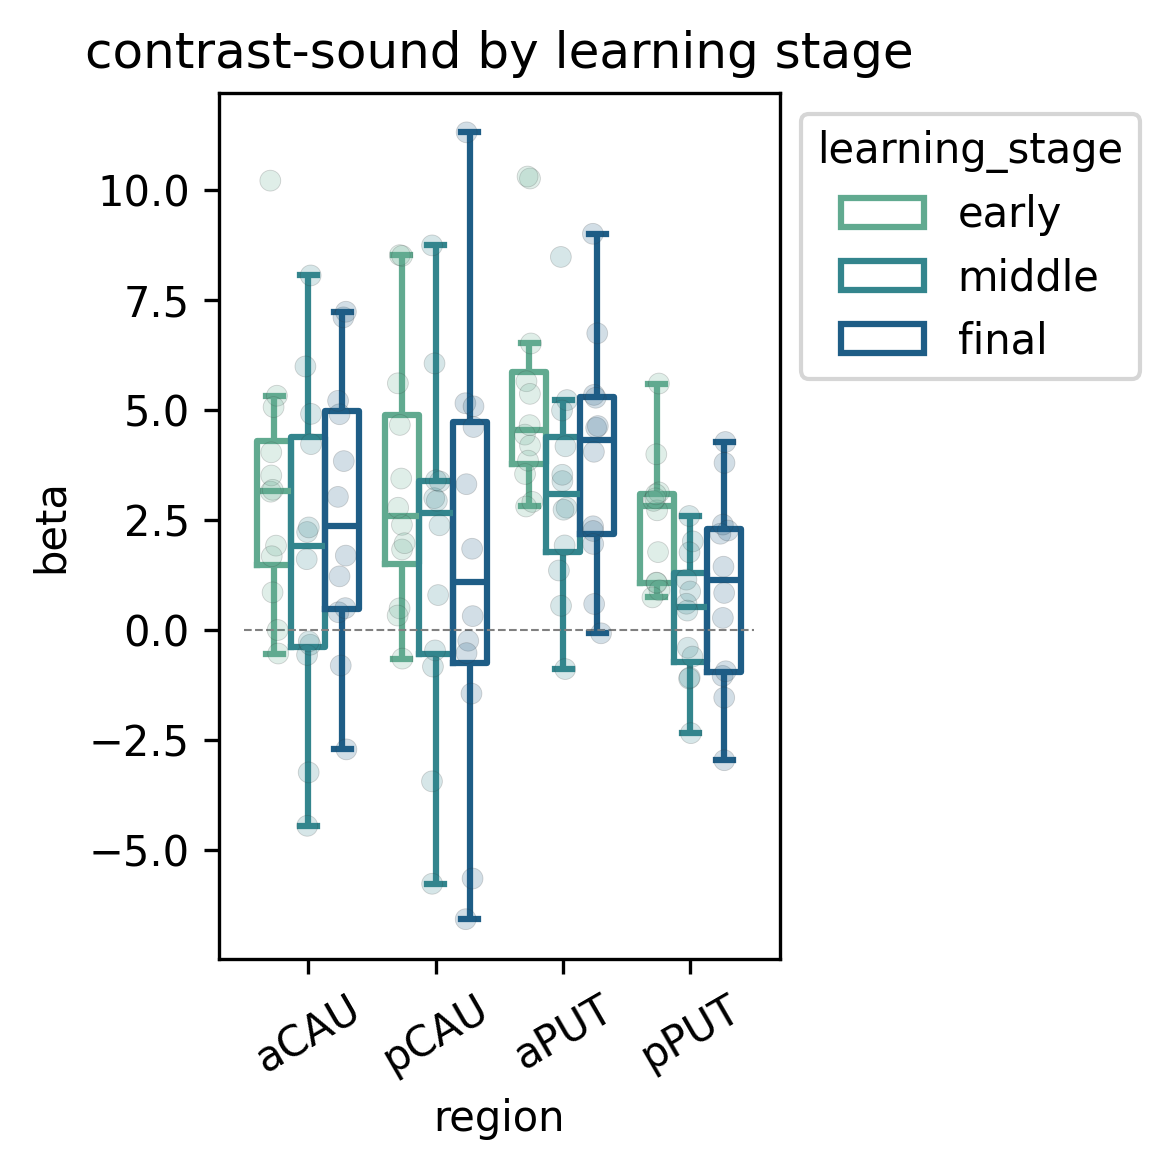

In [36]:
fig, ax = plt.subplots(1, 1, figsize=(4,4), dpi=300)

roi_df_collapsed = roi_df_long.groupby(["participant_id", "region", 'learning_stage'], 
                                       as_index=False).agg({"beta": "mean"})

sns.boxplot(data=roi_df_collapsed, 
              x='region', y='beta', 
              hue='learning_stage', hue_order=['early', 'middle', 'final'],
              order=plot_order,
              palette='crest',
              fliersize = 0,            
              linewidth=1.5,
              fill=False,
              #legend=None,
              ax=ax);
sns.stripplot(data=roi_df_collapsed, 
              x='region', y='beta', 
              hue='learning_stage', hue_order=['early', 'middle', 'final'],
              order=plot_order,
              palette='crest',
              dodge=True,
              linewidth=0.2,
              alpha=.2,
              legend=None,
              ax=ax);


xmin, xmax = ax.get_xlim()
ax.hlines(y=0, xmin=xmin, xmax=xmax, color='0.5', linestyle='--', linewidth=0.5)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_title(f'contrast-{contrast_label} by learning stage');
#ax.set_ylim([-5, 5])

fig.tight_layout()


/scratch/slurm-8704965/ipykernel_4038713/3760441519.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center')


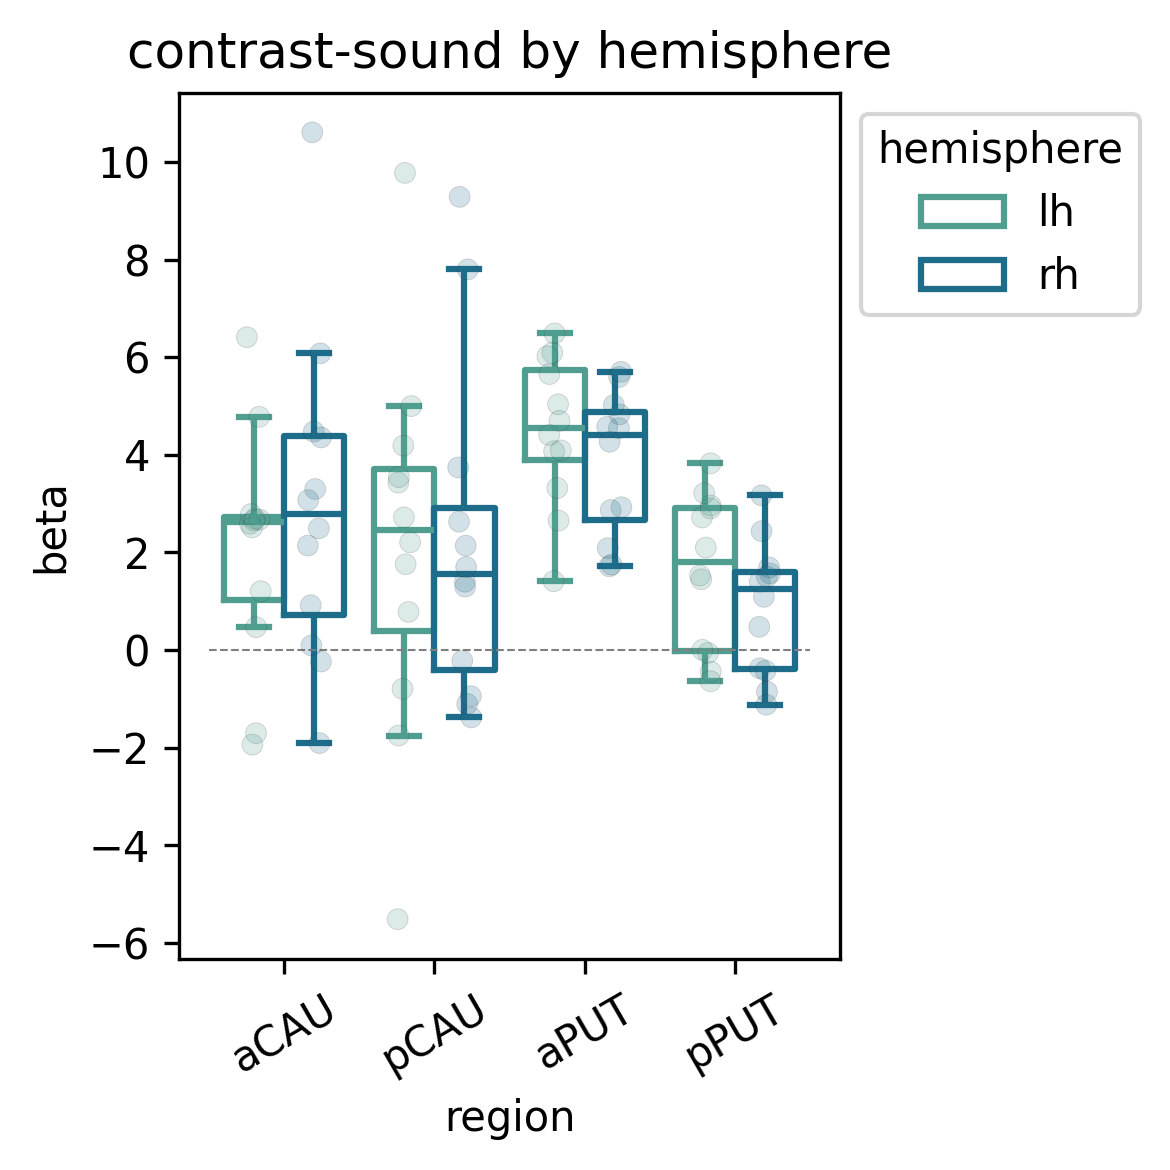

In [37]:
fig, ax = plt.subplots(1, 1, figsize=(4,4), dpi=300)

roi_df_collapsed = roi_df_long.groupby(["participant_id", "region", 'hemisphere'], 
                                       as_index=False).agg({"beta": "mean"})

sns.boxplot(data=roi_df_collapsed, 
              x='region', y='beta', 
              hue='hemisphere', #hue_order=['early', 'middle', 'final'],
              order=plot_order,
              palette='crest',
              fliersize = 0,            
              linewidth=1.5,
              fill=False,
              #legend=None,
              ax=ax);
sns.stripplot(data=roi_df_collapsed, 
              x='region', y='beta', 
              hue='hemisphere', #hue_order=['early', 'middle', 'final'],
              order=plot_order,
              palette='crest',
              dodge=True,
              linewidth=0.2,
              alpha=.2,
              legend=None,
              ax=ax);


xmin, xmax = ax.get_xlim()
ax.hlines(y=0, xmin=xmin, xmax=xmax, color='0.5', linestyle='--', linewidth=0.5)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_title(f'contrast-{contrast_label} by hemisphere');
#ax.set_ylim([-5, 5])

fig.tight_layout()


### Brain-behavior correlations

In [38]:
# map runs to learning stages matching your thirds
stage_map = {'run-01': 'early', 'run-02': 'early',
             'run-03': 'middle', 'run-04': 'middle',
             'run-05': 'final', 'run-06': 'final'}

acc_df['learning_stage'] = acc_df['run'].map(stage_map)
acc_stage_df = acc_df.groupby(['participant_id', 'learning_stage'])['accuracy'].mean().reset_index()

#### Averaged across learning stages

In [39]:
# merge into roi_df_long — assumes participant_id and learning_stage columns exist in both
roi_df_bilateral = (roi_df_long.groupby(['participant_id', 'region'], as_index=False)['beta'].mean())
roi_behav_df = roi_df_bilateral.merge(acc_stage_df, on=['participant_id'])

# verify
roi_behav_df.groupby(['region']).size().unique()  # should be array([12])


array([36])

In [40]:
roi_behav_df.columns

Index(['participant_id', 'region', 'beta', 'learning_stage', 'accuracy'], dtype='object')

In [41]:
roi_behav_df.participant_id.unique()

array(['sub-FLT02', 'sub-FLT04', 'sub-FLT06', 'sub-FLT09', 'sub-FLT11',
       'sub-FLT12', 'sub-FLT13', 'sub-FLT14', 'sub-FLT20', 'sub-FLT25',
       'sub-FLT28', 'sub-FLT30'], dtype=object)

In [42]:
roi_behav_df.groupby(['region','learning_stage']).size().unique()


array([12])

In [43]:
results = []
for roi in roi_behav_df['region'].unique():
    sub_df = roi_behav_df[roi_behav_df['region'] == roi]
    r = pg.corr(sub_df['accuracy'], sub_df['beta'], method='pearson')
    results.append({
        'roi': roi,
        'r': r['r'].values[0],
        'p': r['p-val'].values[0],
        'n': r['n'].values[0],
        'stat_str': stat_str('r', r['r'].values[0], r['p-val'].values[0])
    })

behav_corr_df = pd.DataFrame(results)

In [44]:
behav_corr_df

,roi,r,p,n,stat_str
0,aCAU,-0.1528,0.3738,36,"r = -.15, p = .374"
1,aPUT,-0.1099,0.5236,36,"r = -.11, p = .524"
2,pCAU,-0.2167,0.2042,36,"r = -.22, p = .204"
3,pPUT,-0.0913,0.5965,36,"r = -.09, p = .597"


#### Per learning stage

In [45]:
# merge into roi_df_long — assumes participant_id and learning_stage columns exist in both
roi_df_bilateral = (roi_df_long.groupby(['participant_id', 'region', 'learning_stage'], as_index=False)['beta'].mean())
roi_behav_df = roi_df_bilateral.merge(acc_stage_df, on=['participant_id', 'learning_stage'])

# verify
roi_behav_df.groupby(['region', 'learning_stage']).size().unique()  # should be array([12])


array([12])

In [46]:
roi_behav_df.columns

Index(['participant_id', 'region', 'learning_stage', 'beta', 'accuracy'], dtype='object')

In [47]:
roi_behav_df.participant_id.unique()

array(['sub-FLT02', 'sub-FLT04', 'sub-FLT06', 'sub-FLT09', 'sub-FLT11',
       'sub-FLT12', 'sub-FLT13', 'sub-FLT14', 'sub-FLT20', 'sub-FLT25',
       'sub-FLT28', 'sub-FLT30'], dtype=object)

In [48]:
roi_behav_df.groupby(['region','learning_stage']).size().unique()


array([12])

In [49]:
results = []
for stage in ['early', 'middle', 'final']:
    stage_df = roi_behav_df[roi_behav_df['learning_stage'] == stage]
    for roi in stage_df['region'].unique():
        sub_df = stage_df[stage_df['region'] == roi]
        r = pg.corr(sub_df['accuracy'], sub_df['beta'], method='pearson')
        results.append({
            'roi': roi,
            'learning_stage': stage,
            'r': r['r'].values[0],
            'p': r['p-val'].values[0],
            'n': r['n'].values[0],
            'stat_str': stat_str('r', r['r'].values[0], r['p-val'].values[0])
        })

behav_corr_df = pd.DataFrame(results)

In [50]:
behav_corr_df

,roi,learning_stage,r,p,n,stat_str
0,aCAU,early,0.1012,0.7544,12,"r = .10, p = .754"
1,aPUT,early,0.2870,0.3658,12,"r = .29, p = .366"
2,pCAU,early,-0.0535,0.8688,12,"r = -.05, p = .869"
3,pPUT,early,0.1610,0.6172,12,"r = .16, p = .617"
4,aCAU,middle,-0.1239,0.7012,12,"r = -.12, p = .701"
5,aPUT,middle,-0.3918,0.2078,12,"r = -.39, p = .208"
6,pCAU,middle,-0.0712,0.8259,12,"r = -.07, p = .826"
7,pPUT,middle,-0.2556,0.4227,12,"r = -.26, p = .423"
8,aCAU,final,-0.2318,0.4684,12,"r = -.23, p = .468"
9,aPUT,final,-0.1368,0.6715,12,"r = -.14, p = .672"


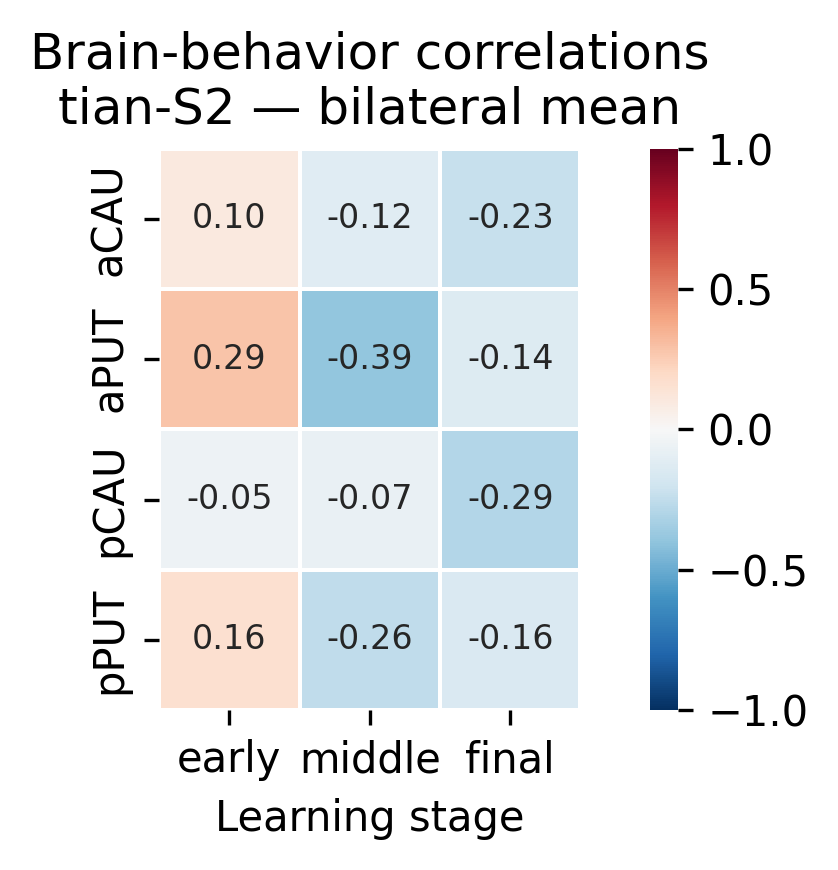

In [51]:
# pivot to ROI × stage matrix
r_matrix = behav_corr_df.pivot(index='roi', columns='learning_stage', values='r')[['early', 'middle', 'final']]
p_matrix = behav_corr_df.pivot(index='roi', columns='learning_stage', values='p')[['early', 'middle', 'final']]

fig, ax = plt.subplots(figsize=(5, len(r_matrix) * 0.5 + 1), dpi=300)
sns.heatmap(r_matrix, ax=ax, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, annot=True, fmt='.2f', annot_kws={'size': 8},
            square=True)

# mark significant cells with an asterisk
for i, roi in enumerate(r_matrix.index):
    for j, stage in enumerate(['early', 'middle', 'final']):
        p = p_matrix.loc[roi, stage]
        if p < 0.05:
            ax.text(j + 0.5, i + 0.85, '*', ha='center', va='center',
                    fontsize=12, color='black')

ax.set_title(f'Brain-behavior correlations\n{network_name} — bilateral mean')
ax.set_ylabel('')
ax.set_xlabel('Learning stage')
plt.tight_layout()

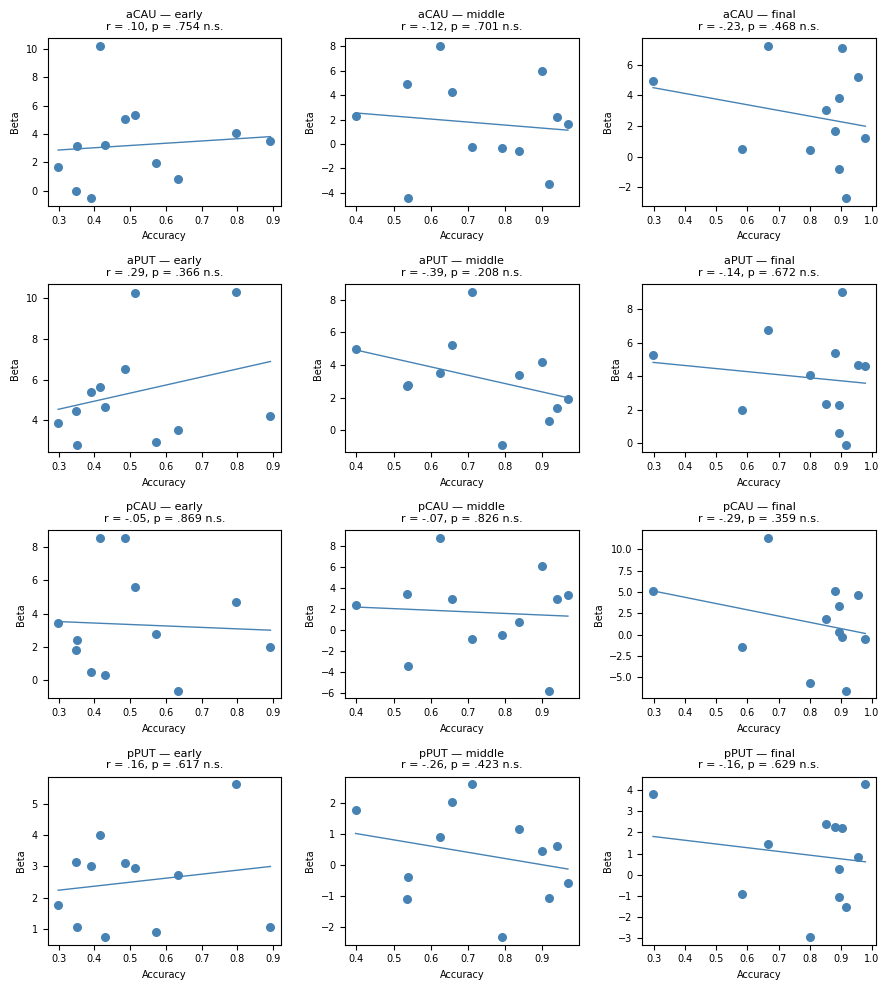

In [52]:
rois = behav_corr_df['roi'].unique()
stages = ['early', 'middle', 'final']

fig, axes = plt.subplots(len(rois), 3, figsize=(9, len(rois) * 2.5), dpi=100, sharex=False, sharey=False)

for ri, roi in enumerate(rois):
    for si, stage in enumerate(stages):
        ax = axes[ri, si]
        sub_df = roi_behav_df[(roi_behav_df['region'] == roi) & 
                              (roi_behav_df['learning_stage'] == stage)]
        
        ax.scatter(sub_df['accuracy'], sub_df['beta'], s=30, color='steelblue', zorder=3)
        
        # regression line
        m, b = np.polyfit(sub_df['accuracy'], sub_df['beta'], 1)
        x_range = np.linspace(sub_df['accuracy'].min(), sub_df['accuracy'].max(), 100)
        ax.plot(x_range, m * x_range + b, color='steelblue', linewidth=1)
        
        # stat annotation
        row = behav_corr_df[(behav_corr_df['roi'] == roi) & 
                            (behav_corr_df['learning_stage'] == stage)].iloc[0]
        p_str = '*' if row['p'] < 0.05 else 'n.s.'
        ax.set_title(f"{roi} — {stage}\n{row['stat_str']} {p_str}", fontsize=8)
        ax.set_xlabel('Accuracy', fontsize=7)
        ax.set_ylabel('Beta', fontsize=7)
        ax.tick_params(labelsize=7)

plt.tight_layout()


aCAU early: r = .10, p = .754 n.s.
aCAU middle: r = -.12, p = .701 n.s.
aCAU final: r = -.23, p = .468 n.s.
aPUT early: r = .29, p = .366 n.s.
aPUT middle: r = -.39, p = .208 n.s.
aPUT final: r = -.14, p = .672 n.s.
pCAU early: r = -.05, p = .869 n.s.
pCAU middle: r = -.07, p = .826 n.s.
pCAU final: r = -.29, p = .359 n.s.
pPUT early: r = .16, p = .617 n.s.
pPUT middle: r = -.26, p = .423 n.s.
pPUT final: r = -.16, p = .629 n.s.


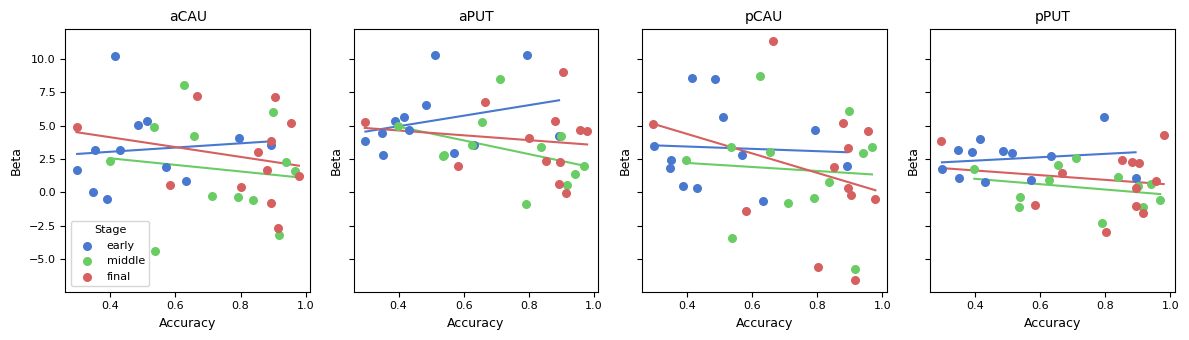

In [53]:
stage_colors = {'early': '#4878CF', 'middle': '#6ACC65', 'final': '#D65F5F'}
stages = ['early', 'middle', 'final']
rois = behav_corr_df['roi'].unique()

fig, axes = plt.subplots(1, len(rois), figsize=(3 * len(rois), 3.5), dpi=100, sharey=True)
if len(rois) == 1:
    axes = [axes]

for ri, roi in enumerate(rois):
    ax = axes[ri]
    for stage in stages:
        color = stage_colors[stage]
        sub_df = roi_behav_df[(roi_behav_df['region'] == roi) &
                              (roi_behav_df['learning_stage'] == stage)]

        ax.scatter(sub_df['accuracy'], sub_df['beta'], s=30,
                   color=color, label=stage, zorder=3)

        m, b = np.polyfit(sub_df['accuracy'], sub_df['beta'], 1)
        x_range = np.linspace(sub_df['accuracy'].min(), sub_df['accuracy'].max(), 100)
        ax.plot(x_range, m * x_range + b, color=color, linewidth=1.5)

        # stat annotation per stage
        row = behav_corr_df[(behav_corr_df['roi'] == roi) &
                            (behav_corr_df['learning_stage'] == stage)].iloc[0]
        p_str = '*' if row['p'] < 0.05 else 'n.s.'
        print(f"{roi} {stage}: {row['stat_str']} {p_str}")

    ax.set_title(roi, fontsize=10)
    ax.set_xlabel('Accuracy', fontsize=9)
    ax.set_ylabel('Beta', fontsize=9)
    ax.tick_params(labelsize=8)

axes[0].legend(title='Stage', fontsize=8, title_fontsize=8)
plt.tight_layout()


### omnibus ANOVA stats

In [54]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import AnovaRM
import pingouin as pg
import sys; sys.path.insert(0, '..')
from stats_fmt import export_anova, export_posthoc, export_ttests

stats_out_dir = os.path.join(deriv_dir, 'stats_tables')
os.makedirs(stats_out_dir, exist_ok=True)

In [55]:
non_mandarin_df.head()

,participant_id,participant_group,region,beta,region_hemi,hemisphere,learning_stage,Axis
0,sub-FLT02,non-Mandarin,aCAU,0.3118,aCAU-lh,lh,early,Rostral
1,sub-FLT04,non-Mandarin,aCAU,6.6399,aCAU-lh,lh,early,Rostral
2,sub-FLT06,non-Mandarin,aCAU,2.1960,aCAU-lh,lh,early,Rostral
3,sub-FLT09,non-Mandarin,aCAU,6.1937,aCAU-lh,lh,early,Rostral
4,sub-FLT11,non-Mandarin,aCAU,2.4432,aCAU-lh,lh,early,Rostral


In [56]:
non_mandarin_df.participant_id.unique()

array(['sub-FLT02', 'sub-FLT04', 'sub-FLT06', 'sub-FLT09', 'sub-FLT11',
       'sub-FLT12', 'sub-FLT13', 'sub-FLT14', 'sub-FLT20', 'sub-FLT25',
       'sub-FLT28', 'sub-FLT30'], dtype=object)

#### Mixed-Effects ANOVA with Hemisphere, Axis, and Learning Stage

In [57]:
# Mixed-Effects ANOVA with Hemisphere, Axis, and Interaction
aov = AnovaRM(non_mandarin_df, 
              aggregate_func='mean',
              depvar='beta', 
              subject='participant_id', 
              within=['hemisphere', 'learning_stage','Axis', ]).fit()

# Display results
print('network:', network_name)
print('contrast:', contrast_label)
aov.summary()

network: tian-S2
contrast: sound


/bgfs/bchandrasekaran/krs228/software/miniconda3/envs/py3/lib/python3.9/site-packages/statsmodels/stats/anova.py:508: FutureWarning: The provided callable <function mean at 0x7f858c111700> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  self.data = (self.data
/bgfs/bchandrasekaran/krs228/software/miniconda3/envs/py3/lib/python3.9/site-packages/statsmodels/iolib/summary2.py:579: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  dat = dat.applymap(lambda x: _formatter(x, float_format))


,F Value,Num DF,Den DF,Pr > F
hemisphere,0.1896,1.0000,11.0000,0.6716
learning_stage,3.8240,2.0000,22.0000,0.0376
Axis,31.1635,1.0000,11.0000,0.0002
hemisphere:learning_stage,0.4142,2.0000,22.0000,0.6659
hemisphere:Axis,1.4405,1.0000,11.0000,0.2553
learning_stage:Axis,0.7021,2.0000,22.0000,0.5063
hemisphere:learning_stage:Axis,2.4138,2.0000,22.0000,0.1128


In [58]:
export_anova(aov, f'{contrast_label}_{network_name}_hemisphere_learning-stage_axis', stats_out_dir)

,source,F,df_num,df_den,p,stat_str
0,hemisphere,0.1896,1.0000,11.0000,0.6716,"F(1, 11) = 0.19, p = .672"
1,learning_stage,3.8240,2.0000,22.0000,0.0376,"F(2, 22) = 3.82, p = .038"
2,Axis,31.1635,1.0000,11.0000,0.0002,"F(1, 11) = 31.16, p < .001"
3,hemisphere:learning_stage,0.4142,2.0000,22.0000,0.6659,"F(2, 22) = 0.41, p = .666"
4,hemisphere:Axis,1.4405,1.0000,11.0000,0.2553,"F(1, 11) = 1.44, p = .255"
5,learning_stage:Axis,0.7021,2.0000,22.0000,0.5063,"F(2, 22) = 0.70, p = .506"
6,hemisphere:learning_stage:Axis,2.4138,2.0000,22.0000,0.1128,"F(2, 22) = 2.41, p = .113"


In [59]:
# pairwise by Axis

# Pairwise comparisons for region with FDR correction
pairwise_by_region = pg.pairwise_tests(data=non_mandarin_df,
                             dv='beta', 
                             within=['hemisphere','Axis', ],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise_by_region.columns)

# Display key columns (without 'effsize' and 'CIs' if missing)
print("\nPost-hoc Pairwise Comparisons:")
#print(pairwise_by_region)
#pairwise_by_region[['Contrast', 'learning_stage', 'A', 'B', 'T', 'dof', 'p-unc', 'p-corr', 'BF10']]  # Keep only available columns

pd.set_option('display.max_rows', None)

pairwise_interaction = pairwise_by_region[pairwise_by_region.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05]
pairwise_interaction[['Contrast', 'hemisphere','A', 'B', 'T', 'dof', 'p-unc', 'p-corr', 'BF10']]

Available columns: Index(['Contrast', 'hemisphere', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof',
       'alternative', 'p-unc', 'p-corr', 'p-adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,hemisphere,A,B,T,dof,p-unc,p-corr,BF10
0,hemisphere * Axis,lh,Caudal,Rostral,-4.0526,11.0000,0.0019,0.0019,23.257
1,hemisphere * Axis,rh,Caudal,Rostral,-5.5518,11.0000,0.0002,0.0003,180.172


In [60]:
export_posthoc(pairwise_by_region, f'{contrast_label}_{network_name}_hemisphere_axis', stats_out_dir)

,Contrast,hemisphere,A,B,t,df,p,p_fdr,stat_str,p_fdr_str
0,hemisphere,-,lh,rh,0.4355,11.0000,0.6716,NaN,"t(11) = 0.44, p = .672",p = nan
1,Axis,-,Caudal,Rostral,-5.5824,11.0000,0.0002,NaN,"t(11) = -5.58, p < .001",p = nan
2,hemisphere * Axis,lh,Caudal,Rostral,-4.0526,11.0000,0.0019,0.0019,"t(11) = -4.05, p = .002",p = .002
3,hemisphere * Axis,rh,Caudal,Rostral,-5.5518,11.0000,0.0002,0.0003,"t(11) = -5.55, p < .001",p < .001


In [61]:
# pairwise by Axis

# Pairwise comparisons for region with FDR correction
pairwise_by_region = pg.pairwise_tests(data=non_mandarin_df,
                             dv='beta', 
                             within=['Axis', 'hemisphere',],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise_by_region.columns)

# Display key columns (without 'effsize' and 'CIs' if missing)
print("\nPost-hoc Pairwise Comparisons:")
#print(pairwise_by_region)
#pairwise_by_region[['Contrast', 'learning_stage', 'A', 'B', 'T', 'dof', 'p-unc', 'p-corr', 'BF10']]  # Keep only available columns

pd.set_option('display.max_rows', None)

pairwise_interaction = pairwise_by_region[pairwise_by_region.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05]
pairwise_interaction[['Contrast', 'Axis', 'A', 'B', 'T', 'dof', 'p-unc', 'p-corr', 'BF10']]

Available columns: Index(['Contrast', 'Axis', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof',
       'alternative', 'p-unc', 'p-corr', 'p-adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Axis,A,B,T,dof,p-unc,p-corr,BF10
0,Axis * hemisphere,Caudal,lh,rh,0.9786,11.0000,0.3488,0.6976,0.429
1,Axis * hemisphere,Rostral,lh,rh,-0.2902,11.0000,0.7770,0.7770,0.298


In [62]:
export_posthoc(pairwise_by_region, f'{contrast_label}_{network_name}_axis_hemisphere', stats_out_dir)

,Contrast,A,B,t,df,p,p_fdr,stat_str,p_fdr_str
0,Axis,Caudal,Rostral,-5.5824,11.0000,0.0002,NaN,"t(11) = -5.58, p < .001",p = nan
1,hemisphere,lh,rh,0.4355,11.0000,0.6716,NaN,"t(11) = 0.44, p = .672",p = nan
2,Axis * hemisphere,lh,rh,0.9786,11.0000,0.3488,0.6976,"t(11) = 0.98, p = .349",p = .698
3,Axis * hemisphere,lh,rh,-0.2902,11.0000,0.7770,0.7770,"t(11) = -0.29, p = .777",p = .777


In [63]:
# pairwise by region, no learning stage

# Pairwise comparisons for region with FDR correction
pairwise_by_region_only = pg.pairwise_tests(data=non_mandarin_df,
                             dv='beta', 
                             within=['Axis', ],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise_by_region_only.columns)

# Display key columns (without 'effsize' and 'CIs' if missing)
print("\nPost-hoc Pairwise Comparisons:")
#print(pairwise_by_region_only)
#pairwise_by_region_only = pairwise_by_region_only[pairwise_by_region_only['p-unc'] < 0.05]
pairwise_by_region_only#[['Contrast', 'Contrast', 'A', 'B', 'T', 'dof', 'p-unc', 'p-corr', 'BF10']]  # Keep only available columns


Available columns: Index(['Contrast', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof', 'alternative',
       'p-unc', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,BF10,hedges
0,Axis,Caudal,Rostral,True,True,-5.5824,11.0000,two-sided,0.0002,187.439,-0.8034


In [64]:
export_posthoc(pairwise_by_region_only, f'{contrast_label}_{network_name}_axis', stats_out_dir)

,Contrast,A,B,t,df,p,stat_str,p_fdr_str
0,Axis,Caudal,Rostral,-5.5824,11.0000,0.0002,"t(11) = -5.58, p < .001",NaN


#### Mixed-Effects ANOVA with Hemisphere, Region, and Learning Stage

In [65]:
# Mixed-Effects ANOVA with Hemisphere, Region, and Interaction
aov = AnovaRM(non_mandarin_df, 
              aggregate_func='mean',
              depvar='beta', 
              subject='participant_id', 
              within=['hemisphere', 'learning_stage','region', ]).fit()

# Display results
print('network:', network_name)
print('contrast:', contrast_label)
aov.summary()

network: tian-S2
contrast: sound


/bgfs/bchandrasekaran/krs228/software/miniconda3/envs/py3/lib/python3.9/site-packages/statsmodels/iolib/summary2.py:579: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  dat = dat.applymap(lambda x: _formatter(x, float_format))


,F Value,Num DF,Den DF,Pr > F
hemisphere,0.1896,1.0000,11.0000,0.6716
learning_stage,3.8240,2.0000,22.0000,0.0376
region,6.1126,3.0000,33.0000,0.0020
hemisphere:learning_stage,0.4142,2.0000,22.0000,0.6659
hemisphere:region,3.3662,3.0000,33.0000,0.0301
learning_stage:region,0.5315,6.0000,66.0000,0.7824
hemisphere:learning_stage:region,1.1389,6.0000,66.0000,0.3499


In [66]:
export_anova(aov, f'{contrast_label}_{network_name}_hemisphere_learning-stage_region', stats_out_dir)

,source,F,df_num,df_den,p,stat_str
0,hemisphere,0.1896,1.0000,11.0000,0.6716,"F(1, 11) = 0.19, p = .672"
1,learning_stage,3.8240,2.0000,22.0000,0.0376,"F(2, 22) = 3.82, p = .038"
2,region,6.1126,3.0000,33.0000,0.0020,"F(3, 33) = 6.11, p = .002"
3,hemisphere:learning_stage,0.4142,2.0000,22.0000,0.6659,"F(2, 22) = 0.41, p = .666"
4,hemisphere:region,3.3662,3.0000,33.0000,0.0301,"F(3, 33) = 3.37, p = .030"
5,learning_stage:region,0.5315,6.0000,66.0000,0.7824,"F(6, 66) = 0.53, p = .782"
6,hemisphere:learning_stage:region,1.1389,6.0000,66.0000,0.3499,"F(6, 66) = 1.14, p = .350"


In [67]:
# Pairwise comparisons for region with FDR correction
pairwise_by_learning_stage = pg.pairwise_tests(data=non_mandarin_df,
                             dv='beta', 
                             within=['hemisphere','region', ],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise_by_learning_stage.columns)

# Display key columns (without 'effsize' and 'CIs' if missing)
print("\nPost-hoc Pairwise Comparisons:")
#print(pairwise_by_learning_stage)
#pairwise_by_learning_stage[['Contrast', 'learning_stage', 'A', 'B', 'T', 'dof', 'p-unc', 'p-corr', 'BF10']]  # Keep only available columns

pd.set_option('display.max_rows', None)

pairwise_interaction = pairwise_by_learning_stage[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
pairwise_interaction = pairwise_interaction[pairwise_interaction['p-corr'] < 0.05].reset_index()
pairwise_interaction[['Contrast', 'hemisphere', 'A', 'B', 'T', 'dof', 'p-unc', 'p-corr', 'BF10']]

Available columns: Index(['Contrast', 'hemisphere', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof',
       'alternative', 'p-unc', 'p-corr', 'p-adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,hemisphere,A,B,T,dof,p-unc,p-corr,BF10
0,hemisphere * region,lh,aCAU,aPUT,-3.5298,11.0000,0.0047,0.0189,10.948
1,hemisphere * region,lh,aPUT,pPUT,9.2604,11.0000,0.0000,0.0000,1.102e+04
2,hemisphere * region,rh,aPUT,pPUT,8.2946,11.0000,0.0000,0.0000,4264.287


In [68]:
export_posthoc(pairwise_by_learning_stage, f'{contrast_label}_{network_name}_hemisphere_region', stats_out_dir)

,Contrast,hemisphere,A,B,t,df,p,p_fdr,stat_str,p_fdr_str
0,hemisphere,-,lh,rh,0.4355,11.0000,0.6716,NaN,"t(11) = 0.44, p = .672",p = nan
1,region,-,aCAU,aPUT,-2.3240,11.0000,0.0403,0.0806,"t(11) = -2.32, p = .040",p = .081
2,region,-,aCAU,pCAU,0.8058,11.0000,0.4374,0.4374,"t(11) = 0.81, p = .437",p = .437
3,region,-,aCAU,pPUT,1.6313,11.0000,0.1311,0.1967,"t(11) = 1.63, p = .131",p = .197
4,region,-,aPUT,pCAU,2.3663,11.0000,0.0374,0.0806,"t(11) = 2.37, p = .037",p = .081
5,region,-,aPUT,pPUT,9.7513,11.0000,0.0000,0.0000,"t(11) = 9.75, p < .001",p < .001
6,region,-,pCAU,pPUT,1.0187,11.0000,0.3302,0.3962,"t(11) = 1.02, p = .330",p = .396
7,hemisphere * region,lh,aCAU,aPUT,-3.5298,11.0000,0.0047,0.0189,"t(11) = -3.53, p = .005",p = .019
8,hemisphere * region,lh,aCAU,pCAU,-0.0310,11.0000,0.9758,0.9758,"t(11) = -0.03, p = .976",p = .976
9,hemisphere * region,lh,aCAU,pPUT,0.6351,11.0000,0.5383,0.6460,"t(11) = 0.64, p = .538",p = .646


In [69]:
# Pairwise comparisons for region with FDR correction
pairwise_by_learning_stage = pg.pairwise_tests(data=non_mandarin_df,
                             dv='beta', 
                             within=['region', 'hemisphere',],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise_by_learning_stage.columns)

# Display key columns (without 'effsize' and 'CIs' if missing)
print("\nPost-hoc Pairwise Comparisons:")
#print(pairwise_by_learning_stage)
#pairwise_by_learning_stage[['Contrast', 'learning_stage', 'A', 'B', 'T', 'dof', 'p-unc', 'p-corr', 'BF10']]  # Keep only available columns

pd.set_option('display.max_rows', None)

pairwise_interaction = pairwise_by_learning_stage[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-corr'] < 0.05].reset_index()
pairwise_interaction[['Contrast', 'region', 'A', 'B', 'T', 'dof', 'p-unc', 'p-corr', 'BF10']]

Available columns: Index(['Contrast', 'region', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof',
       'alternative', 'p-unc', 'p-corr', 'p-adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,region,A,B,T,dof,p-unc,p-corr,BF10
0,region * hemisphere,aCAU,lh,rh,-1.5697,11.0000,0.1448,0.1931,0.759
1,region * hemisphere,aPUT,lh,rh,2.6380,11.0000,0.0231,0.0461,3.027
2,region * hemisphere,pCAU,lh,rh,-0.1299,11.0000,0.8990,0.8990,0.29
3,region * hemisphere,pPUT,lh,rh,4.3946,11.0000,0.0011,0.0043,37.754


In [70]:
export_posthoc(pairwise_by_learning_stage, f'{contrast_label}_{network_name}_region_hemisphere', stats_out_dir)

,Contrast,region,A,B,t,df,p,p_fdr,stat_str,p_fdr_str
0,region,-,aCAU,aPUT,-2.3240,11.0000,0.0403,0.0806,"t(11) = -2.32, p = .040",p = .081
1,region,-,aCAU,pCAU,0.8058,11.0000,0.4374,0.4374,"t(11) = 0.81, p = .437",p = .437
2,region,-,aCAU,pPUT,1.6313,11.0000,0.1311,0.1967,"t(11) = 1.63, p = .131",p = .197
3,region,-,aPUT,pCAU,2.3663,11.0000,0.0374,0.0806,"t(11) = 2.37, p = .037",p = .081
4,region,-,aPUT,pPUT,9.7513,11.0000,0.0000,0.0000,"t(11) = 9.75, p < .001",p < .001
5,region,-,pCAU,pPUT,1.0187,11.0000,0.3302,0.3962,"t(11) = 1.02, p = .330",p = .396
6,hemisphere,-,lh,rh,0.4355,11.0000,0.6716,NaN,"t(11) = 0.44, p = .672",p = nan
7,region * hemisphere,aCAU,lh,rh,-1.5697,11.0000,0.1448,0.1931,"t(11) = -1.57, p = .145",p = .193
8,region * hemisphere,aPUT,lh,rh,2.6380,11.0000,0.0231,0.0461,"t(11) = 2.64, p = .023",p = .046
9,region * hemisphere,pCAU,lh,rh,-0.1299,11.0000,0.8990,0.8990,"t(11) = -0.13, p = .899",p = .899


In [71]:
# pairwise by region, no learning stage

# Pairwise comparisons for region with FDR correction
pairwise_by_region_only = pg.pairwise_tests(data=non_mandarin_df,
                             dv='beta', 
                             within=['region', ],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise_by_region_only.columns)

# Display key columns (without 'effsize' and 'CIs' if missing)
print("\nPost-hoc Pairwise Comparisons:")
#print(pairwise_by_region_only)
pairwise_by_region_only = pairwise_by_region_only[pairwise_by_region_only['p-unc'] < 0.05]
pairwise_by_region_only[['Contrast', 'Contrast', 'A', 'B', 'T', 'dof', 'p-unc', 'p-corr', 'BF10']]  # Keep only available columns


Available columns: Index(['Contrast', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof', 'alternative',
       'p-unc', 'p-corr', 'p-adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Contrast,A,B,T,dof,p-unc,p-corr,BF10
0,region,region,aCAU,aPUT,-2.3240,11.0000,0.0403,0.0806,1.958
3,region,region,aPUT,pCAU,2.3663,11.0000,0.0374,0.0806,2.074
4,region,region,aPUT,pPUT,9.7513,11.0000,0.0000,0.0000,1.736e+04


In [72]:
export_posthoc(pairwise_by_region_only, f'{contrast_label}_{network_name}_region', stats_out_dir)

,Contrast,A,B,t,df,p,p_fdr,stat_str,p_fdr_str
0,region,aCAU,aPUT,-2.3240,11.0000,0.0403,0.0806,"t(11) = -2.32, p = .040",p = .081
3,region,aPUT,pCAU,2.3663,11.0000,0.0374,0.0806,"t(11) = 2.37, p = .037",p = .081
4,region,aPUT,pPUT,9.7513,11.0000,0.0000,0.0000,"t(11) = 9.75, p < .001",p < .001


In [73]:
# pairwise by region, no learning stage

# Pairwise comparisons for region with FDR correction
pairwise_by_region_only = pg.pairwise_tests(data=non_mandarin_df,
                             dv='beta', 
                             within=['learning_stage', ],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise_by_region_only.columns)

# Display key columns (without 'effsize' and 'CIs' if missing)
print("\nPost-hoc Pairwise Comparisons:")
#print(pairwise_by_region_only)
#pairwise_by_region_only = pairwise_by_region_only[pairwise_by_region_only['p-unc'] < 0.05]
pairwise_by_region_only[['Contrast', 'Contrast', 'A', 'B', 'T', 'dof', 'p-unc', 'p-corr', 'BF10']]  # Keep only available columns


Available columns: Index(['Contrast', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof', 'alternative',
       'p-unc', 'p-corr', 'p-adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Contrast,A,B,T,dof,p-unc,p-corr,BF10
0,learning_stage,learning_stage,early,final,1.6041,11.0000,0.1370,0.2055,0.789
1,learning_stage,learning_stage,early,middle,2.5335,11.0000,0.0278,0.0834,2.614
2,learning_stage,learning_stage,final,middle,1.1246,11.0000,0.2847,0.2847,0.485


In [74]:
export_posthoc(pairwise_by_region_only, f'{contrast_label}_{network_name}_learning_stage', stats_out_dir)

,Contrast,A,B,t,df,p,p_fdr,stat_str,p_fdr_str
0,learning_stage,early,final,1.6041,11.0000,0.1370,0.2055,"t(11) = 1.60, p = .137",p = .205
1,learning_stage,early,middle,2.5335,11.0000,0.0278,0.0834,"t(11) = 2.53, p = .028",p = .083
2,learning_stage,final,middle,1.1246,11.0000,0.2847,0.2847,"t(11) = 1.12, p = .285",p = .285


#### Collapse (average) over non-significant factors

In [75]:
roi_df_collapsed = roi_df_long.groupby(["participant_id", "region", 'learning_stage'], 
                                       as_index=False).agg({"beta": "mean"})


In [76]:
# Collect results
results = []

for region, data in roi_df_collapsed.groupby("region"):
    t_stat, p_val = ttest_1samp(data["beta"], 0)
    results.append({
        "region": region,
        "t_stat": t_stat,
        "p_val": p_val
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Apply FDR correction
results_df["p_val_fdr"] = multipletests(results_df["p_val"], method="fdr_bh")[1]

# Print or export the table
results_df

# Optional: export
# results_df.to_csv("roi_stats.csv", index=False)
# results_df.to_excel("roi_stats.xlsx", index=False)


,region,t_stat,p_val,p_val_fdr
0,aCAU,4.6900,0.0000,0.0001
1,aPUT,9.5127,0.0000,0.0000
2,pCAU,3.2152,0.0028,0.0028
3,pPUT,3.8818,0.0004,0.0006


In [77]:
_export = results_df.rename(columns={'t_stat': 't', 'p_val': 'p'}).copy()
_export['df'] = len(sub_list_nman) - 1
export_ttests(_export.to_dict('records'), f'{contrast_label}_{network_name}_baseline_by_region', stats_out_dir)

,region,t,p,p_val_fdr,df,p_fdr,stat_str,p_fdr_str
0,aCAU,4.6900,0.0000,0.0001,11,0.0001,"t(11) = 4.69, p < .001",p < .001
1,aPUT,9.5127,0.0000,0.0000,11,0.0000,"t(11) = 9.51, p < .001",p < .001
2,pCAU,3.2152,0.0028,0.0028,11,0.0028,"t(11) = 3.22, p = .003",p = .003
3,pPUT,3.8818,0.0004,0.0006,11,0.0006,"t(11) = 3.88, p < .001",p < .001


### Make 3D plots

In [61]:
roi_df_collapsed = roi_df_long.groupby(["participant_id", "region_hemi"], 
                                       as_index=False).agg({"beta": "mean"})

# Collect p-values
p_values = []
t_stats = []
comparisons = []

for region, data in roi_df_collapsed.groupby(["region_hemi"]):
    t_stat, p_val = ttest_1samp(data["beta"], 0)
    p_values.append(p_val)
    comparisons.append((region[0], t_stat))
    t_stats.append(t_stat)

# Apply FDR correction
_, p_corrected, _, _ = multipletests(p_values, method='fdr_bh')

# Print corrected results
for (region, t_stat), p_val_corr in zip(comparisons, p_corrected):
    print(f"Region: {region}, t = {t_stat:.2f}; corrected p = {p_val_corr:.4f}")


Region: aCAU-lh, t = 3.06; corrected p = 0.0174
Region: aCAU-rh, t = 3.10; corrected p = 0.0174
Region: aPUT-lh, t = 10.29; corrected p = 0.0000
Region: aPUT-rh, t = 8.99; corrected p = 0.0000
Region: pCAU-lh, t = 1.92; corrected p = 0.0807
Region: pCAU-rh, t = 2.25; corrected p = 0.0521
Region: pPUT-lh, t = 3.60; corrected p = 0.0112
Region: pPUT-rh, t = 2.26; corrected p = 0.0521


In [ ]:
_records = [{'region_hemi': c[0], 't': c[1], 'df': len(sub_list_nman) - 1, 'p': p}
            for c, p in zip(comparisons, p_values)]
export_ttests(_records, f'{contrast_label}_{network_name}_baseline_by_region_hemi', stats_out_dir)

In [27]:
region_list = region_dict[network_name]

mask_dict = dict(zip(mask_path_list, 
                     range(1,len(mask_path_list)+1)))

stat_dict = dict(zip(range(1,len(t_stats)+1), 
                     t_stats))

from matplotlib import cm

# Load NIfTI files into a list
nifti_files = mask_path_list

# Define a colormap
colormap = cm.get_cmap('coolwarm')

# Define the list of values for color plotting
color_values = t_stats  # Adjust these values as needed

NameError: name 't_stats' is not defined

In [63]:
import plotly.graph_objs as go
from plotly.subplots import make_subplots
from matplotlib import cm
from skimage import measure
from scipy.ndimage import gaussian_filter
from IPython.display import clear_output

# Load NIfTI files into a list
nifti_files = mask_path_list

# Define a colormap
colormap = cm.get_cmap('Reds') # 'coolwarm'

# Define the list of values for color plotting
color_values = t_stats  # Adjust these values as needed

# Create a list to hold the data for each segmentation
segmentations = []

# Loop through each NIfTI file and extract segmentation data
for nifti_file in nifti_files:
    nifti_data = nib.load(nifti_file)
    segmentation = nifti_data.get_fdata()
    segmentations.append(segmentation)

# Combine all segmentations into a single binary mask
combined_segmentation = np.any(segmentations, axis=0)

# Upsample the voxel data to a higher resolution grid
upsampled_segmentation = np.repeat(np.repeat(np.repeat(combined_segmentation, 2, axis=0), 2, axis=1), 2, axis=2)

# Smooth the upsampled voxel data with a Gaussian filter
smoothed_segmentation = gaussian_filter(upsampled_segmentation, sigma=1)

# Extract the surface mesh of the smoothed segmented region with adjusted level
vertices, faces, _, _ = measure.marching_cubes(smoothed_segmentation, level=smoothed_segmentation.mean())

# Translate vertices closer to the origin
center = vertices.mean(axis=0)
vertices -= center

# Create a subplot for the 3D plot with a larger size
fig = make_subplots(rows=1, cols=1, specs=[[{'type': 'mesh3d'}]], print_grid=False)

# Loop through each segmentation and add its surface plot to the subplot
for i, segmentation in enumerate(segmentations):
    # Upsample the voxel data to a higher resolution grid
    upsampled_segmentation = np.repeat(np.repeat(np.repeat(segmentation, 2, axis=0), 2, axis=1), 2, axis=2)
    
    # Smooth the upsampled voxel data with a Gaussian filter
    smoothed_segmentation = gaussian_filter(upsampled_segmentation, sigma=1)
    
    # Extract the surface mesh of the smoothed segmented region with adjusted level
    vertices, faces, _, _ = measure.marching_cubes(smoothed_segmentation, level=smoothed_segmentation.mean())
    
    vertices -= center
    
    # Map the color value to the colormap
    colormap_value = (color_values[i] - min(color_values)) / (max(color_values) - min(color_values))
    color = colormap(colormap_value)
    
    # Add the surface plot to the subplot
    fig.add_trace(go.Mesh3d(
        x=vertices[:, 0],
        y=vertices[:, 1],
        z=vertices[:, 2],
        i=faces[:, 0],
        j=faces[:, 1],
        k=faces[:, 2],
        color=f'rgb({int(color[0]*255)}, {int(color[1]*255)}, {int(color[2]*255)})',
        opacity=1,
        name= region_list[i] # f'Segmentation {i+1}'
    ))

# Set starting camera angle
camera = dict(
    up=dict(x=0, y=0, z=1),
    center=dict(x=0, y=0, z=0),
    eye=dict(x=-1.25, y=1.25, z=1.25)
)

# Update layout for the 3D plot to set a larger size and transparent background
fig.update_layout(
    scene=dict(
        xaxis=dict(title=None, showbackground=False, linecolor='rgba(0,0,0,0)', 
                   showgrid=False, showticklabels=False),
        yaxis=dict(title=None, showbackground=False, linecolor='rgba(0,0,0,0)', 
                   showgrid=False, showticklabels=False),
        zaxis=dict(title=None, showbackground=False, linecolor='rgba(0,0,0,0)', 
                   showgrid=False, showticklabels=False),
        bgcolor='rgba(0,0,0,0)',  # Set background color to transparent
        camera=camera  # Set starting camera angle
    ),
    #title=f'All participants contrast-{contrast_label}',
    width=800,  # Set width of the plot
    height=600,  # Set height of the plot
)

# Show the interactive plot
fig.show()

# Save the interactive plot as an SVG file
#fig.write_image(f'out-figure_group-all_contrast-{contrast_label}_network-{network_name}_surface.svg')
clear_output() # very large – clear it after using

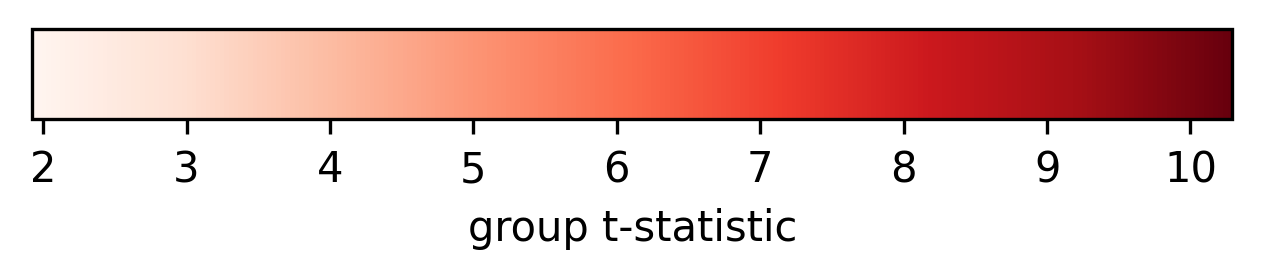

In [65]:
a = np.array([[min(color_values), max(color_values)]])
plt.figure(figsize=(5, 0.5), dpi=300)
img = plt.imshow(a, cmap=colormap)
plt.gca().set_visible(False)
cax = plt.axes([0.1, 0.2, 0.8, 0.6])
#cbar = plt.colorbar(orientation="horizontal", cax=cax, label='group t-statistic')
plt.colorbar(orientation="horizontal", cax=cax, label='group t-statistic')
#cbar.ax.get_yaxis().labelpad = 15
#plt.savefig(f"out-figure_group-all_contrast-{contrast_label}_network-{network_name}_colorbar.svg")

#### plot ROIs for methods

In [ ]:
import plotly.graph_objs as go
from plotly.subplots import make_subplots
from matplotlib import cm
from skimage import measure
from scipy.ndimage import gaussian_filter
from IPython.display import clear_output

# Load NIfTI files into a list
nifti_files = mask_path_list

# Define a colormap

import plotly.express as px
import random

# Define the list of values for color plotting
palette = px.colors.qualitative.Set3
random_colors = random.sample(palette, k=len(mask_path_list))

# Create a list to hold the data for each segmentation
segmentations = []

# Loop through each NIfTI file and extract segmentation data
for nifti_file in nifti_files:
    nifti_data = nib.load(nifti_file)
    segmentation = nifti_data.get_fdata()
    segmentations.append(segmentation)

# Combine all segmentations into a single binary mask
combined_segmentation = np.any(segmentations, axis=0)

# Upsample the voxel data to a higher resolution grid
upsampled_segmentation = np.repeat(np.repeat(np.repeat(combined_segmentation, 2, axis=0), 2, axis=1), 2, axis=2)

# Smooth the upsampled voxel data with a Gaussian filter
smoothed_segmentation = gaussian_filter(upsampled_segmentation, sigma=1)

# Extract the surface mesh of the smoothed segmented region with adjusted level
vertices, faces, _, _ = measure.marching_cubes(smoothed_segmentation, level=smoothed_segmentation.mean())

# Translate vertices closer to the origin
center = vertices.mean(axis=0)
vertices -= center

# Create a subplot for the 3D plot with a larger size
fig = make_subplots(rows=1, cols=1, specs=[[{'type': 'mesh3d'}]], print_grid=False)

# Loop through each segmentation and add its surface plot to the subplot
for i, segmentation in enumerate(segmentations):
    # Upsample the voxel data to a higher resolution grid
    upsampled_segmentation = np.repeat(np.repeat(np.repeat(segmentation, 2, axis=0), 2, axis=1), 2, axis=2)
    
    # Smooth the upsampled voxel data with a Gaussian filter
    smoothed_segmentation = gaussian_filter(upsampled_segmentation, sigma=1)
    
    # Extract the surface mesh of the smoothed segmented region with adjusted level
    vertices, faces, _, _ = measure.marching_cubes(smoothed_segmentation, level=smoothed_segmentation.mean())
    
    vertices -= center
    
    # Compute centroid for labeling
    centroid = vertices.mean(axis=0)

    # Add text label
    fig.add_trace(go.Scatter3d(
        x=[centroid[0]],
        y=[centroid[1]],
        z=[centroid[2]],
        mode='text',
        text=[region_list[i]],
        textfont=dict(
            size=14,
            color=random_colors[i]  # match ROI color
        ),
        showlegend=False
    ))


    # Add the surface plot to the subplot
    fig.add_trace(go.Mesh3d(
        x=vertices[:, 0],
        y=vertices[:, 1],
        z=vertices[:, 2],
        i=faces[:, 0],
        j=faces[:, 1],
        k=faces[:, 2],
        color=random_colors[i],
        opacity=1,
        name= region_list[i] # f'Segmentation {i+1}'
    ))

# Set starting camera angle
camera = dict(
    up=dict(x=0, y=0, z=1),
    center=dict(x=0, y=0, z=0),
    eye=dict(x=-1.25, y=1.25, z=1.25)
)

# Update layout for the 3D plot to set a larger size and transparent background
fig.update_layout(
    scene=dict(
        xaxis=dict(title=None, showbackground=False, linecolor='rgba(0,0,0,0)', 
                   showgrid=False, showticklabels=False),
        yaxis=dict(title=None, showbackground=False, linecolor='rgba(0,0,0,0)', 
                   showgrid=False, showticklabels=False),
        zaxis=dict(title=None, showbackground=False, linecolor='rgba(0,0,0,0)', 
                   showgrid=False, showticklabels=False),
        bgcolor='rgba(0,0,0,0)',  # Set background color to transparent
        camera=camera  # Set starting camera angle
    ),
    #title=f'All participants contrast-{contrast_label}',
    width=1200,  # Set width of the plot
    height=1200,  # Set height of the plot
)

# Show the interactive plot
fig.update_layout(showlegend=True)

fig.show()

# Save the interactive plot as an SVG file
#fig.write_image(f'out-figure_group-all_contrast-{contrast_label}_network-{network_name}_surface.svg')
clear_output() # very large – clear it after using

## `contrast-sound` for cortical network

In [78]:
# get the beta map for the contrast of interest for each subject
network_name = network_list[0]
contrast_label = contrast_list[0]
print('network_name:', network_name)
print('contrast_label:', contrast_label)

statmap_earlythird_dict = {}
for sub_id in sub_list_nman:
    statmap_earlythird_dict[sub_id] = sorted(glob(l1_dir+f'/{sub_id}_space-{space_label}/grouped_runs/earlythird/*{contrast_label}_map-beta.nii.gz'))[0]
    
statmap_middlethird_dict = {}
for sub_id in sub_list_nman:
    statmap_middlethird_dict[sub_id] = sorted(glob(l1_dir+f'/{sub_id}_space-{space_label}/grouped_runs/middlethird/*{contrast_label}_map-beta.nii.gz'))[0]
    
statmap_latethird_dict = {}
for sub_id in sub_list_nman:
    statmap_latethird_dict[sub_id] = sorted(glob(l1_dir+f'/{sub_id}_space-{space_label}/grouped_runs/latethird/*{contrast_label}_map-beta.nii.gz'))[0]

network_name: auditory
contrast_label: sound


In [ ]:
# mask the stat maps per learning stage by region - ONLY RUN ONCE
'''
print(f'masking {contrast_label} stat maps for the {network_name} network')

print(f'creating dictionary for early learning stage')
roi_earlythird_mean_dict, mask_path_list = mask_stat_maps(region_dict[network_name], 
                                               statmap_earlythird_dict, 
                                               masks_dir, 
                                               network_name,
                                               space_label)

print(f'creating dictionary for middle learning stage')
roi_middlethird_mean_dict, mask_path_list = mask_stat_maps(region_dict[network_name], 
                                               statmap_middlethird_dict, 
                                               masks_dir, 
                                               network_name,
                                               space_label)

print(f'creating dictionary for final learning stage')
roi_latethird_mean_dict, mask_path_list = mask_stat_maps(region_dict[network_name], 
                                               statmap_latethird_dict, 
                                               masks_dir, 
                                               network_name,
                                               space_label)

# add `learning_stage` column and combine into single dataframe
roi_earlythird_df_long = make_stats_df(roi_earlythird_mean_dict, participants_nman_df, network_name)
roi_earlythird_df_long['learning_stage'] = 'early'
roi_middlethird_df_long = make_stats_df(roi_middlethird_mean_dict, participants_nman_df, network_name)
roi_middlethird_df_long['learning_stage'] = 'middle'
roi_latethird_df_long = make_stats_df(roi_latethird_mean_dict, participants_nman_df, network_name)
roi_latethird_df_long['learning_stage'] = 'final'

# combine into a single long dataframe
roi_df_long = pd.concat([roi_earlythird_df_long, roi_middlethird_df_long, roi_latethird_df_long],)

# save the DataFrame for easier access
out_fname = f'univariate-results_network-{network_name}_contrast-{contrast_label}.tsv'
roi_df_long.to_csv(os.path.join(group_out_dir, out_fname), sep='\t', index=False)
'''

In [79]:
# load the DataFrame if already exists
out_fname = f'univariate-results_network-{network_name}_contrast-{contrast_label}.tsv'
roi_df_long = pd.read_csv(os.path.join(group_out_dir, out_fname), sep='\t')


# create a bilateral-averaged dataframe (for across-contrast analysis)
sound_cortex_df = bilateral_mean(roi_df_long)


In [81]:
roi_df_long.participant_id.unique()

array(['sub-FLT02', 'sub-FLT04', 'sub-FLT06', 'sub-FLT09', 'sub-FLT11',
       'sub-FLT12', 'sub-FLT13', 'sub-FLT14', 'sub-FLT20', 'sub-FLT25',
       'sub-FLT28', 'sub-FLT30'], dtype=object)

In [82]:
roi_df_long.region.unique()

array(['HG', 'PT', 'PP', 'STGp', 'STGa', 'ParsOp', 'ParsTri'],
      dtype=object)

In [83]:
non_mandarin_df = roi_df_long

In [84]:
network_name

'auditory'

region: L-HG


/scratch/slurm-8479297/ipykernel_1249187/2416989092.py:11: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  roi_img = binarize_img(mask_fpath, two_sided=False)


region: L-PT
region: L-PP
region: L-STGp
region: L-STGa
region: L-ParsOp
region: L-ParsTri
region: R-HG
region: R-PT
region: R-PP
region: R-STGp
region: R-STGa
region: R-ParsOp
region: R-ParsTri


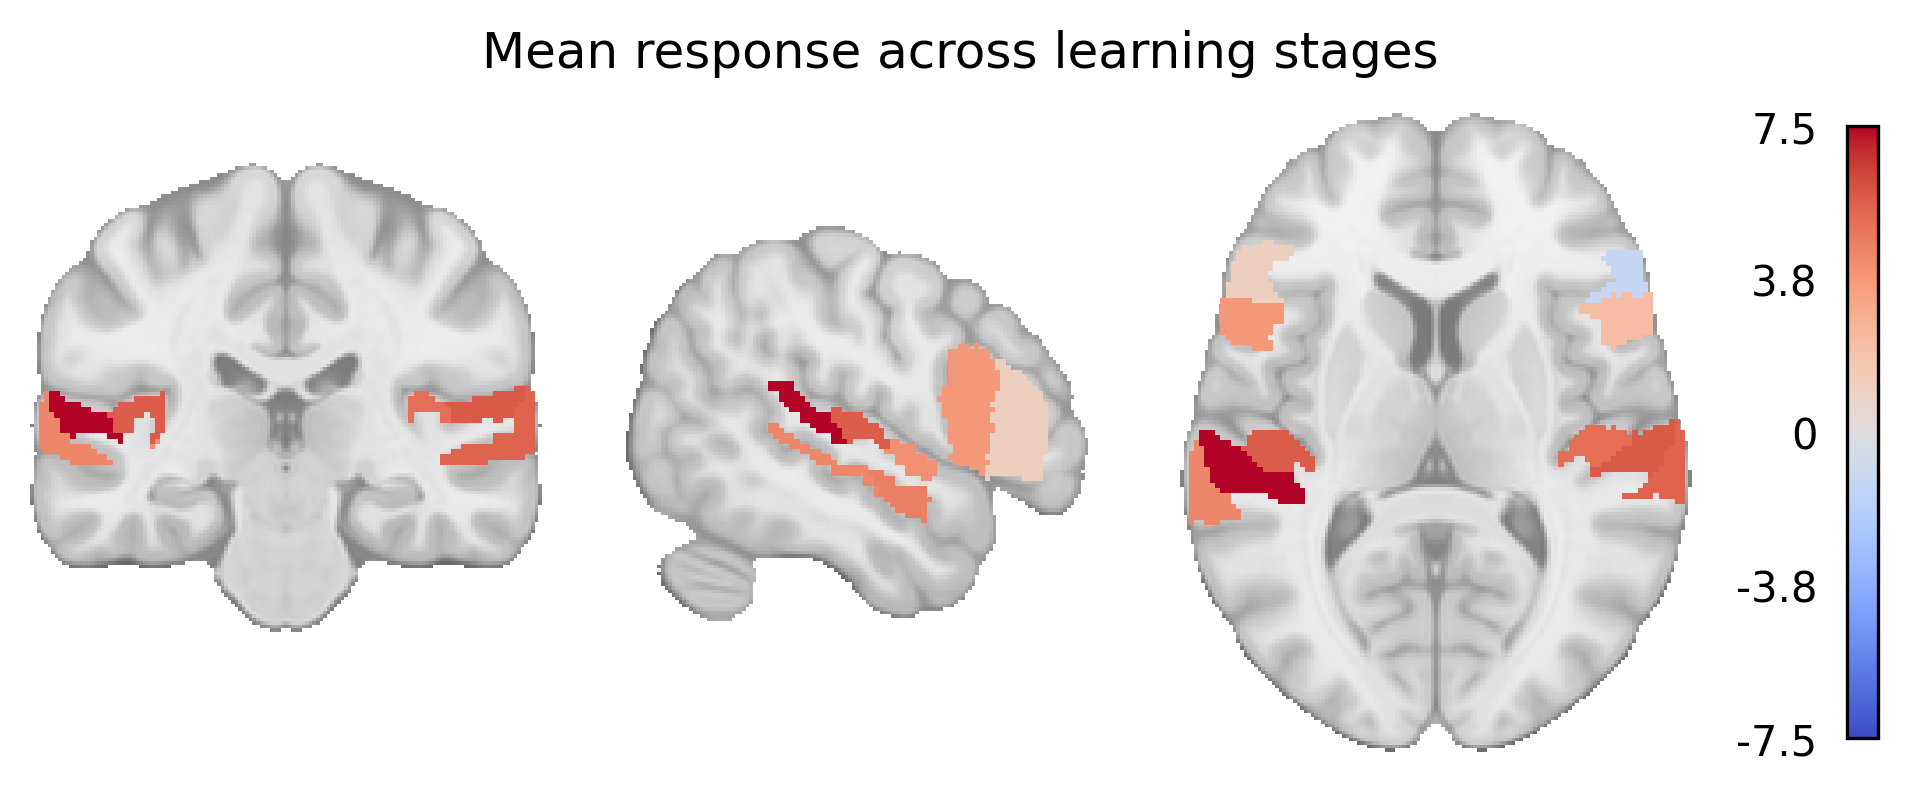

In [139]:
fig = plot_roi_slices_avg([roi_earlythird_mean_dict, roi_middlethird_mean_dict, roi_latethird_mean_dict],
                          mask_path_list, 'dseg', space_label)

In [85]:
plot_order = ['HG', 'PT', 'PP', 'STGp', 'STGa', 'ParsOp', 'ParsTri', ]

/scratch/slurm-8704965/ipykernel_4038713/2807131526.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center')


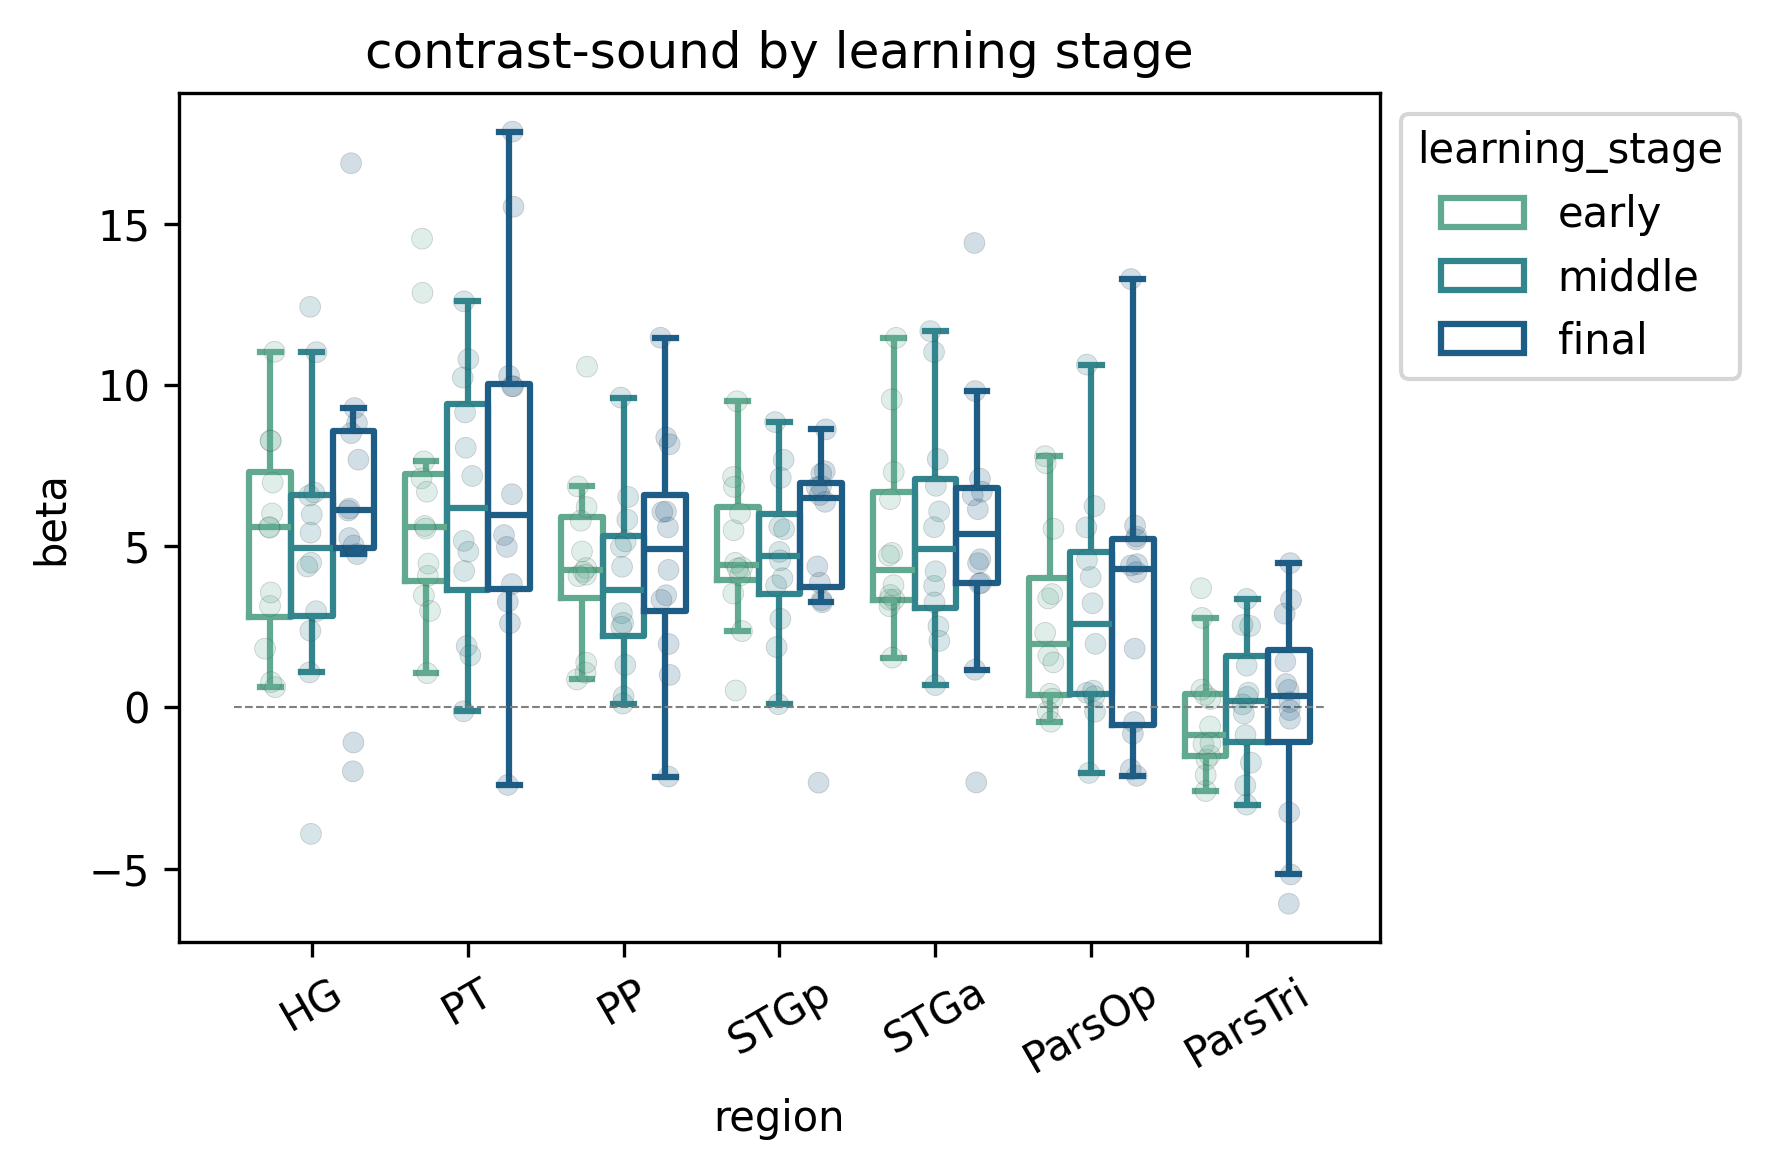

In [86]:
fig, ax = plt.subplots(1, 1, figsize=(6,4), dpi=300)

roi_df_collapsed = roi_df_long.groupby(["participant_id", "region", 'learning_stage'], 
                                       as_index=False).agg({"beta": "mean"})

sns.boxplot(data=roi_df_collapsed, 
              x='region', y='beta', 
              hue='learning_stage', hue_order=['early', 'middle', 'final'],
              order=plot_order,
              palette='crest',
              fliersize = 0,            
              linewidth=1.5,
              fill=False,
              #legend=None,
              ax=ax);
sns.stripplot(data=roi_df_collapsed, 
              x='region', y='beta', 
              hue='learning_stage', hue_order=['early', 'middle', 'final'],
              order=plot_order,
              palette='crest',
              dodge=True,
              linewidth=0.2,
              alpha=.2,
              legend=None,
              ax=ax);


xmin, xmax = ax.get_xlim()
ax.hlines(y=0, xmin=xmin, xmax=xmax, color='0.5', linestyle='--', linewidth=0.5)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_title(f'contrast-{contrast_label} by learning stage');
#ax.set_ylim([-5, 5])

fig.tight_layout()


/scratch/slurm-8704965/ipykernel_4038713/3935233491.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center')


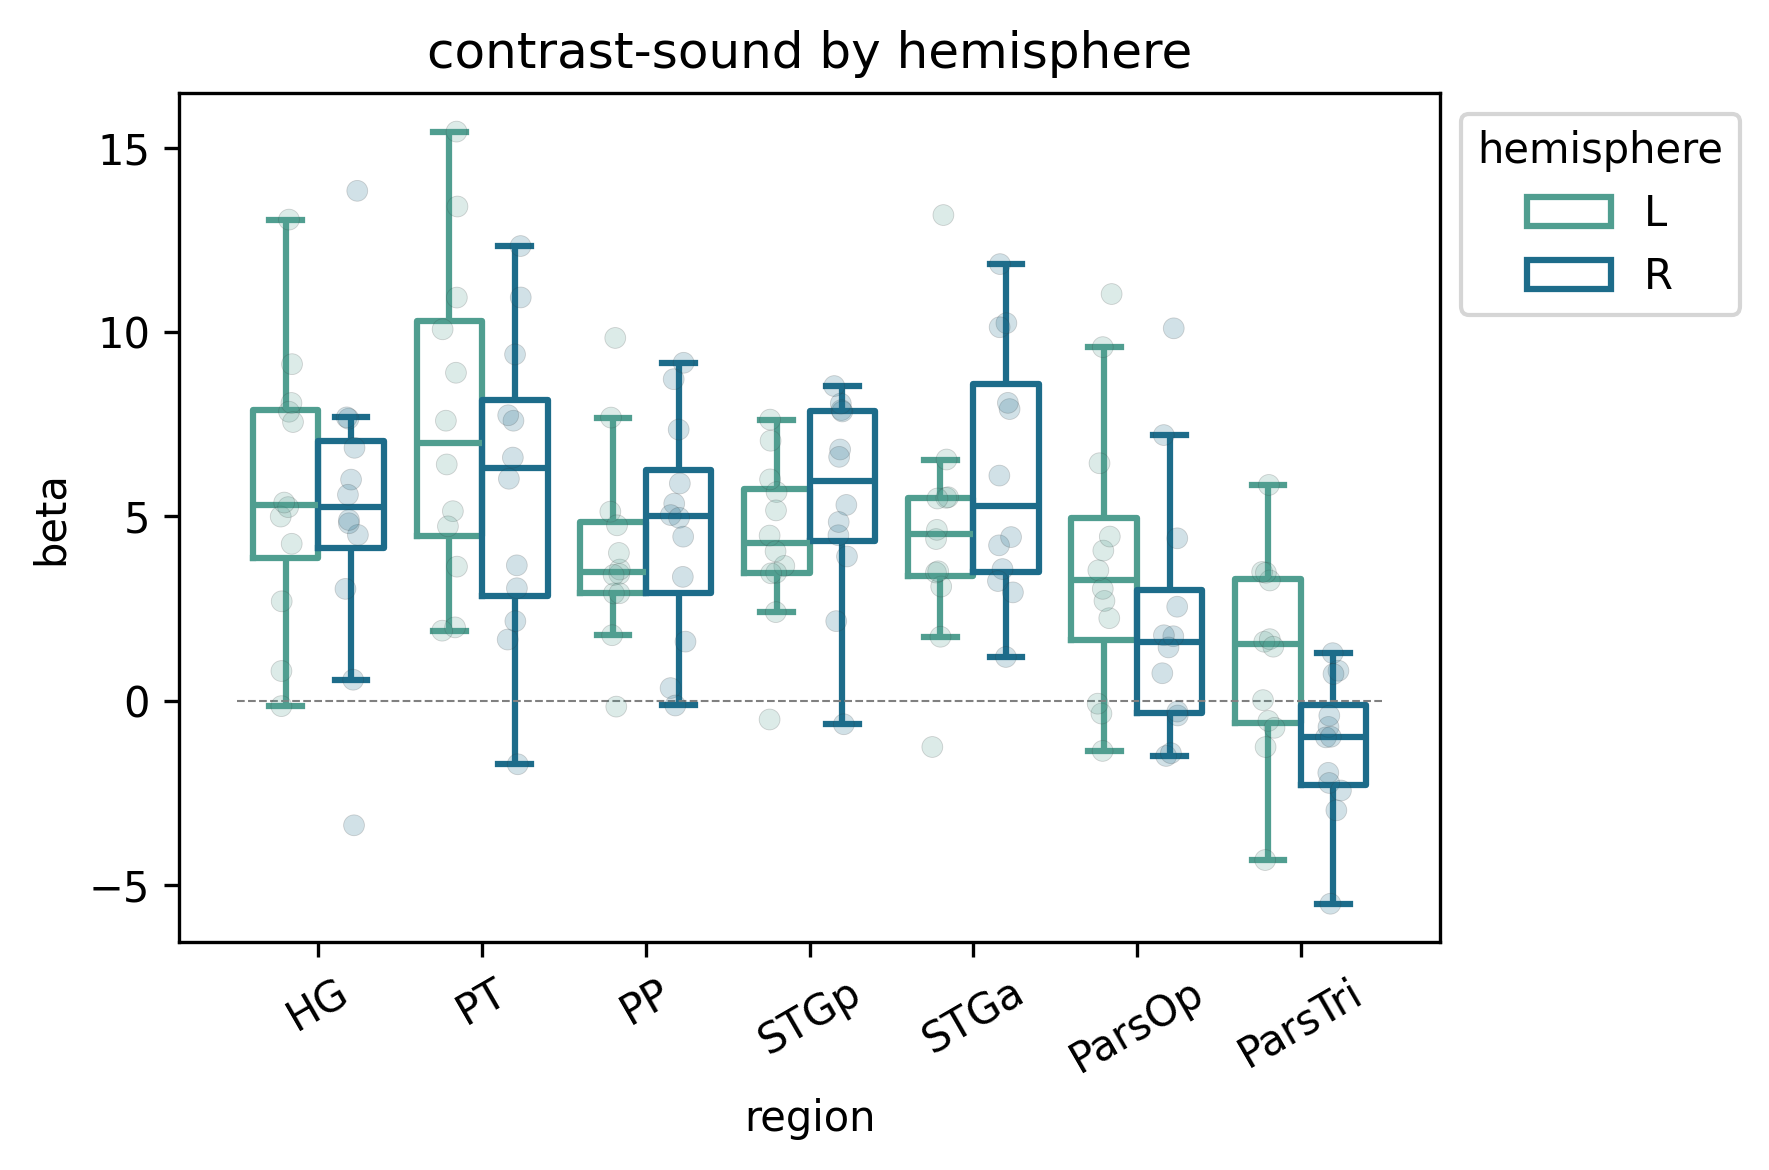

In [87]:
fig, ax = plt.subplots(1, 1, figsize=(6,4), dpi=300)

roi_df_collapsed = roi_df_long.groupby(["participant_id", "region", 'hemisphere'], 
                                       as_index=False).agg({"beta": "mean"})

sns.boxplot(data=roi_df_collapsed, 
              x='region', y='beta', 
              hue='hemisphere', #hue_order=['early', 'middle', 'final'],
              order=plot_order,
              palette='crest',
              fliersize = 0,            
              linewidth=1.5,
              fill=False,
              #legend=None,
              ax=ax);
sns.stripplot(data=roi_df_collapsed, 
              x='region', y='beta', 
              hue='hemisphere', #hue_order=['early', 'middle', 'final'],
              order=plot_order,
              palette='crest',
              dodge=True,
              linewidth=0.2,
              alpha=.2,
              legend=None,
              ax=ax);


xmin, xmax = ax.get_xlim()
ax.hlines(y=0, xmin=xmin, xmax=xmax, color='0.5', linestyle='--', linewidth=0.5)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_title(f'contrast-{contrast_label} by hemisphere');
#ax.set_ylim([-5, 5])

fig.tight_layout()


### Brain-behavior correlations

In [88]:
# map runs to learning stages matching your thirds
stage_map = {'run-01': 'early', 'run-02': 'early',
             'run-03': 'middle', 'run-04': 'middle',
             'run-05': 'final', 'run-06': 'final'}

acc_df['learning_stage'] = acc_df['run'].map(stage_map)
acc_stage_df = acc_df.groupby(['participant_id', 'learning_stage'])['accuracy'].mean().reset_index()

#### Averaged across learning stages

In [89]:
# merge into roi_df_long — assumes participant_id and learning_stage columns exist in both
roi_df_bilateral = (roi_df_long.groupby(['participant_id', 'region'], as_index=False)['beta'].mean())
roi_behav_df = roi_df_bilateral.merge(acc_stage_df, on=['participant_id'])

# verify
roi_behav_df.groupby(['region']).size().unique()  # should be array([12])


array([36])

In [90]:
roi_behav_df.columns

Index(['participant_id', 'region', 'beta', 'learning_stage', 'accuracy'], dtype='object')

In [91]:
roi_behav_df.participant_id.unique()

array(['sub-FLT02', 'sub-FLT04', 'sub-FLT06', 'sub-FLT09', 'sub-FLT11',
       'sub-FLT12', 'sub-FLT13', 'sub-FLT14', 'sub-FLT20', 'sub-FLT25',
       'sub-FLT28', 'sub-FLT30'], dtype=object)

In [92]:
roi_behav_df.groupby(['region','learning_stage']).size().unique()


array([12])

In [93]:
results = []
for roi in plot_order: # roi_behav_df['region'].unique():
    sub_df = roi_behav_df[roi_behav_df['region'] == roi]
    r = pg.corr(sub_df['accuracy'], sub_df['beta'], method='pearson')
    results.append({
        'roi': roi,
        'r': r['r'].values[0],
        'p': r['p-val'].values[0],
        'n': r['n'].values[0],
        'stat_str': stat_str('r', r['r'].values[0], r['p-val'].values[0])
    })

behav_corr_df = pd.DataFrame(results)

In [94]:
behav_corr_df

,roi,r,p,n,stat_str
0,HG,0.1225,0.4767,36,"r = .12, p = .477"
1,PT,0.0558,0.7465,36,"r = .06, p = .747"
2,PP,0.0005,0.9979,36,"r = .00, p = .998"
3,STGp,-0.1240,0.4713,36,"r = -.12, p = .471"
4,STGa,-0.3542,0.0340,36,"r = -.35, p = .034"
5,ParsOp,-0.1358,0.4298,36,"r = -.14, p = .430"
6,ParsTri,-0.0895,0.6039,36,"r = -.09, p = .604"


#### Per learning stage

In [95]:
# merge into roi_df_long — assumes participant_id and learning_stage columns exist in both
roi_df_bilateral = (roi_df_long.groupby(['participant_id', 'region', 'learning_stage'], as_index=False)['beta'].mean())
roi_behav_df = roi_df_bilateral.merge(acc_stage_df, on=['participant_id', 'learning_stage'])

# verify
roi_behav_df.groupby(['region', 'learning_stage']).size().unique()  # should be array([12])


array([12])

In [96]:
roi_behav_df.columns

Index(['participant_id', 'region', 'learning_stage', 'beta', 'accuracy'], dtype='object')

In [97]:
roi_behav_df.participant_id.unique()

array(['sub-FLT02', 'sub-FLT04', 'sub-FLT06', 'sub-FLT09', 'sub-FLT11',
       'sub-FLT12', 'sub-FLT13', 'sub-FLT14', 'sub-FLT20', 'sub-FLT25',
       'sub-FLT28', 'sub-FLT30'], dtype=object)

In [98]:
results = []
for stage in ['early', 'middle', 'final']:
    stage_df = roi_behav_df[roi_behav_df['learning_stage'] == stage]
    for roi in plot_order: # stage_df['region'].unique():
        sub_df = stage_df[stage_df['region'] == roi]
        r = pg.corr(sub_df['accuracy'], sub_df['beta'], method='pearson')
        results.append({
            'roi': roi,
            'learning_stage': stage,
            'r': r['r'].values[0],
            'p': r['p-val'].values[0],
            'n': r['n'].values[0],
            'stat_str': stat_str('r', r['r'].values[0], r['p-val'].values[0])
        })

behav_corr_df = pd.DataFrame(results)

In [99]:
behav_corr_df

,roi,learning_stage,r,p,n,stat_str
0,HG,early,0.0458,0.8876,12,"r = .05, p = .888"
1,PT,early,0.0548,0.8656,12,"r = .05, p = .866"
2,PP,early,0.1540,0.6329,12,"r = .15, p = .633"
3,STGp,early,-0.0417,0.8976,12,"r = -.04, p = .898"
4,STGa,early,-0.1341,0.6777,12,"r = -.13, p = .678"
5,ParsOp,early,-0.0608,0.8511,12,"r = -.06, p = .851"
6,ParsTri,early,0.0021,0.9949,12,"r = .00, p = .995"
7,HG,middle,0.0514,0.8738,12,"r = .05, p = .874"
8,PT,middle,-0.0404,0.9008,12,"r = -.04, p = .901"
9,PP,middle,-0.1359,0.6738,12,"r = -.14, p = .674"


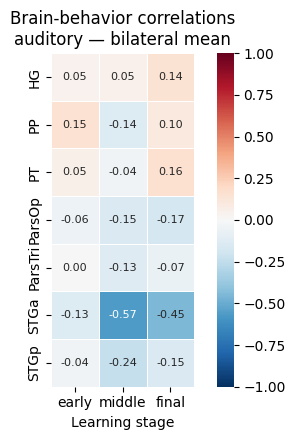

In [308]:
# pivot to ROI × stage matrix
r_matrix = behav_corr_df.pivot(index='roi', columns='learning_stage', values='r')[['early', 'middle', 'final']]
p_matrix = behav_corr_df.pivot(index='roi', columns='learning_stage', values='p')[['early', 'middle', 'final']]

fig, ax = plt.subplots(figsize=(5, len(r_matrix) * 0.5 + 1), dpi=100)
sns.heatmap(r_matrix, ax=ax, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, annot=True, fmt='.2f', annot_kws={'size': 8},
            square=True)

# mark significant cells with an asterisk
for i, roi in enumerate(r_matrix.index):
    for j, stage in enumerate(['early', 'middle', 'final']):
        p = p_matrix.loc[roi, stage]
        if p < 0.05:
            ax.text(j + 0.5, i + 0.85, '*', ha='center', va='center',
                    fontsize=12, color='black')

ax.set_title(f'Brain-behavior correlations\n{network_name} — bilateral mean')
ax.set_ylabel('')
ax.set_xlabel('Learning stage')
plt.tight_layout()

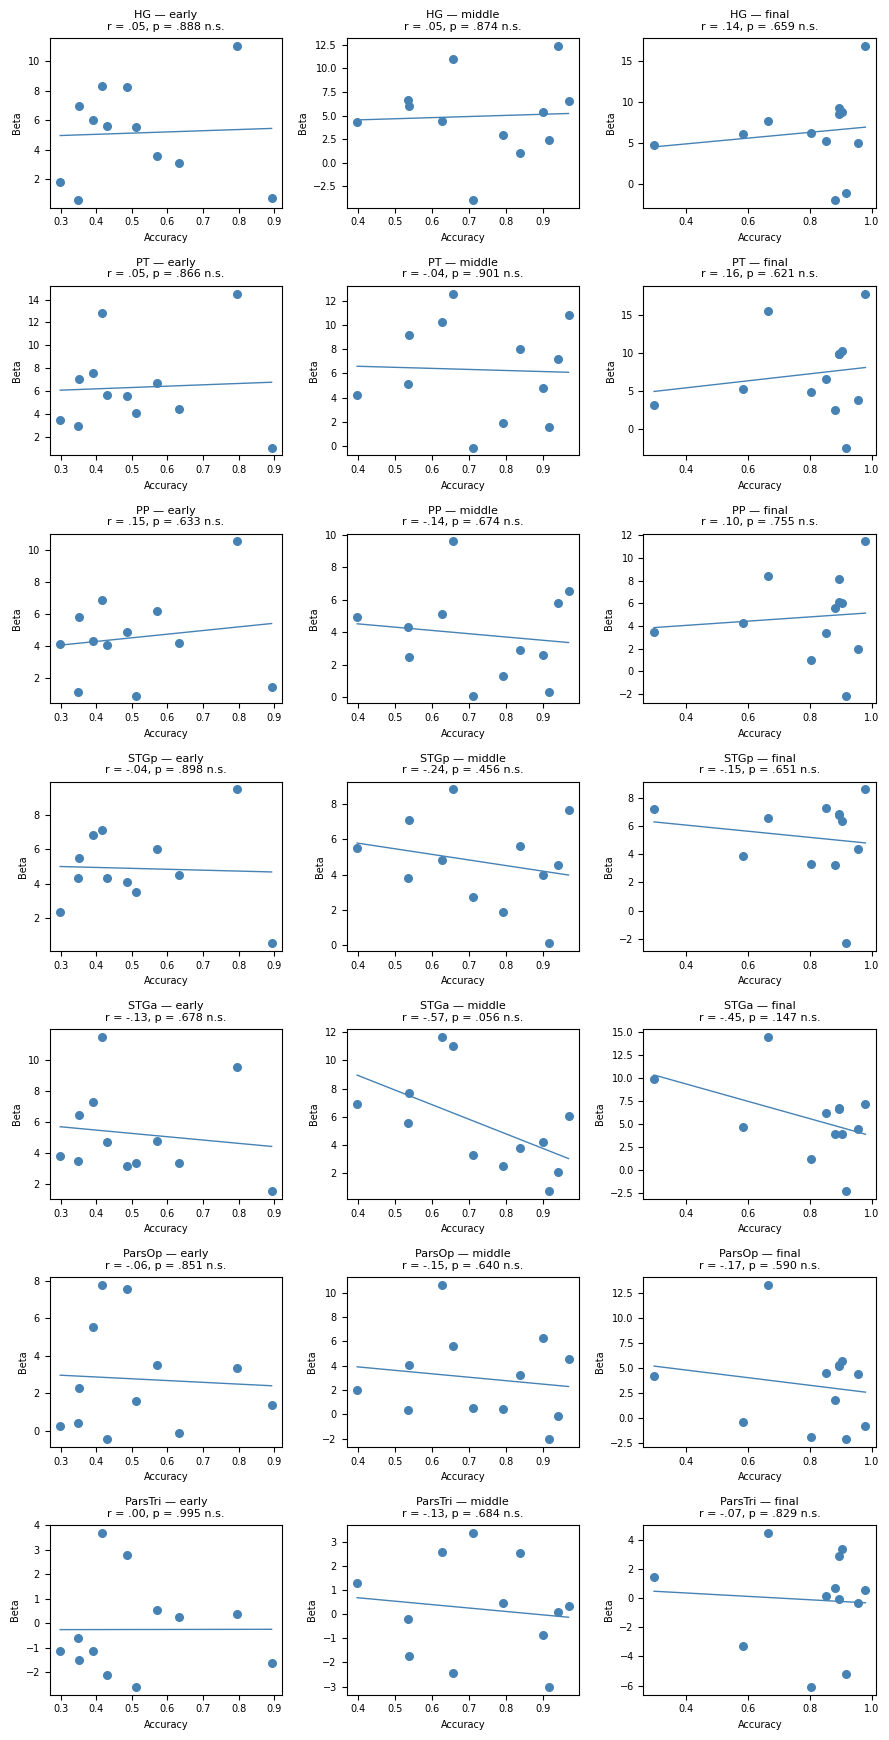

In [100]:
rois = behav_corr_df['roi'].unique()
stages = ['early', 'middle', 'final']

fig, axes = plt.subplots(len(rois), 3, figsize=(9, len(rois) * 2.5), dpi=100, sharex=False, sharey=False)

for ri, roi in enumerate(plot_order): # rois):
    for si, stage in enumerate(stages):
        ax = axes[ri, si]
        sub_df = roi_behav_df[(roi_behav_df['region'] == roi) & 
                              (roi_behav_df['learning_stage'] == stage)]
        
        ax.scatter(sub_df['accuracy'], sub_df['beta'], s=30, color='steelblue', zorder=3)
        
        # regression line
        m, b = np.polyfit(sub_df['accuracy'], sub_df['beta'], 1)
        x_range = np.linspace(sub_df['accuracy'].min(), sub_df['accuracy'].max(), 100)
        ax.plot(x_range, m * x_range + b, color='steelblue', linewidth=1)
        
        # stat annotation
        row = behav_corr_df[(behav_corr_df['roi'] == roi) & 
                            (behav_corr_df['learning_stage'] == stage)].iloc[0]
        p_str = '*' if row['p'] < 0.05 else 'n.s.'
        ax.set_title(f"{roi} — {stage}\n{row['stat_str']} {p_str}", fontsize=8)
        ax.set_xlabel('Accuracy', fontsize=7)
        ax.set_ylabel('Beta', fontsize=7)
        ax.tick_params(labelsize=7)

plt.tight_layout()


HG early: r = .05, p = .888 n.s.
HG middle: r = .05, p = .874 n.s.
HG final: r = .14, p = .659 n.s.
PT early: r = .05, p = .866 n.s.
PT middle: r = -.04, p = .901 n.s.
PT final: r = .16, p = .621 n.s.
PP early: r = .15, p = .633 n.s.
PP middle: r = -.14, p = .674 n.s.
PP final: r = .10, p = .755 n.s.
STGp early: r = -.04, p = .898 n.s.
STGp middle: r = -.24, p = .456 n.s.
STGp final: r = -.15, p = .651 n.s.
STGa early: r = -.13, p = .678 n.s.
STGa middle: r = -.57, p = .056 n.s.
STGa final: r = -.45, p = .147 n.s.
ParsOp early: r = -.06, p = .851 n.s.
ParsOp middle: r = -.15, p = .640 n.s.
ParsOp final: r = -.17, p = .590 n.s.
ParsTri early: r = .00, p = .995 n.s.
ParsTri middle: r = -.13, p = .684 n.s.
ParsTri final: r = -.07, p = .829 n.s.


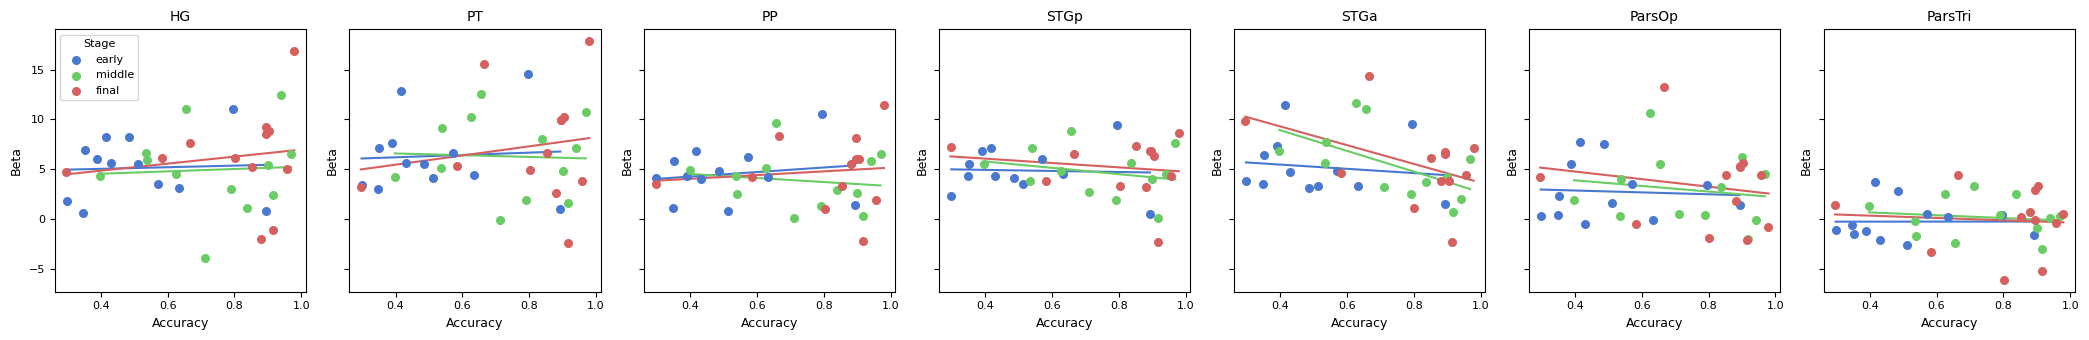

In [101]:
stage_colors = {'early': '#4878CF', 'middle': '#6ACC65', 'final': '#D65F5F'}
stages = ['early', 'middle', 'final']
rois = behav_corr_df['roi'].unique()

fig, axes = plt.subplots(1, len(rois), figsize=(3 * len(rois), 3.5), dpi=100, sharey=True)
if len(rois) == 1:
    axes = [axes]

for ri, roi in enumerate(plot_order): # rois):
    ax = axes[ri]
    for stage in stages:
        color = stage_colors[stage]
        sub_df = roi_behav_df[(roi_behav_df['region'] == roi) &
                              (roi_behav_df['learning_stage'] == stage)]

        ax.scatter(sub_df['accuracy'], sub_df['beta'], s=30,
                   color=color, label=stage, zorder=3)

        m, b = np.polyfit(sub_df['accuracy'], sub_df['beta'], 1)
        x_range = np.linspace(sub_df['accuracy'].min(), sub_df['accuracy'].max(), 100)
        ax.plot(x_range, m * x_range + b, color=color, linewidth=1.5)

        # stat annotation per stage
        row = behav_corr_df[(behav_corr_df['roi'] == roi) &
                            (behav_corr_df['learning_stage'] == stage)].iloc[0]
        p_str = '*' if row['p'] < 0.05 else 'n.s.'
        print(f"{roi} {stage}: {row['stat_str']} {p_str}")

    ax.set_title(roi, fontsize=10)
    ax.set_xlabel('Accuracy', fontsize=9)
    ax.set_ylabel('Beta', fontsize=9)
    ax.tick_params(labelsize=8)

axes[0].legend(title='Stage', fontsize=8, title_fontsize=8)
plt.tight_layout()


### omnibus ANOVA stats

In [102]:
# Mixed-Effects ANOVA with Hemisphere, Region, and Interaction
aov = AnovaRM(non_mandarin_df, 
              aggregate_func='mean',
              depvar='beta', 
              subject='participant_id', 
              within=['hemisphere', 'learning_stage','region', ]).fit()

# Display results
print('network:', network_name)
print('contrast:', contrast_label)
print(aov)


network: auditory
contrast: sound
                             Anova
                                 F Value  Num DF  Den DF  Pr > F
----------------------------------------------------------------
hemisphere                        2.1057  1.0000  11.0000 0.1747
learning_stage                    0.5528  2.0000  22.0000 0.5831
region                           15.2165  6.0000  66.0000 0.0000
hemisphere:learning_stage         4.0239  2.0000  22.0000 0.0324
hemisphere:region                 5.6363  6.0000  66.0000 0.0001
learning_stage:region             0.5524 12.0000 132.0000 0.8762
hemisphere:learning_stage:region  0.4041 12.0000 132.0000 0.9599



/bgfs/bchandrasekaran/krs228/software/miniconda3/envs/py3/lib/python3.9/site-packages/statsmodels/iolib/summary2.py:579: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  dat = dat.applymap(lambda x: _formatter(x, float_format))


In [104]:
export_anova(aov, f'{contrast_label}_{network_name}_hemisphere_learning-stage_region', stats_out_dir)

,source,F,df_num,df_den,p,stat_str
0,hemisphere,2.1057,1.0000,11.0000,0.1747,"F(1, 11) = 2.11, p = .175"
1,learning_stage,0.5528,2.0000,22.0000,0.5831,"F(2, 22) = 0.55, p = .583"
2,region,15.2165,6.0000,66.0000,0.0000,"F(6, 66) = 15.22, p < .001"
3,hemisphere:learning_stage,4.0239,2.0000,22.0000,0.0324,"F(2, 22) = 4.02, p = .032"
4,hemisphere:region,5.6363,6.0000,66.0000,0.0001,"F(6, 66) = 5.64, p < .001"
5,learning_stage:region,0.5524,12.0000,132.0000,0.8762,"F(12, 132) = 0.55, p = .876"
6,hemisphere:learning_stage:region,0.4041,12.0000,132.0000,0.9599,"F(12, 132) = 0.40, p = .960"


In [105]:
aov.summary().tables[0]

,F Value,Num DF,Den DF,Pr > F
hemisphere,2.1057,1.0000,11.0000,0.1747
learning_stage,0.5528,2.0000,22.0000,0.5831
region,15.2165,6.0000,66.0000,0.0000
hemisphere:learning_stage,4.0239,2.0000,22.0000,0.0324
hemisphere:region,5.6363,6.0000,66.0000,0.0001
learning_stage:region,0.5524,12.0000,132.0000,0.8762
hemisphere:learning_stage:region,0.4041,12.0000,132.0000,0.9599


In [106]:
import pingouin as pg

# Pairwise comparisons for region with FDR correction
pairwise_by_learning_stage = pg.pairwise_tests(data=non_mandarin_df,
                             dv='beta', 
                             within=['hemisphere','region', ],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise_by_learning_stage.columns)

# Display key columns (without 'effsize' and 'CIs' if missing)
print("\nPost-hoc Pairwise Comparisons:")
#print(pairwise_by_learning_stage)
#pairwise_by_learning_stage[['Contrast', 'learning_stage', 'A', 'B', 'T', 'dof', 'p-unc', 'p-corr', 'BF10']]  # Keep only available columns

pd.set_option('display.max_rows', None)

pairwise_interaction = pairwise_by_learning_stage[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
pairwise_interaction = pairwise_interaction[pairwise_interaction['p-corr'] < 0.05].reset_index()
pairwise_interaction[['Contrast', 'hemisphere', 'A', 'B', 'T', 'dof', 'p-unc', 'p-corr', 'BF10']]

Available columns: Index(['Contrast', 'hemisphere', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof',
       'alternative', 'p-unc', 'p-corr', 'p-adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,hemisphere,A,B,T,dof,p-unc,p-corr,BF10
0,hemisphere * region,L,HG,PT,-3.0323,11.0000,0.0114,0.0252,5.321
1,hemisphere * region,L,HG,ParsTri,4.0845,11.0000,0.0018,0.0076,24.34
2,hemisphere * region,L,PP,PT,-4.8703,11.0000,0.0005,0.0035,72.903
3,hemisphere * region,L,PP,ParsTri,3.9824,11.0000,0.0021,0.0082,21.038
4,hemisphere * region,L,PT,ParsOp,3.2058,11.0000,0.0084,0.0195,6.841
5,hemisphere * region,L,PT,ParsTri,5.4439,11.0000,0.0002,0.0017,156.618
6,hemisphere * region,L,PT,STGa,2.9405,11.0000,0.0134,0.0282,4.661
7,hemisphere * region,L,PT,STGp,3.7061,11.0000,0.0035,0.0104,14.132
8,hemisphere * region,L,ParsOp,ParsTri,3.5084,11.0000,0.0049,0.0124,10.613
9,hemisphere * region,L,ParsTri,STGa,-4.5724,11.0000,0.0008,0.0042,48.394


In [107]:
# pairwise by region

# Pairwise comparisons for region with FDR correction
pairwise_by_region = pg.pairwise_tests(data=non_mandarin_df,
                             dv='beta', 
                             within=['region', 'hemisphere',],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise_by_region.columns)

# Display key columns (without 'effsize' and 'CIs' if missing)
print("\nPost-hoc Pairwise Comparisons:")
#print(pairwise_by_region)
#pairwise_by_region[['Contrast', 'learning_stage', 'A', 'B', 'T', 'dof', 'p-unc', 'p-corr', 'BF10']]  # Keep only available columns

pd.set_option('display.max_rows', None)

pairwise_interaction = pairwise_by_region[pairwise_by_region.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05]
pairwise_interaction[['Contrast', 'region', 'A', 'B', 'T', 'dof', 'p-unc', 'p-corr', 'BF10']]

Available columns: Index(['Contrast', 'region', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof',
       'alternative', 'p-unc', 'p-corr', 'p-adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,region,A,B,T,dof,p-unc,p-corr,BF10
0,region * hemisphere,HG,L,R,0.8281,11.0000,0.4252,0.4252,0.384
1,region * hemisphere,PP,L,R,-1.0713,11.0000,0.3070,0.3581,0.463
2,region * hemisphere,PT,L,R,2.9490,11.0000,0.0132,0.0463,4.718
3,region * hemisphere,ParsOp,L,R,1.7164,11.0000,0.1141,0.1597,0.899
4,region * hemisphere,ParsTri,L,R,3.5230,11.0000,0.0048,0.0334,10.841
5,region * hemisphere,STGa,L,R,-2.0968,11.0000,0.0599,0.1049,1.445
6,region * hemisphere,STGp,L,R,-2.2620,11.0000,0.0449,0.1048,1.8


In [108]:
export_posthoc(pairwise_by_region, f'{contrast_label}_{network_name}_region_hemisphere', stats_out_dir)

,Contrast,region,A,B,t,df,p,p_fdr,stat_str,p_fdr_str
0,region,-,HG,PP,1.6112,11.0000,0.1354,0.1798,"t(11) = 1.61, p = .135",p = .180
1,region,-,HG,PT,-1.7662,11.0000,0.1051,0.1697,"t(11) = -1.77, p = .105",p = .170
2,region,-,HG,ParsOp,2.0107,11.0000,0.0695,0.1217,"t(11) = 2.01, p = .070",p = .122
3,region,-,HG,ParsTri,4.7144,11.0000,0.0006,0.0027,"t(11) = 4.71, p < .001",p = .003
4,region,-,HG,STGa,0.0497,11.0000,0.9612,0.9612,"t(11) = 0.05, p = .961",p = .961
5,region,-,HG,STGp,0.6864,11.0000,0.5067,0.5320,"t(11) = 0.69, p = .507",p = .532
6,region,-,PP,PT,-3.8789,11.0000,0.0026,0.0067,"t(11) = -3.88, p = .003",p = .007
7,region,-,PP,ParsOp,1.5254,11.0000,0.1554,0.1813,"t(11) = 1.53, p = .155",p = .181
8,region,-,PP,ParsTri,6.7293,11.0000,0.0000,0.0002,"t(11) = 6.73, p < .001",p < .001
9,region,-,PP,STGa,-1.5836,11.0000,0.1416,0.1798,"t(11) = -1.58, p = .142",p = .180


In [109]:

# Pairwise comparisons for region with FDR correction
pairwise_by_learning_stage = pg.pairwise_tests(data=non_mandarin_df,
                             dv='beta', 
                             within=['hemisphere','learning_stage', ],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise_by_learning_stage.columns)

# Display key columns (without 'effsize' and 'CIs' if missing)
print("\nPost-hoc Pairwise Comparisons:")
#print(pairwise_by_learning_stage)
#pairwise_by_learning_stage[['Contrast', 'learning_stage', 'A', 'B', 'T', 'dof', 'p-unc', 'p-corr', 'BF10']]  # Keep only available columns

pd.set_option('display.max_rows', None)

pairwise_interaction = pairwise_by_learning_stage[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-corr'] < 0.05].reset_index()
pairwise_interaction[['Contrast', 'hemisphere', 'A', 'B', 'T', 'dof', 'p-unc', 'p-corr', 'BF10']]

Available columns: Index(['Contrast', 'hemisphere', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof',
       'alternative', 'p-unc', 'p-corr', 'p-adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,hemisphere,A,B,T,dof,p-unc,p-corr,BF10
0,hemisphere * learning_stage,L,early,final,-0.1118,11.0000,0.9130,0.9130,0.289
1,hemisphere * learning_stage,L,early,middle,0.4121,11.0000,0.6882,0.8887,0.309
2,hemisphere * learning_stage,L,final,middle,0.5205,11.0000,0.6130,0.8887,0.323
3,hemisphere * learning_stage,R,early,final,-1.5189,11.0000,0.1570,0.8277,0.717
4,hemisphere * learning_stage,R,early,middle,-0.3396,11.0000,0.7406,0.8887,0.302
5,hemisphere * learning_stage,R,final,middle,1.1465,11.0000,0.2759,0.8277,0.494


In [110]:
export_posthoc(pairwise_by_learning_stage, f'{contrast_label}_{network_name}_hemisphere_learning-stage', stats_out_dir)

,Contrast,hemisphere,A,B,t,df,p,p_fdr,stat_str,p_fdr_str
0,hemisphere,-,L,R,1.4511,11.0000,0.1747,NaN,"t(11) = 1.45, p = .175",p = nan
1,learning_stage,-,early,final,-0.9063,11.0000,0.3842,0.6059,"t(11) = -0.91, p = .384",p = .606
2,learning_stage,-,early,middle,0.0547,11.0000,0.9573,0.9573,"t(11) = 0.05, p = .957",p = .957
3,learning_stage,-,final,middle,0.8680,11.0000,0.4039,0.6059,"t(11) = 0.87, p = .404",p = .606
4,hemisphere * learning_stage,L,early,final,-0.1118,11.0000,0.9130,0.9130,"t(11) = -0.11, p = .913",p = .913
5,hemisphere * learning_stage,L,early,middle,0.4121,11.0000,0.6882,0.8887,"t(11) = 0.41, p = .688",p = .889
6,hemisphere * learning_stage,L,final,middle,0.5205,11.0000,0.6130,0.8887,"t(11) = 0.52, p = .613",p = .889
7,hemisphere * learning_stage,R,early,final,-1.5189,11.0000,0.1570,0.8277,"t(11) = -1.52, p = .157",p = .828
8,hemisphere * learning_stage,R,early,middle,-0.3396,11.0000,0.7406,0.8887,"t(11) = -0.34, p = .741",p = .889
9,hemisphere * learning_stage,R,final,middle,1.1465,11.0000,0.2759,0.8277,"t(11) = 1.15, p = .276",p = .828


In [111]:

# Pairwise comparisons for region with FDR correction
pairwise_by_learning_stage = pg.pairwise_tests(data=non_mandarin_df,
                             dv='beta', 
                             within=['learning_stage','hemisphere', ],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise_by_learning_stage.columns)

# Display key columns (without 'effsize' and 'CIs' if missing)
print("\nPost-hoc Pairwise Comparisons:")
#print(pairwise_by_learning_stage)
#pairwise_by_learning_stage[['Contrast', 'learning_stage', 'A', 'B', 'T', 'dof', 'p-unc', 'p-corr', 'BF10']]  # Keep only available columns

pd.set_option('display.max_rows', None)

pairwise_interaction = pairwise_by_learning_stage[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-corr'] < 0.05].reset_index()
pairwise_interaction[['Contrast', 'learning_stage', 'A', 'B', 'T', 'dof', 'p-unc', 'p-corr', 'BF10']]

Available columns: Index(['Contrast', 'learning_stage', 'A', 'B', 'Paired', 'Parametric', 'T',
       'dof', 'alternative', 'p-unc', 'p-corr', 'p-adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,learning_stage,A,B,T,dof,p-unc,p-corr,BF10
0,learning_stage * hemisphere,early,L,R,2.4123,11.0000,0.0345,0.1034,2.209
1,learning_stage * hemisphere,final,L,R,-0.0284,11.0000,0.9778,0.9778,0.287
2,learning_stage * hemisphere,middle,L,R,1.5725,11.0000,0.1441,0.2162,0.761


In [112]:
export_posthoc(pairwise_by_learning_stage, f'{contrast_label}_{network_name}_learning-stage_hemisphere', stats_out_dir)

,Contrast,learning_stage,A,B,t,df,p,p_fdr,stat_str,p_fdr_str
0,learning_stage,-,early,final,-0.9063,11.0000,0.3842,0.6059,"t(11) = -0.91, p = .384",p = .606
1,learning_stage,-,early,middle,0.0547,11.0000,0.9573,0.9573,"t(11) = 0.05, p = .957",p = .957
2,learning_stage,-,final,middle,0.8680,11.0000,0.4039,0.6059,"t(11) = 0.87, p = .404",p = .606
3,hemisphere,-,L,R,1.4511,11.0000,0.1747,NaN,"t(11) = 1.45, p = .175",p = nan
4,learning_stage * hemisphere,early,L,R,2.4123,11.0000,0.0345,0.1034,"t(11) = 2.41, p = .034",p = .103
5,learning_stage * hemisphere,final,L,R,-0.0284,11.0000,0.9778,0.9778,"t(11) = -0.03, p = .978",p = .978
6,learning_stage * hemisphere,middle,L,R,1.5725,11.0000,0.1441,0.2162,"t(11) = 1.57, p = .144",p = .216


In [113]:
# pairwise by region, no learning stage

# Pairwise comparisons for region with FDR correction
pairwise_by_region_only = pg.pairwise_tests(data=non_mandarin_df,
                             dv='beta', 
                             within=['region', ],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise_by_region_only.columns)

# Display key columns (without 'effsize' and 'CIs' if missing)
print("\nPost-hoc Pairwise Comparisons:")
#print(pairwise_by_region_only)
pairwise_by_region_only = pairwise_by_region_only[pairwise_by_region_only['p-unc'] < 0.05]
pairwise_by_region_only[['Contrast', 'Contrast', 'A', 'B', 'T', 'dof', 'p-unc', 'p-corr', 'BF10']]  # Keep only available columns


Available columns: Index(['Contrast', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof', 'alternative',
       'p-unc', 'p-corr', 'p-adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Contrast,A,B,T,dof,p-unc,p-corr,BF10
3,region,region,HG,ParsTri,4.7144,11.0000,0.0006,0.0027,58.892
6,region,region,PP,PT,-3.8789,11.0000,0.0026,0.0067,18.133
8,region,region,PP,ParsTri,6.7293,11.0000,0.0000,0.0002,768.164
11,region,region,PT,ParsOp,3.7051,11.0000,0.0035,0.0081,14.113
12,region,region,PT,ParsTri,6.6226,11.0000,0.0000,0.0002,677.546
14,region,region,PT,STGp,2.4507,11.0000,0.0322,0.0676,2.329
15,region,region,ParsOp,ParsTri,4.4314,11.0000,0.0010,0.0035,39.752
16,region,region,ParsOp,STGa,-3.9048,11.0000,0.0025,0.0067,18.82
17,region,region,ParsOp,STGp,-2.3594,11.0000,0.0379,0.0723,2.054
18,region,region,ParsTri,STGa,-7.4925,11.0000,0.0000,0.0001,1823.611


In [114]:
export_posthoc(pairwise_by_region_only, f'{contrast_label}_{network_name}_region', stats_out_dir)

,Contrast,A,B,t,df,p,p_fdr,stat_str,p_fdr_str
3,region,HG,ParsTri,4.7144,11.0000,0.0006,0.0027,"t(11) = 4.71, p < .001",p = .003
6,region,PP,PT,-3.8789,11.0000,0.0026,0.0067,"t(11) = -3.88, p = .003",p = .007
8,region,PP,ParsTri,6.7293,11.0000,0.0000,0.0002,"t(11) = 6.73, p < .001",p < .001
11,region,PT,ParsOp,3.7051,11.0000,0.0035,0.0081,"t(11) = 3.71, p = .003",p = .008
12,region,PT,ParsTri,6.6226,11.0000,0.0000,0.0002,"t(11) = 6.62, p < .001",p < .001
14,region,PT,STGp,2.4507,11.0000,0.0322,0.0676,"t(11) = 2.45, p = .032",p = .068
15,region,ParsOp,ParsTri,4.4314,11.0000,0.0010,0.0035,"t(11) = 4.43, p = .001",p = .004
16,region,ParsOp,STGa,-3.9048,11.0000,0.0025,0.0067,"t(11) = -3.90, p = .002",p = .007
17,region,ParsOp,STGp,-2.3594,11.0000,0.0379,0.0723,"t(11) = -2.36, p = .038",p = .072
18,region,ParsTri,STGa,-7.4925,11.0000,0.0000,0.0001,"t(11) = -7.49, p < .001",p < .001


#### Collapse (average) over non-significant factors

In [115]:
roi_df_collapsed = roi_df_long.groupby(["participant_id", "region", 'hemisphere'], 
                                       as_index=False).agg({"beta": "mean"})


In [116]:
roi_df_collapsed.head()

,participant_id,region,hemisphere,beta
0,sub-FLT02,HG,L,2.6966
1,sub-FLT02,HG,R,5.9966
2,sub-FLT02,PP,L,3.4399
3,sub-FLT02,PP,R,5.3450
4,sub-FLT02,PT,L,7.5942


In [117]:
# Collect results
results = []

for (region, hemi), data in roi_df_collapsed.groupby(["region", "hemisphere"]):
    t_stat, p_val = ttest_1samp(data["beta"], 0)
    results.append({
        "region": region,
        "hemisphere": hemi,
        "t_stat": t_stat,
        "p_val": p_val
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Apply FDR correction
results_df["p_val_fdr"] = multipletests(results_df["p_val"], method="fdr_bh")[1]

# Print or export the table
results_df

# Optional: export
# results_df.to_csv("roi_stats.csv", index=False)
# results_df.to_excel("roi_stats.xlsx", index=False)


,region,hemisphere,t_stat,p_val,p_val_fdr
0,HG,L,5.3950,0.0002,0.0004
1,HG,R,4.3030,0.0012,0.0017
2,PP,L,5.4543,0.0002,0.0004
3,PP,R,5.4010,0.0002,0.0004
4,PT,L,5.9664,0.0001,0.0003
5,PT,R,4.8394,0.0005,0.0009
6,ParsOp,L,3.4693,0.0052,0.0067
7,ParsOp,R,2.1707,0.0527,0.0568
8,ParsTri,L,1.4830,0.1662,0.1662
9,ParsTri,R,-2.3325,0.0397,0.0463


In [118]:
_export = results_df.rename(columns={'t_stat': 't', 'p_val': 'p'}).copy()
_export['df'] = len(sub_list_nman) - 1
export_ttests(_export.to_dict('records'), f'{contrast_label}_{network_name}_baseline_by_region_hemi', stats_out_dir)

,region,hemisphere,t,p,p_val_fdr,df,p_fdr,stat_str,p_fdr_str
0,HG,L,5.3950,0.0002,0.0004,11,0.0004,"t(11) = 5.40, p < .001",p < .001
1,HG,R,4.3030,0.0012,0.0017,11,0.0017,"t(11) = 4.30, p = .001",p = .002
2,PP,L,5.4543,0.0002,0.0004,11,0.0004,"t(11) = 5.45, p < .001",p < .001
3,PP,R,5.4010,0.0002,0.0004,11,0.0004,"t(11) = 5.40, p < .001",p < .001
4,PT,L,5.9664,0.0001,0.0003,11,0.0003,"t(11) = 5.97, p < .001",p < .001
5,PT,R,4.8394,0.0005,0.0009,11,0.0009,"t(11) = 4.84, p < .001",p < .001
6,ParsOp,L,3.4693,0.0052,0.0067,11,0.0067,"t(11) = 3.47, p = .005",p = .007
7,ParsOp,R,2.1707,0.0527,0.0568,11,0.0568,"t(11) = 2.17, p = .053",p = .057
8,ParsTri,L,1.4830,0.1662,0.1662,11,0.1662,"t(11) = 1.48, p = .166",p = .166
9,ParsTri,R,-2.3325,0.0397,0.0463,11,0.0463,"t(11) = -2.33, p = .040",p = .046


In [119]:
# Collect results
results = []

for region, data in roi_df_collapsed.groupby("region"):
    t_stat, p_val = ttest_1samp(data["beta"], 0)
    results.append({
        "region": region,
        "t_stat": t_stat,
        "p_val": p_val
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Apply FDR correction
results_df["p_val_fdr"] = multipletests(results_df["p_val"], method="fdr_bh")[1]

# Print or export the table
results_df

# Optional: export
# results_df.to_csv("roi_stats.csv", index=False)
# results_df.to_excel("roi_stats.xlsx", index=False)


,region,t_stat,p_val,p_val_fdr
0,HG,6.9310,0.0000,0.0000
1,PP,7.7832,0.0000,0.0000
2,PT,7.6609,0.0000,0.0000
3,ParsOp,4.0075,0.0006,0.0006
4,ParsTri,-0.1070,0.9157,0.9157
5,STGa,7.7423,0.0000,0.0000
6,STGp,9.6957,0.0000,0.0000


In [120]:
_export = results_df.rename(columns={'t_stat': 't', 'p_val': 'p'}).copy()
_export['df'] = len(sub_list_nman) - 1
export_ttests(_export.to_dict('records'), f'{contrast_label}_{network_name}_baseline_by_region', stats_out_dir)

,region,t,p,p_val_fdr,df,p_fdr,stat_str,p_fdr_str
0,HG,6.9310,0.0000,0.0000,11,0.0000,"t(11) = 6.93, p < .001",p < .001
1,PP,7.7832,0.0000,0.0000,11,0.0000,"t(11) = 7.78, p < .001",p < .001
2,PT,7.6609,0.0000,0.0000,11,0.0000,"t(11) = 7.66, p < .001",p < .001
3,ParsOp,4.0075,0.0006,0.0006,11,0.0006,"t(11) = 4.01, p < .001",p < .001
4,ParsTri,-0.1070,0.9157,0.9157,11,0.9157,"t(11) = -0.11, p = .916",p = .916
5,STGa,7.7423,0.0000,0.0000,11,0.0000,"t(11) = 7.74, p < .001",p < .001
6,STGp,9.6957,0.0000,0.0000,11,0.0000,"t(11) = 9.70, p < .001",p < .001


In [121]:
# Collect p-values
p_values = []
t_stats = []
comparisons = []

for region_stage, data in roi_df_collapsed.groupby(["region",'hemisphere']):
    #print(region_stage)
    t_stat, p_val = ttest_1samp(data["beta"], 0)
    p_values.append(p_val)
    comparisons.append((region_stage[0], region_stage[1], t_stat))
    t_stats.append(t_stat)

# Apply FDR correction
_, p_corrected, _, _ = multipletests(p_values, method='fdr_bh')

# Print corrected results
for (region, hemisphere, t_stat), p_val_corr in zip(comparisons, p_corrected):
    print(f"Region: {region}, stage: {hemisphere}, t = {t_stat:.2f}; corrected p = {p_val_corr:.4f}")


Region: HG, stage: L, t = 5.40; corrected p = 0.0004
Region: HG, stage: R, t = 4.30; corrected p = 0.0017
Region: PP, stage: L, t = 5.45; corrected p = 0.0004
Region: PP, stage: R, t = 5.40; corrected p = 0.0004
Region: PT, stage: L, t = 5.97; corrected p = 0.0003
Region: PT, stage: R, t = 4.84; corrected p = 0.0009
Region: ParsOp, stage: L, t = 3.47; corrected p = 0.0067
Region: ParsOp, stage: R, t = 2.17; corrected p = 0.0568
Region: ParsTri, stage: L, t = 1.48; corrected p = 0.1662
Region: ParsTri, stage: R, t = -2.33; corrected p = 0.0463
Region: STGa, stage: L, t = 4.74; corrected p = 0.0009
Region: STGa, stage: R, t = 6.24; corrected p = 0.0003
Region: STGp, stage: L, t = 6.93; corrected p = 0.0002
Region: STGp, stage: R, t = 6.93; corrected p = 0.0002


In [122]:
_records = [{'region': c[0], 'hemisphere': c[1], 't': c[2], 'df': len(sub_list_nman) - 1, 'p': p}
            for c, p in zip(comparisons, p_values)]
export_ttests(_records, f'{contrast_label}_{network_name}_baseline_by_region_hemi', stats_out_dir)

,region,hemisphere,t,df,p,p_fdr,stat_str,p_fdr_str
0,HG,L,5.3950,11,0.0002,0.0004,"t(11) = 5.40, p < .001",p < .001
1,HG,R,4.3030,11,0.0012,0.0017,"t(11) = 4.30, p = .001",p = .002
2,PP,L,5.4543,11,0.0002,0.0004,"t(11) = 5.45, p < .001",p < .001
3,PP,R,5.4010,11,0.0002,0.0004,"t(11) = 5.40, p < .001",p < .001
4,PT,L,5.9664,11,0.0001,0.0003,"t(11) = 5.97, p < .001",p < .001
5,PT,R,4.8394,11,0.0005,0.0009,"t(11) = 4.84, p < .001",p < .001
6,ParsOp,L,3.4693,11,0.0052,0.0067,"t(11) = 3.47, p = .005",p = .007
7,ParsOp,R,2.1707,11,0.0527,0.0568,"t(11) = 2.17, p = .053",p = .057
8,ParsTri,L,1.4830,11,0.1662,0.1662,"t(11) = 1.48, p = .166",p = .166
9,ParsTri,R,-2.3325,11,0.0397,0.0463,"t(11) = -2.33, p = .040",p = .046


In [123]:
# Collect p-values
p_values = []
t_stats = []
comparisons = []

for region, data in roi_df_collapsed.groupby(["region"]):
    t_stat, p_val = ttest_1samp(data["beta"], 0)
    p_values.append(p_val)
    comparisons.append((region[0], t_stat))
    t_stats.append(t_stat)

# Apply FDR correction
_, p_corrected, _, _ = multipletests(p_values, method='fdr_bh')

# Print corrected results
for (region, t_stat), p_val_corr in zip(comparisons, p_corrected):
    print(f"Region: {region}, t = {t_stat:.2f}; corrected p = {p_val_corr:.4f}")


Region: HG, t = 6.93; corrected p = 0.0000
Region: PP, t = 7.78; corrected p = 0.0000
Region: PT, t = 7.66; corrected p = 0.0000
Region: ParsOp, t = 4.01; corrected p = 0.0006
Region: ParsTri, t = -0.11; corrected p = 0.9157
Region: STGa, t = 7.74; corrected p = 0.0000
Region: STGp, t = 9.70; corrected p = 0.0000


In [124]:
_records = [{'region': c[0], 't': c[1], 'df': len(sub_list_nman) - 1, 'p': p}
            for c, p in zip(comparisons, p_values)]
export_ttests(_records, f'{contrast_label}_{network_name}_baseline_by_region', stats_out_dir)

,region,t,df,p,p_fdr,stat_str,p_fdr_str
0,HG,6.9310,11,0.0000,0.0000,"t(11) = 6.93, p < .001",p < .001
1,PP,7.7832,11,0.0000,0.0000,"t(11) = 7.78, p < .001",p < .001
2,PT,7.6609,11,0.0000,0.0000,"t(11) = 7.66, p < .001",p < .001
3,ParsOp,4.0075,11,0.0006,0.0006,"t(11) = 4.01, p < .001",p < .001
4,ParsTri,-0.1070,11,0.9157,0.9157,"t(11) = -0.11, p = .916",p = .916
5,STGa,7.7423,11,0.0000,0.0000,"t(11) = 7.74, p < .001",p < .001
6,STGp,9.6957,11,0.0000,0.0000,"t(11) = 9.70, p < .001",p < .001


### NOT USED: Make 3D plots for cortex

In [ ]:
roi_df_collapsed = roi_df_long.groupby(["participant_id", "region_hemi"], 
                                       as_index=False).agg({"beta": "mean"})

# Collect p-values
p_values = []
t_stats = []
comparisons = []

for region, data in roi_df_collapsed.groupby(["region_hemi"]):
    t_stat, p_val = ttest_1samp(data["beta"], 0)
    p_values.append(p_val)
    comparisons.append((region[0], t_stat))
    t_stats.append(t_stat)

# Apply FDR correction
_, p_corrected, _, _ = multipletests(p_values, method='fdr_bh')

# Print corrected results
for (region, t_stat), p_val_corr in zip(comparisons, p_corrected):
    print(f"Region: {region}, t = {t_stat:.2f}; corrected p = {p_val_corr:.4f}")


In [ ]:
region_list = region_dict[network_name]

mask_dict = dict(zip(mask_path_list, 
                     range(1,len(mask_path_list)+1)))

stat_dict = dict(zip(range(1,len(t_stats)+1), 
                     t_stats))

from matplotlib import cm

# Load NIfTI files into a list
nifti_files = mask_path_list

# Define a colormap
colormap = cm.get_cmap('coolwarm')

# Define the list of values for color plotting
color_values = t_stats  # Adjust these values as needed

In [ ]:
mask_dict

In [ ]:
stat_dict

In [ ]:
region_names = region_dict[network_name]

In [ ]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from nilearn import surface, plotting, datasets
from matplotlib import cm

# -------------------------------
# 1. Inputs (replace with your actual paths and t-values)
# -------------------------------
mask_path_list = mask_dict.keys()
t_stats = stat_dict.values()

# -------------------------------
# 2. Load fsaverage surface
# -------------------------------
fsavg = datasets.fetch_surf_fsaverage()

# Load GIFTI surfaces
coords_lh = nib.load(fsavg.pial_left).darrays[0].data
faces_lh  = nib.load(fsavg.pial_left).darrays[1].data
coords_rh = nib.load(fsavg.pial_right).darrays[0].data
faces_rh  = nib.load(fsavg.pial_right).darrays[1].data

n_vertices_lh = coords_lh.shape[0]
n_vertices_rh = coords_rh.shape[0]

# -------------------------------
# 3. Initialize vertex-wise maps
# -------------------------------
texture_lh = np.zeros(n_vertices_lh)
texture_rh = np.zeros(n_vertices_rh)

# -------------------------------
# 4. Project each ROI to surface and assign t-values
# -------------------------------
for mask_path, t_val in zip(mask_path_list, t_stats):
    mask_img = nib.load(mask_path)

    # Project voxel mask to surface
    lh_tex = surface.vol_to_surf(mask_img, (coords_lh, faces_lh), 
                                 interpolation='nearest_most_frequent')
    rh_tex = surface.vol_to_surf(mask_img, (coords_rh, faces_rh), 
                                 interpolation='nearest_most_frequent')
    # Assign t-values (only where mask > 0)
    texture_lh[lh_tex > 0.1] = t_val
    texture_rh[rh_tex > 0.1] = t_val

# -------------------------------
# 5. Define symmetric color scale around 0
# -------------------------------
vlim = max(abs(min(t_stats)), abs(max(t_stats)))
vmin = -vlim
vmax = vlim

# -------------------------------
# 6. Plot left + right hemispheres (2-panel)
# -------------------------------
fig = plt.figure(figsize=(12, 5))

# LEFT hemisphere
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
plotting.plot_surf_stat_map(
    surf_mesh=(coords_lh, faces_lh),
    stat_map=texture_lh,
    hemi='left',
    view='lateral',
    bg_map=fsavg.sulc_left,
    colorbar=False,  # only on right
    axes=ax1,
    title='Left Hemisphere',
    vmin=vmin,
    vmax=vmax,
    cmap=cmap
)

# RIGHT hemisphere
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
plotting.plot_surf_stat_map(
    surf_mesh=(coords_rh, faces_rh),
    stat_map=texture_rh,
    hemi='right',
    view='lateral',
    bg_map=fsavg.sulc_right,
    colorbar=False,  # single colorbar
    axes=ax2,
    title='Right Hemisphere',
    vmin=vmin,
    vmax=vmax,
    cmap=cmap
)

# Add a single colorbar for the figure
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm._A = []  # dummy array for ScalarMappable
cbar = fig.colorbar(sm, ax=ax2, orientation='vertical', fraction=0.05, pad=0.05)
cbar.set_label('t-value')

plt.tight_layout()
plt.show()

In [ ]:
from scipy.ndimage import binary_dilation

# Load fsaverage surfaces
fsavg = datasets.fetch_surf_fsaverage()
coords_lh = nib.load(fsavg.pial_left).darrays[0].data
faces_lh  = nib.load(fsavg.pial_left).darrays[1].data
coords_rh = nib.load(fsavg.pial_right).darrays[0].data
faces_rh  = nib.load(fsavg.pial_right).darrays[1].data

# Initialize textures
texture_lh = np.zeros(coords_lh.shape[0])
texture_rh = np.zeros(coords_rh.shape[0])
roi_lh_masks = []
roi_rh_masks = []

# Project ROIs
for mask_path, t_val in zip(mask_path_list, t_stats):

    roi_img = nib.load(mask_path).get_fdata()
    roi_img_dilated = binary_dilation(roi_img, iterations=100)
    lh_tex = surface.vol_to_surf(nib.Nifti1Image(roi_img_dilated.astype(np.int16), mask_img.affine),
                                 (coords_lh, faces_lh))

    
    mask_img = nib.load(mask_path)
    lh_tex = surface.vol_to_surf(mask_img, (coords_lh, faces_lh))
    rh_tex = surface.vol_to_surf(mask_img, (coords_rh, faces_rh))
    texture_lh[lh_tex > 0.1] = t_val
    texture_rh[rh_tex > 0.1] = t_val
    roi_lh_masks.append(lh_tex > 0.1)
    roi_rh_masks.append(rh_tex > 0.1)

vlim = max(abs(min(t_stats)), abs(max(t_stats)))

# LEFT hemisphere t-map
plotting.plot_surf_stat_map(
    surf_mesh=(coords_lh, faces_lh),
    stat_map=texture_lh,
    hemi='left',
    view='lateral',
    bg_map=fsavg.sulc_left,
    colorbar=True,
    cmap=cmap,
    vmin=-vlim,
    vmax=vlim,
    title='Left Hemisphere'
)

# Overlay contours
for roi_mask in roi_lh_masks:
    plotting.plot_surf_contours(
        surf_mesh=(coords_lh, faces_lh),
        roi_map=roi_mask.astype(int),  # <-- only roi_map, no stat_map
        levels=[0.5],
        colors=['black'],
        darkness=None
    )

# RIGHT hemisphere t-map
plotting.plot_surf_stat_map(
    surf_mesh=(coords_rh, faces_rh),
    stat_map=texture_rh,
    hemi='right',
    view='lateral',
    bg_map=fsavg.sulc_right,
    colorbar=True,
    cmap=cmap,
    vmin=-vlim,
    vmax=vlim,
    title='Right Hemisphere'
)

# Overlay contours
for roi_mask in roi_rh_masks:
    plotting.plot_surf_contours(
        surf_mesh=(coords_rh, faces_rh),
        roi_map=roi_mask.astype(int),
        levels=[0.5],
        colors=['black'],
        darkness=None
    )

In [ ]:
import plotly.graph_objs as go
from plotly.subplots import make_subplots
from matplotlib import cm
from skimage import measure
from scipy.ndimage import gaussian_filter
from IPython.display import clear_output

# Load NIfTI files into a list
nifti_files = mask_path_list

# Define a colormap
colormap = cm.get_cmap('Reds') # 'coolwarm'

# Define the list of values for color plotting
color_values = t_stats  # Adjust these values as needed

# Create a list to hold the data for each segmentation
segmentations = []

# Loop through each NIfTI file and extract segmentation data
for nifti_file in nifti_files:
    nifti_data = nib.load(nifti_file)
    segmentation = nifti_data.get_fdata()
    segmentations.append(segmentation)

# Combine all segmentations into a single binary mask
combined_segmentation = np.any(segmentations, axis=0)

# Upsample the voxel data to a higher resolution grid
upsampled_segmentation = np.repeat(np.repeat(np.repeat(combined_segmentation, 2, axis=0), 2, axis=1), 2, axis=2)

# Smooth the upsampled voxel data with a Gaussian filter
smoothed_segmentation = gaussian_filter(upsampled_segmentation, sigma=1)

# Extract the surface mesh of the smoothed segmented region with adjusted level
vertices, faces, _, _ = measure.marching_cubes(smoothed_segmentation, level=smoothed_segmentation.mean())

# Translate vertices closer to the origin
center = vertices.mean(axis=0)
vertices -= center

# Create a subplot for the 3D plot with a larger size
fig = make_subplots(rows=1, cols=1, specs=[[{'type': 'mesh3d'}]], print_grid=False)

# Loop through each segmentation and add its surface plot to the subplot
for i, segmentation in enumerate(segmentations):
    # Upsample the voxel data to a higher resolution grid
    upsampled_segmentation = np.repeat(np.repeat(np.repeat(segmentation, 2, axis=0), 2, axis=1), 2, axis=2)
    
    # Smooth the upsampled voxel data with a Gaussian filter
    smoothed_segmentation = gaussian_filter(upsampled_segmentation, sigma=1)
    
    # Extract the surface mesh of the smoothed segmented region with adjusted level
    vertices, faces, _, _ = measure.marching_cubes(smoothed_segmentation, level=smoothed_segmentation.mean())
    
    vertices -= center
    
    # Map the color value to the colormap
    colormap_value = (color_values[i] - min(color_values)) / (max(color_values) - min(color_values))
    color = colormap(colormap_value)
    
    # Add the surface plot to the subplot
    fig.add_trace(go.Mesh3d(
        x=vertices[:, 0],
        y=vertices[:, 1],
        z=vertices[:, 2],
        i=faces[:, 0],
        j=faces[:, 1],
        k=faces[:, 2],
        color=f'rgb({int(color[0]*255)}, {int(color[1]*255)}, {int(color[2]*255)})',
        opacity=1,
        name= region_list[i] # f'Segmentation {i+1}'
    ))

# Set starting camera angle
camera = dict(
    up=dict(x=0, y=0, z=1),
    center=dict(x=0, y=0, z=0),
    eye=dict(x=-1.25, y=1.25, z=1.25)
)

# Update layout for the 3D plot to set a larger size and transparent background
fig.update_layout(
    scene=dict(
        xaxis=dict(title=None, showbackground=False, linecolor='rgba(0,0,0,0)', 
                   showgrid=False, showticklabels=False),
        yaxis=dict(title=None, showbackground=False, linecolor='rgba(0,0,0,0)', 
                   showgrid=False, showticklabels=False),
        zaxis=dict(title=None, showbackground=False, linecolor='rgba(0,0,0,0)', 
                   showgrid=False, showticklabels=False),
        bgcolor='rgba(0,0,0,0)',  # Set background color to transparent
        camera=camera  # Set starting camera angle
    ),
    #title=f'All participants contrast-{contrast_label}',
    width=800,  # Set width of the plot
    height=600,  # Set height of the plot
)

# Show the interactive plot
fig.show()

# Save the interactive plot as an SVG file
fig.write_image(f'out-figure_group-all_contrast-{contrast_label}_network-{network_name}_surface.svg')
clear_output() # very large – clear it after using

In [ ]:
a = np.array([[min(color_values), max(color_values)]])
plt.figure(figsize=(5, 0.5), dpi=300)
img = plt.imshow(a, cmap=colormap)
plt.gca().set_visible(False)
cax = plt.axes([0.1, 0.2, 0.8, 0.6])
#cbar = plt.colorbar(orientation="horizontal", cax=cax, label='group t-statistic')
plt.colorbar(orientation="horizontal", cax=cax, label='group t-statistic')
#cbar.ax.get_yaxis().labelpad = 15
plt.savefig(f"out-figure_group-all_contrast-{contrast_label}_network-{network_name}_colorbar.svg")

## `contrast-fb` for striatal network

In [125]:
# get the beta map for the contrast of interest for each subject
network_name = network_list[1]
contrast_label = contrast_list[2]
print('network_name:', network_name)
print('contrast_label:', contrast_label)

statmap_earlythird_dict = {}
for sub_id in sub_list_nman:
    statmap_earlythird_dict[sub_id] = sorted(glob(l1_dir+f'/{sub_id}_space-{space_label}/grouped_runs/earlythird/*{contrast_label}_map-beta.nii.gz'))[0]
    
statmap_middlethird_dict = {}
for sub_id in sub_list_nman:
    statmap_middlethird_dict[sub_id] = sorted(glob(l1_dir+f'/{sub_id}_space-{space_label}/grouped_runs/middlethird/*{contrast_label}_map-beta.nii.gz'))[0]
    
statmap_latethird_dict = {}
for sub_id in sub_list_nman:
    statmap_latethird_dict[sub_id] = sorted(glob(l1_dir+f'/{sub_id}_space-{space_label}/grouped_runs/latethird/*{contrast_label}_map-beta.nii.gz'))[0]

network_name: tian-S2
contrast_label: fb-correct-vs-wrong


In [ ]:
# mask the stat maps per learning stage by region - ONLY RUN ONCE
'''
print(f'masking {contrast_label} stat maps for the {network_name} network')

print(f'creating dictionary for early learning stage')
roi_earlythird_mean_dict, mask_path_list = mask_stat_maps(region_dict[network_name], 
                                               statmap_earlythird_dict, 
                                               masks_dir, 
                                               network_name,
                                               space_label)

print(f'creating dictionary for middle learning stage')
roi_middlethird_mean_dict, mask_path_list = mask_stat_maps(region_dict[network_name], 
                                               statmap_middlethird_dict, 
                                               masks_dir, 
                                               network_name,
                                               space_label)

print(f'creating dictionary for final learning stage')
roi_latethird_mean_dict, mask_path_list = mask_stat_maps(region_dict[network_name], 
                                               statmap_latethird_dict, 
                                               masks_dir, 
                                               network_name,
                                               space_label)

# add `learning_stage` column and combine into single dataframe
roi_earlythird_df_long = make_stats_df(roi_earlythird_mean_dict, participants_nman_df, network_name)
roi_earlythird_df_long['learning_stage'] = 'early'
roi_middlethird_df_long = make_stats_df(roi_middlethird_mean_dict, participants_nman_df, network_name)
roi_middlethird_df_long['learning_stage'] = 'middle'
roi_latethird_df_long = make_stats_df(roi_latethird_mean_dict, participants_nman_df, network_name)
roi_latethird_df_long['learning_stage'] = 'final'

# combine into a single long dataframe
roi_df_long = pd.concat([roi_earlythird_df_long, roi_middlethird_df_long, roi_latethird_df_long],)

# save the DataFrame for easier access
out_fname = f'univariate-results_network-{network_name}_contrast-{contrast_label}.tsv'
roi_df_long.to_csv(os.path.join(group_out_dir, out_fname), sep='\t', index=False)
'''

In [126]:
# load the DataFrame if already exists
out_fname = f'univariate-results_network-{network_name}_contrast-{contrast_label}.tsv'
roi_df_long = pd.read_csv(os.path.join(group_out_dir, out_fname), sep='\t')


# create a bilateral-averaged dataframe (for across-contrast analysis)
feedback_striatum_df = bilateral_mean(roi_df_long)


In [127]:
roi_df_long.participant_id.unique()

array(['sub-FLT02', 'sub-FLT04', 'sub-FLT06', 'sub-FLT09', 'sub-FLT11',
       'sub-FLT12', 'sub-FLT13', 'sub-FLT14', 'sub-FLT20', 'sub-FLT25',
       'sub-FLT28', 'sub-FLT30'], dtype=object)

In [128]:
roi_df_long.region.unique()

array(['aCAU', 'pCAU', 'aPUT', 'pPUT'], dtype=object)

In [129]:
non_mandarin_df = roi_df_long.copy()

# create a new column based on rostral–caudal axis
non_mandarin_df['Axis'] = ''

if network_name == 'tian-S3':
    non_mandarin_df.loc[(non_mandarin_df['region']=='pCAU'),   'Axis'] = 'Caudal'
    non_mandarin_df.loc[(non_mandarin_df['region']=='PUT-VP'), 'Axis'] = 'Caudal'
    non_mandarin_df.loc[(non_mandarin_df['region']=='PUT-DP'), 'Axis'] = 'Caudal'

    non_mandarin_df.loc[non_mandarin_df['region']=='CAU-DA', 'Axis'] = 'Rostral'
    non_mandarin_df.loc[non_mandarin_df['region']=='CAU-VA', 'Axis'] = 'Rostral'
    non_mandarin_df.loc[non_mandarin_df['region']=='CAU-DP', 'Axis'] = 'Rostral'
    non_mandarin_df.loc[non_mandarin_df['region']=='CAU-VP', 'Axis'] = 'Rostral'

    non_mandarin_df.loc[non_mandarin_df['region']=='PUT-VA', 'Axis'] = 'Rostral'
    non_mandarin_df.loc[non_mandarin_df['region']=='PUT-DA', 'Axis'] = 'Rostral'

    non_mandarin_df.loc[non_mandarin_df['region']=='NAc-shell', 'Axis'] = 'Ventral'
    non_mandarin_df.loc[non_mandarin_df['region']=='NAc-core', 'Axis'] = 'Ventral'

elif network_name == 'tian-S2':
    non_mandarin_df.loc[(non_mandarin_df['region']=='pCAU'), 'Axis'] = 'Caudal'
    non_mandarin_df.loc[(non_mandarin_df['region']=='pPUT'), 'Axis'] = 'Caudal'    
    
    non_mandarin_df.loc[(non_mandarin_df['region']=='aCAU'), 'Axis'] = 'Rostral'
    non_mandarin_df.loc[(non_mandarin_df['region']=='aPUT'), 'Axis'] = 'Rostral'    

    non_mandarin_df.loc[non_mandarin_df['region']=='NAc-shell', 'Axis'] = 'Ventral'
    non_mandarin_df.loc[non_mandarin_df['region']=='NAc-core', 'Axis'] = 'Ventral'

non_mandarin_df.head()

,participant_id,participant_group,region,beta,region_hemi,hemisphere,learning_stage,Axis
0,sub-FLT02,non-Mandarin,aCAU,0.4978,aCAU-lh,lh,early,Rostral
1,sub-FLT04,non-Mandarin,aCAU,2.5278,aCAU-lh,lh,early,Rostral
2,sub-FLT06,non-Mandarin,aCAU,0.4776,aCAU-lh,lh,early,Rostral
3,sub-FLT09,non-Mandarin,aCAU,1.5577,aCAU-lh,lh,early,Rostral
4,sub-FLT11,non-Mandarin,aCAU,1.1857,aCAU-lh,lh,early,Rostral


In [130]:
roi_mean_dict_list = [roi_earlythird_mean_dict, roi_middlethird_mean_dict, roi_latethird_mean_dict]
fig = plot_roi_slices_avg(roi_mean_dict_list, mask_path_list, network_name, space_label)

NameError: name 'roi_earlythird_mean_dict' is not defined

In [131]:
plot_roi_slices_diff(roi_earlythird_mean_dict, roi_latethird_mean_dict, mask_path_list, network_name, space_label)

NameError: name 'roi_earlythird_mean_dict' is not defined

In [132]:
plot_order = ['aCAU', 'pCAU', 'aPUT', 'pPUT'] #, 'NAc-core', 'NAc-shell', ]

/scratch/slurm-8704965/ipykernel_4038713/441903246.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center')


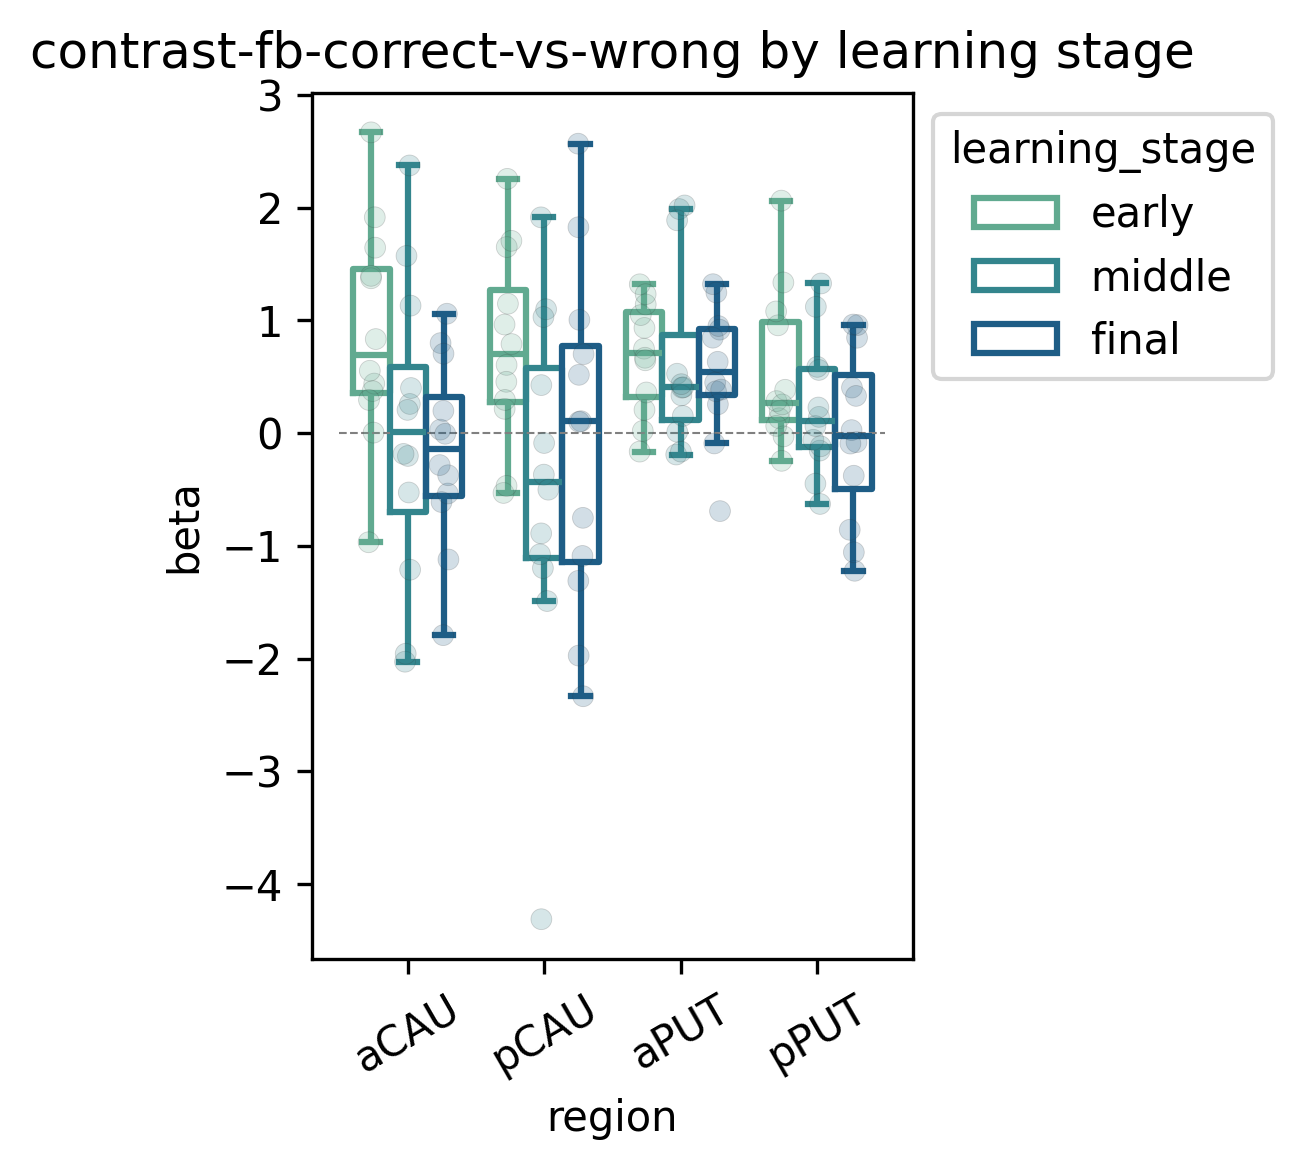

In [133]:
fig, ax = plt.subplots(1, 1, figsize=(4,4), dpi=300)

roi_df_collapsed = roi_df_long.groupby(["participant_id", "region", 'learning_stage'], 
                                       as_index=False).agg({"beta": "mean"})

sns.boxplot(data=roi_df_collapsed, 
              x='region', y='beta', 
              hue='learning_stage', hue_order=['early', 'middle', 'final'],
              order=plot_order,
              palette='crest',
              fliersize = 0,            
              linewidth=1.5,
              fill=False,
              #legend=None,
              ax=ax);
sns.stripplot(data=roi_df_collapsed, 
              x='region', y='beta', 
              hue='learning_stage', hue_order=['early', 'middle', 'final'],
              order=plot_order,
              palette='crest',
              dodge=True,
              linewidth=0.2,
              alpha=.2,
              legend=None,
              ax=ax);


xmin, xmax = ax.get_xlim()
ax.hlines(y=0, xmin=xmin, xmax=xmax, color='0.5', linestyle='--', linewidth=0.5)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_title(f'contrast-{contrast_label} by learning stage');
#ax.set_ylim([-5, 5])

fig.tight_layout()


/scratch/slurm-8704965/ipykernel_4038713/1387005550.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center')


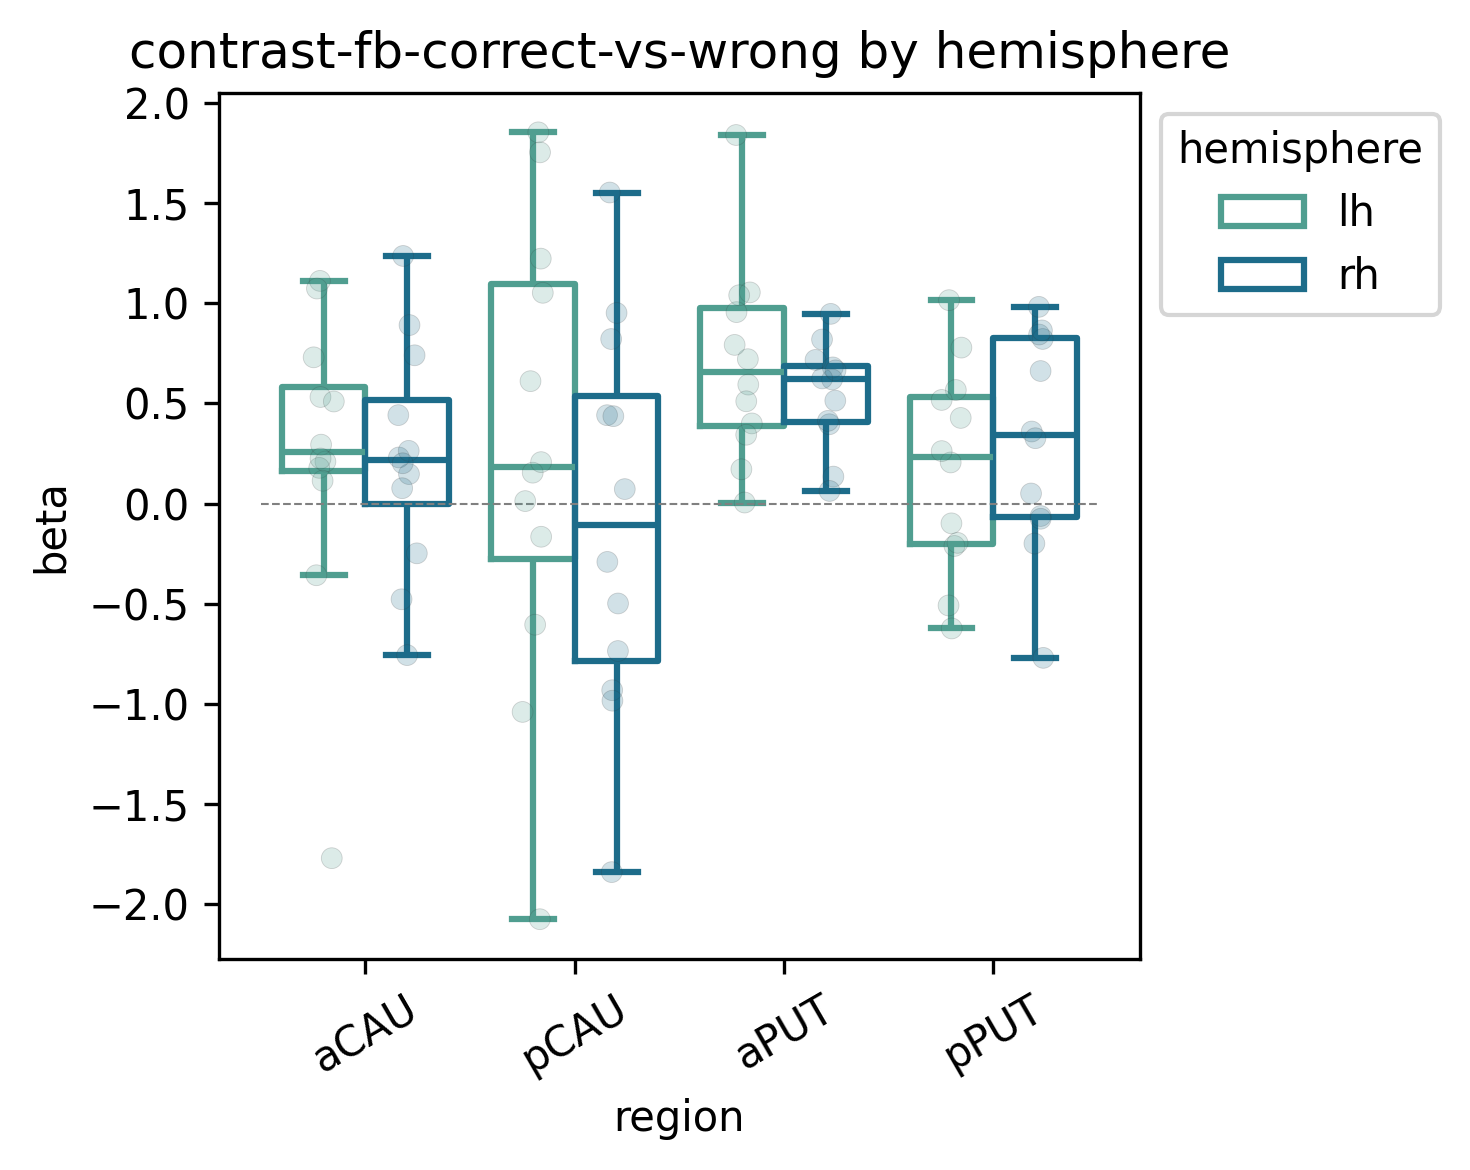

In [134]:
fig, ax = plt.subplots(1, 1, figsize=(5,4), dpi=300)

roi_df_collapsed = roi_df_long.groupby(["participant_id", "region", 'hemisphere'], 
                                       as_index=False).agg({"beta": "mean"})

sns.boxplot(data=roi_df_collapsed, 
              x='region', y='beta', 
              hue='hemisphere', #hue_order=['early', 'middle', 'final'],
              order=plot_order,
              palette='crest',
              fliersize = 0,            
              linewidth=1.5,
              fill=False,
              #legend=None,
              ax=ax);
sns.stripplot(data=roi_df_collapsed, 
              x='region', y='beta', 
              hue='hemisphere', #hue_order=['early', 'middle', 'final'],
              order=plot_order,
              palette='crest',
              dodge=True,
              linewidth=0.2,
              alpha=.2,
              legend=None,
              ax=ax);


xmin, xmax = ax.get_xlim()
ax.hlines(y=0, xmin=xmin, xmax=xmax, color='0.5', linestyle='--', linewidth=0.5)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_title(f'contrast-{contrast_label} by hemisphere');
#ax.set_ylim([-5, 5])

fig.tight_layout()


### Brain-behavior correlations

In [135]:
# map runs to learning stages matching your thirds
stage_map = {'run-01': 'early', 'run-02': 'early',
             'run-03': 'middle', 'run-04': 'middle',
             'run-05': 'final', 'run-06': 'final'}

acc_df['learning_stage'] = acc_df['run'].map(stage_map)
acc_stage_df = acc_df.groupby(['participant_id', 'learning_stage'])['accuracy'].mean().reset_index()

#### Averaged across learning stages

In [136]:
# merge into roi_df_long — assumes participant_id and learning_stage columns exist in both
roi_df_bilateral = (roi_df_long.groupby(['participant_id', 'region'], as_index=False)['beta'].mean())
roi_behav_df = roi_df_bilateral.merge(acc_stage_df, on=['participant_id'])

# verify
roi_behav_df.groupby(['region']).size().unique()  # should be array([12])


array([36])

In [137]:
roi_behav_df.columns

Index(['participant_id', 'region', 'beta', 'learning_stage', 'accuracy'], dtype='object')

In [138]:
roi_behav_df.participant_id.unique()

array(['sub-FLT02', 'sub-FLT04', 'sub-FLT06', 'sub-FLT09', 'sub-FLT11',
       'sub-FLT12', 'sub-FLT13', 'sub-FLT14', 'sub-FLT20', 'sub-FLT25',
       'sub-FLT28', 'sub-FLT30'], dtype=object)

In [139]:
roi_behav_df.groupby(['region','learning_stage']).size().unique()


array([12])

In [140]:
results = []
for roi in roi_behav_df['region'].unique():
    sub_df = roi_behav_df[roi_behav_df['region'] == roi]
    r = pg.corr(sub_df['accuracy'], sub_df['beta'], method='pearson')
    results.append({
        'roi': roi,
        'r': r['r'].values[0],
        'p': r['p-val'].values[0],
        'n': r['n'].values[0],
        'stat_str': stat_str('r', r['r'].values[0], r['p-val'].values[0])
    })

behav_corr_df = pd.DataFrame(results)

In [141]:
behav_corr_df

,roi,r,p,n,stat_str
0,aCAU,-0.4236,0.0100,36,"r = -.42, p = .010"
1,aPUT,0.2942,0.0816,36,"r = .29, p = .082"
2,pCAU,-0.0161,0.9257,36,"r = -.02, p = .926"
3,pPUT,0.1742,0.3095,36,"r = .17, p = .309"


#### Per learning stage

In [142]:
# merge into roi_df_long — assumes participant_id and learning_stage columns exist in both
roi_df_bilateral = (roi_df_long.groupby(['participant_id', 'region', 'learning_stage'], as_index=False)['beta'].mean())
roi_behav_df = roi_df_bilateral.merge(acc_stage_df, on=['participant_id', 'learning_stage'])

# verify
roi_behav_df.groupby(['region', 'learning_stage']).size().unique()  # should be array([12])


array([12])

In [143]:
roi_behav_df.columns

Index(['participant_id', 'region', 'learning_stage', 'beta', 'accuracy'], dtype='object')

In [144]:
roi_behav_df.participant_id.unique()

array(['sub-FLT02', 'sub-FLT04', 'sub-FLT06', 'sub-FLT09', 'sub-FLT11',
       'sub-FLT12', 'sub-FLT13', 'sub-FLT14', 'sub-FLT20', 'sub-FLT25',
       'sub-FLT28', 'sub-FLT30'], dtype=object)

In [145]:
results = []
for stage in ['early', 'middle', 'final']:
    stage_df = roi_behav_df[roi_behav_df['learning_stage'] == stage]
    for roi in stage_df['region'].unique():
        sub_df = stage_df[stage_df['region'] == roi]
        r = pg.corr(sub_df['accuracy'], sub_df['beta'], method='pearson')
        results.append({
            'roi': roi,
            'learning_stage': stage,
            'r': r['r'].values[0],
            'p': r['p-val'].values[0],
            'n': r['n'].values[0],
            'stat_str': stat_str('r', r['r'].values[0], r['p-val'].values[0])
        })

behav_corr_df = pd.DataFrame(results)

In [146]:
behav_corr_df

,roi,learning_stage,r,p,n,stat_str
0,aCAU,early,-0.2432,0.4462,12,"r = -.24, p = .446"
1,aPUT,early,0.2119,0.5086,12,"r = .21, p = .509"
2,pCAU,early,-0.2170,0.4980,12,"r = -.22, p = .498"
3,pPUT,early,0.5669,0.0546,12,"r = .57, p = .055"
4,aCAU,middle,-0.1929,0.5481,12,"r = -.19, p = .548"
5,aPUT,middle,0.2925,0.3563,12,"r = .29, p = .356"
6,pCAU,middle,-0.3483,0.2672,12,"r = -.35, p = .267"
7,pPUT,middle,0.3222,0.3070,12,"r = .32, p = .307"
8,aCAU,final,-0.3103,0.3264,12,"r = -.31, p = .326"
9,aPUT,final,0.2816,0.3752,12,"r = .28, p = .375"


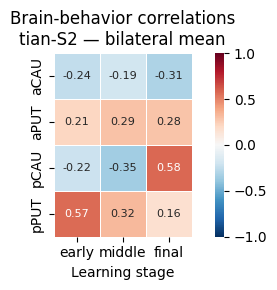

In [147]:
# pivot to ROI × stage matrix
r_matrix = behav_corr_df.pivot(index='roi', columns='learning_stage', values='r')[['early', 'middle', 'final']]
p_matrix = behav_corr_df.pivot(index='roi', columns='learning_stage', values='p')[['early', 'middle', 'final']]

fig, ax = plt.subplots(figsize=(5, len(r_matrix) * 0.5 + 1), dpi=100)
sns.heatmap(r_matrix, ax=ax, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, annot=True, fmt='.2f', annot_kws={'size': 8},
            square=True)

# mark significant cells with an asterisk
for i, roi in enumerate(r_matrix.index):
    for j, stage in enumerate(['early', 'middle', 'final']):
        p = p_matrix.loc[roi, stage]
        if p < 0.05:
            ax.text(j + 0.5, i + 0.85, '*', ha='center', va='center',
                    fontsize=12, color='black')

ax.set_title(f'Brain-behavior correlations\n{network_name} — bilateral mean')
ax.set_ylabel('')
ax.set_xlabel('Learning stage')
plt.tight_layout()

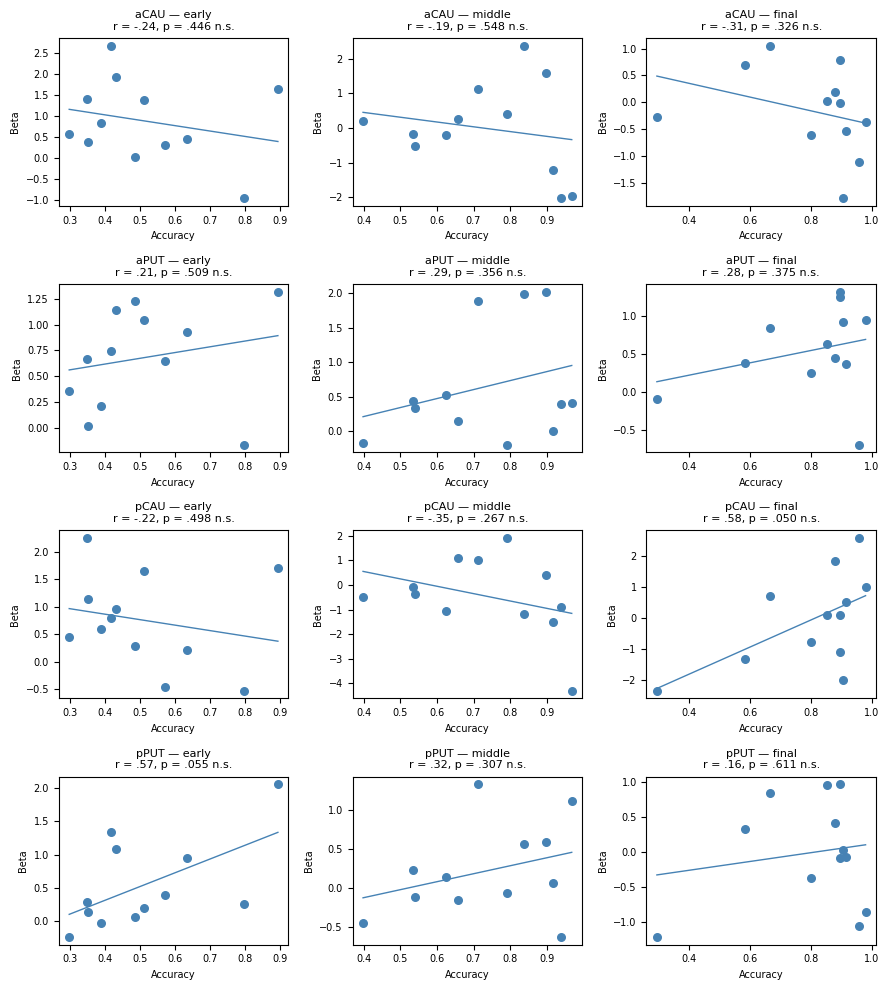

In [148]:
rois = behav_corr_df['roi'].unique()
stages = ['early', 'middle', 'final']

fig, axes = plt.subplots(len(rois), 3, figsize=(9, len(rois) * 2.5), dpi=100, sharex=False, sharey=False)

for ri, roi in enumerate(rois):
    for si, stage in enumerate(stages):
        ax = axes[ri, si]
        sub_df = roi_behav_df[(roi_behav_df['region'] == roi) & 
                              (roi_behav_df['learning_stage'] == stage)]
        
        ax.scatter(sub_df['accuracy'], sub_df['beta'], s=30, color='steelblue', zorder=3)
        
        # regression line
        m, b = np.polyfit(sub_df['accuracy'], sub_df['beta'], 1)
        x_range = np.linspace(sub_df['accuracy'].min(), sub_df['accuracy'].max(), 100)
        ax.plot(x_range, m * x_range + b, color='steelblue', linewidth=1)
        
        # stat annotation
        row = behav_corr_df[(behav_corr_df['roi'] == roi) & 
                            (behav_corr_df['learning_stage'] == stage)].iloc[0]
        p_str = '*' if row['p'] < 0.05 else 'n.s.'
        ax.set_title(f"{roi} — {stage}\n{row['stat_str']} {p_str}", fontsize=8)
        ax.set_xlabel('Accuracy', fontsize=7)
        ax.set_ylabel('Beta', fontsize=7)
        ax.tick_params(labelsize=7)

plt.tight_layout()


aCAU early: r = -.24, p = .446 n.s.
aCAU middle: r = -.19, p = .548 n.s.
aCAU final: r = -.31, p = .326 n.s.
aPUT early: r = .21, p = .509 n.s.
aPUT middle: r = .29, p = .356 n.s.
aPUT final: r = .28, p = .375 n.s.
pCAU early: r = -.22, p = .498 n.s.
pCAU middle: r = -.35, p = .267 n.s.
pCAU final: r = .58, p = .050 n.s.
pPUT early: r = .57, p = .055 n.s.
pPUT middle: r = .32, p = .307 n.s.
pPUT final: r = .16, p = .611 n.s.


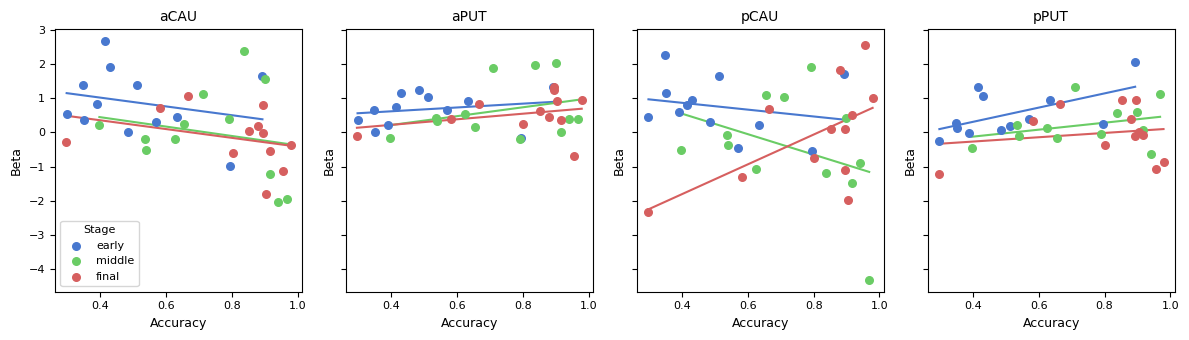

In [149]:
stage_colors = {'early': '#4878CF', 'middle': '#6ACC65', 'final': '#D65F5F'}
stages = ['early', 'middle', 'final']
rois = behav_corr_df['roi'].unique()

fig, axes = plt.subplots(1, len(rois), figsize=(3 * len(rois), 3.5), dpi=100, sharey=True)
if len(rois) == 1:
    axes = [axes]

for ri, roi in enumerate(rois):
    ax = axes[ri]
    for stage in stages:
        color = stage_colors[stage]
        sub_df = roi_behav_df[(roi_behav_df['region'] == roi) &
                              (roi_behav_df['learning_stage'] == stage)]

        ax.scatter(sub_df['accuracy'], sub_df['beta'], s=30,
                   color=color, label=stage, zorder=3)

        m, b = np.polyfit(sub_df['accuracy'], sub_df['beta'], 1)
        x_range = np.linspace(sub_df['accuracy'].min(), sub_df['accuracy'].max(), 100)
        ax.plot(x_range, m * x_range + b, color=color, linewidth=1.5)

        # stat annotation per stage
        row = behav_corr_df[(behav_corr_df['roi'] == roi) &
                            (behav_corr_df['learning_stage'] == stage)].iloc[0]
        p_str = '*' if row['p'] < 0.05 else 'n.s.'
        print(f"{roi} {stage}: {row['stat_str']} {p_str}")

    ax.set_title(roi, fontsize=10)
    ax.set_xlabel('Accuracy', fontsize=9)
    ax.set_ylabel('Beta', fontsize=9)
    ax.tick_params(labelsize=8)

axes[0].legend(title='Stage', fontsize=8, title_fontsize=8)
plt.tight_layout()


### omnibus ANOVA stats

In [150]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import AnovaRM
import pingouin as pg

In [151]:
non_mandarin_df.head()

,participant_id,participant_group,region,beta,region_hemi,hemisphere,learning_stage,Axis
0,sub-FLT02,non-Mandarin,aCAU,0.4978,aCAU-lh,lh,early,Rostral
1,sub-FLT04,non-Mandarin,aCAU,2.5278,aCAU-lh,lh,early,Rostral
2,sub-FLT06,non-Mandarin,aCAU,0.4776,aCAU-lh,lh,early,Rostral
3,sub-FLT09,non-Mandarin,aCAU,1.5577,aCAU-lh,lh,early,Rostral
4,sub-FLT11,non-Mandarin,aCAU,1.1857,aCAU-lh,lh,early,Rostral


In [152]:
non_mandarin_df.participant_id.unique()

array(['sub-FLT02', 'sub-FLT04', 'sub-FLT06', 'sub-FLT09', 'sub-FLT11',
       'sub-FLT12', 'sub-FLT13', 'sub-FLT14', 'sub-FLT20', 'sub-FLT25',
       'sub-FLT28', 'sub-FLT30'], dtype=object)

In [153]:
# Mixed-Effects ANOVA with Hemisphere, Region, and Interaction
aov = AnovaRM(non_mandarin_df, 
              aggregate_func='mean',
              depvar='beta', 
              subject='participant_id', 
              within=['hemisphere', 'learning_stage','region', ]).fit()

# Display results
print('network:', network_name)
print('contrast:', contrast_label)
aov.summary()

network: tian-S2
contrast: fb-correct-vs-wrong


/bgfs/bchandrasekaran/krs228/software/miniconda3/envs/py3/lib/python3.9/site-packages/statsmodels/iolib/summary2.py:579: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  dat = dat.applymap(lambda x: _formatter(x, float_format))


,F Value,Num DF,Den DF,Pr > F
hemisphere,1.0419,1.0000,11.0000,0.3293
learning_stage,4.0458,2.0000,22.0000,0.0319
region,1.7955,3.0000,33.0000,0.1672
hemisphere:learning_stage,0.1990,2.0000,22.0000,0.8210
hemisphere:region,2.2317,3.0000,33.0000,0.1029
learning_stage:region,1.9652,6.0000,66.0000,0.0833
hemisphere:learning_stage:region,0.4861,6.0000,66.0000,0.8164


In [154]:
export_anova(aov, f'{contrast_label}_{network_name}_hemisphere_learning-stage_region', stats_out_dir)

,source,F,df_num,df_den,p,stat_str
0,hemisphere,1.0419,1.0000,11.0000,0.3293,"F(1, 11) = 1.04, p = .329"
1,learning_stage,4.0458,2.0000,22.0000,0.0319,"F(2, 22) = 4.05, p = .032"
2,region,1.7955,3.0000,33.0000,0.1672,"F(3, 33) = 1.80, p = .167"
3,hemisphere:learning_stage,0.1990,2.0000,22.0000,0.8210,"F(2, 22) = 0.20, p = .821"
4,hemisphere:region,2.2317,3.0000,33.0000,0.1029,"F(3, 33) = 2.23, p = .103"
5,learning_stage:region,1.9652,6.0000,66.0000,0.0833,"F(6, 66) = 1.97, p = .083"
6,hemisphere:learning_stage:region,0.4861,6.0000,66.0000,0.8164,"F(6, 66) = 0.49, p = .816"


In [155]:
import pingouin as pg

# Pairwise comparisons for region with FDR correction
pairwise_by_learning_stage = pg.pairwise_tests(data=non_mandarin_df,
                             dv='beta', 
                             within=['learning_stage','region', ],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise_by_learning_stage.columns)

# Display key columns (without 'effsize' and 'CIs' if missing)
print("\nPost-hoc Pairwise Comparisons:")
#print(pairwise_by_learning_stage)
#pairwise_by_learning_stage[['Contrast', 'learning_stage', 'A', 'B', 'T', 'dof', 'p-unc', 'p-corr', 'BF10']]  # Keep only available columns

pd.set_option('display.max_rows', None)

pairwise_interaction = pairwise_by_learning_stage[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()
pairwise_interaction[['Contrast', 'learning_stage', 'A', 'B', 'T', 'dof', 'p-unc', 'p-corr', 'BF10']]

Available columns: Index(['Contrast', 'learning_stage', 'A', 'B', 'Paired', 'Parametric', 'T',
       'dof', 'alternative', 'p-unc', 'p-corr', 'p-adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,learning_stage,A,B,T,dof,p-unc,p-corr,BF10
0,learning_stage * region,final,aCAU,aPUT,-3.0072,11.0000,0.0119,0.1073,5.132
1,learning_stage * region,final,aPUT,pPUT,3.1130,11.0000,0.0099,0.1073,5.98
2,learning_stage * region,middle,aCAU,aPUT,-2.3284,11.0000,0.0400,0.1799,1.969
3,learning_stage * region,middle,aPUT,pPUT,2.3902,11.0000,0.0359,0.1799,2.143


In [156]:
# pairwise by region

# Pairwise comparisons for region with FDR correction
pairwise_by_region = pg.pairwise_tests(data=non_mandarin_df,
                             dv='beta', 
                             within=['region', 'learning_stage',],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise_by_region.columns)

# Display key columns (without 'effsize' and 'CIs' if missing)
print("\nPost-hoc Pairwise Comparisons:")
#print(pairwise_by_region)
#pairwise_by_region[['Contrast', 'learning_stage', 'A', 'B', 'T', 'dof', 'p-unc', 'p-corr', 'BF10']]  # Keep only available columns

pd.set_option('display.max_rows', None)

pairwise_interaction = pairwise_by_region[pairwise_by_region.Contrast.str.contains(' * ')].reset_index()
pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05]
pairwise_interaction[['Contrast', 'region', 'A', 'B', 'T', 'dof', 'p-unc', 'p-corr', 'BF10']]

Available columns: Index(['Contrast', 'region', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof',
       'alternative', 'p-unc', 'p-corr', 'p-adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,region,A,B,T,dof,p-unc,p-corr,BF10
0,region * learning_stage,aCAU,early,final,4.0314,11.0000,0.0020,0.0237,22.564
7,region * learning_stage,pCAU,early,middle,3.3230,11.0000,0.0068,0.0408,8.109
9,region * learning_stage,pPUT,early,final,2.3355,11.0000,0.0395,0.1579,1.988


In [157]:
export_posthoc(pairwise_by_region, f'{contrast_label}_{network_name}_region_learning-stage', stats_out_dir)

,Contrast,region,A,B,t,df,p,p_fdr,stat_str,p_fdr_str
0,region,-,aCAU,aPUT,-2.1681,11.0000,0.0530,0.1589,"t(11) = -2.17, p = .053",p = .159
1,region,-,aCAU,pCAU,0.5595,11.0000,0.5871,0.7565,"t(11) = 0.56, p = .587",p = .756
2,region,-,aCAU,pPUT,-0.0784,11.0000,0.9390,0.9390,"t(11) = -0.08, p = .939",p = .939
3,region,-,aPUT,pCAU,1.7635,11.0000,0.1055,0.2111,"t(11) = 1.76, p = .106",p = .211
4,region,-,aPUT,pPUT,3.2883,11.0000,0.0072,0.0434,"t(11) = 3.29, p = .007",p = .043
5,region,-,pCAU,pPUT,-0.4949,11.0000,0.6304,0.7565,"t(11) = -0.49, p = .630",p = .756
6,learning_stage,-,early,final,3.0173,11.0000,0.0117,0.0351,"t(11) = 3.02, p = .012",p = .035
7,learning_stage,-,early,middle,2.4241,11.0000,0.0338,0.0506,"t(11) = 2.42, p = .034",p = .051
8,learning_stage,-,final,middle,-0.0682,11.0000,0.9468,0.9468,"t(11) = -0.07, p = .947",p = .947
9,region * learning_stage,aCAU,early,final,4.0314,11.0000,0.0020,0.0237,"t(11) = 4.03, p = .002",p = .024


In [158]:
# pairwise by region, no learning stage

# Pairwise comparisons for region with FDR correction
pairwise_by_region_only = pg.pairwise_tests(data=non_mandarin_df,
                             dv='beta', 
                             within=['region', ],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise_by_region_only.columns)

# Display key columns (without 'effsize' and 'CIs' if missing)
print("\nPost-hoc Pairwise Comparisons:")
#print(pairwise_by_region_only)
pairwise_by_region_only = pairwise_by_region_only[pairwise_by_region_only['p-unc'] < 0.05]
pairwise_by_region_only[['Contrast', 'Contrast', 'A', 'B', 'T', 'dof', 'p-unc', 'p-corr', 'BF10']]  # Keep only available columns


Available columns: Index(['Contrast', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof', 'alternative',
       'p-unc', 'p-corr', 'p-adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Contrast,A,B,T,dof,p-unc,p-corr,BF10
4,region,region,aPUT,pPUT,3.2883,11.0000,0.0072,0.0434,7.71


In [159]:
export_posthoc(pairwise_by_region_only, f'{contrast_label}_{network_name}_region', stats_out_dir)

,Contrast,A,B,t,df,p,p_fdr,stat_str,p_fdr_str
4,region,aPUT,pPUT,3.2883,11.0000,0.0072,0.0434,"t(11) = 3.29, p = .007",p = .043


#### Collapse (average) over non-significant factors

In [160]:
roi_df_collapsed = roi_df_long.groupby(["participant_id", "region", 'learning_stage'], 
                                       as_index=False).agg({"beta": "mean"})


In [161]:
# Collect results
results = []

for region, data in roi_df_collapsed.groupby("region"):
    t_stat, p_val = ttest_1samp(data["beta"], 0)
    results.append({
        "region": region,
        "t_stat": t_stat,
        "p_val": p_val
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Apply FDR correction
results_df["p_val_fdr"] = multipletests(results_df["p_val"], method="fdr_bh")[1]

# Print or export the table
results_df

# Optional: export
# results_df.to_csv("roi_stats.csv", index=False)
# results_df.to_excel("roi_stats.xlsx", index=False)


,region,t_stat,p_val,p_val_fdr
0,aCAU,1.2372,0.2242,0.2990
1,aPUT,5.9806,0.0000,0.0000
2,pCAU,0.3501,0.7283,0.7283
3,pPUT,2.1282,0.0404,0.0809


In [162]:
_export = results_df.rename(columns={'t_stat': 't', 'p_val': 'p'}).copy()
_export['df'] = len(sub_list_nman) - 1
export_ttests(_export.to_dict('records'), f'{contrast_label}_{network_name}_baseline_by_region', stats_out_dir)

,region,t,p,p_val_fdr,df,p_fdr,stat_str,p_fdr_str
0,aCAU,1.2372,0.2242,0.2990,11,0.2990,"t(11) = 1.24, p = .224",p = .299
1,aPUT,5.9806,0.0000,0.0000,11,0.0000,"t(11) = 5.98, p < .001",p < .001
2,pCAU,0.3501,0.7283,0.7283,11,0.7283,"t(11) = 0.35, p = .728",p = .728
3,pPUT,2.1282,0.0404,0.0809,11,0.0809,"t(11) = 2.13, p = .040",p = .081


In [163]:
# Collect results
results = []

for (region, stage), data in roi_df_collapsed.groupby(["region", "learning_stage"]):
    t_stat, p_val = ttest_1samp(data["beta"], 0)
    results.append({
        "region": region,
        "learning_stage": stage,
        "t_stat": t_stat,
        "p_val": p_val
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Apply FDR correction
results_df["p_val_fdr"] = multipletests(results_df["p_val"], method="fdr_bh")[1]

stage_order = ["early", "middle", "final"]

results_df["learning_stage"] = pd.Categorical(
    results_df["learning_stage"],
    categories=stage_order,
    ordered=True
)

# Now sort
results_df = results_df.sort_values(["learning_stage", "region"])


# Print or export the table
results_df

# Optional: export
# results_df.to_csv("roi_stats.csv", index=False)
# results_df.to_excel("roi_stats.xlsx", index=False)


,region,learning_stage,t_stat,p_val,p_val_fdr
0,aCAU,early,3.1153,0.0098,0.0310
3,aPUT,early,4.8329,0.0005,0.0063
6,pCAU,early,3.0868,0.0103,0.0310
9,pPUT,early,2.7588,0.0186,0.0394
2,aCAU,middle,-0.0387,0.9698,0.9698
5,aPUT,middle,2.7268,0.0197,0.0394
8,pCAU,middle,-0.9841,0.3462,0.5193
11,pPUT,middle,1.2799,0.2269,0.3890
1,aCAU,final,-0.6867,0.5065,0.6753
4,aPUT,final,3.3307,0.0067,0.0310


In [164]:
_export = results_df.rename(columns={'t_stat': 't', 'p_val': 'p'}).copy()
_export['df'] = len(sub_list_nman) - 1
export_ttests(_export.to_dict('records'), f'{contrast_label}_{network_name}_baseline_by_region_stage', stats_out_dir)

,region,learning_stage,t,p,p_val_fdr,df,p_fdr,stat_str,p_fdr_str
0,aCAU,early,3.1153,0.0098,0.0310,11,0.0310,"t(11) = 3.12, p = .010",p = .031
1,aPUT,early,4.8329,0.0005,0.0063,11,0.0063,"t(11) = 4.83, p < .001",p = .006
2,pCAU,early,3.0868,0.0103,0.0310,11,0.0310,"t(11) = 3.09, p = .010",p = .031
3,pPUT,early,2.7588,0.0186,0.0394,11,0.0394,"t(11) = 2.76, p = .019",p = .039
4,aCAU,middle,-0.0387,0.9698,0.9698,11,0.9698,"t(11) = -0.04, p = .970",p = .970
5,aPUT,middle,2.7268,0.0197,0.0394,11,0.0394,"t(11) = 2.73, p = .020",p = .039
6,pCAU,middle,-0.9841,0.3462,0.5193,11,0.5193,"t(11) = -0.98, p = .346",p = .519
7,pPUT,middle,1.2799,0.2269,0.3890,11,0.3890,"t(11) = 1.28, p = .227",p = .389
8,aCAU,final,-0.6867,0.5065,0.6753,11,0.6753,"t(11) = -0.69, p = .506",p = .675
9,aPUT,final,3.3307,0.0067,0.0310,11,0.0310,"t(11) = 3.33, p = .007",p = .031


In [165]:
from statsmodels.stats.multitest import multipletests
from scipy.stats import ttest_1samp


# Collect p-values
p_values = []
t_stats = []
comparisons = []

for region_stage, data in roi_df_collapsed.groupby(['learning_stage', "region",]):
    #print(region_stage)
    t_stat, p_val = ttest_1samp(data["beta"], 0)
    p_values.append(p_val)
    comparisons.append((region_stage[0], region_stage[1], t_stat))
    t_stats.append(t_stat)

# Apply FDR correction
_, p_corrected, _, _ = multipletests(p_values, method='fdr_bh')

# Print corrected results
for (region, stage, t_stat), p_val_corr in zip(comparisons, p_corrected):
    print(f"Region: {region}, stage: {stage}, t = {t_stat:.2f}; corrected p = {p_val_corr:.4f}")


Region: early, stage: aCAU, t = 3.12; corrected p = 0.0310
Region: early, stage: aPUT, t = 4.83; corrected p = 0.0063
Region: early, stage: pCAU, t = 3.09; corrected p = 0.0310
Region: early, stage: pPUT, t = 2.76; corrected p = 0.0394
Region: final, stage: aCAU, t = -0.69; corrected p = 0.6753
Region: final, stage: aPUT, t = 3.33; corrected p = 0.0310
Region: final, stage: pCAU, t = -0.13; corrected p = 0.9698
Region: final, stage: pPUT, t = -0.06; corrected p = 0.9698
Region: middle, stage: aCAU, t = -0.04; corrected p = 0.9698
Region: middle, stage: aPUT, t = 2.73; corrected p = 0.0394
Region: middle, stage: pCAU, t = -0.98; corrected p = 0.5193
Region: middle, stage: pPUT, t = 1.28; corrected p = 0.3890


In [166]:
# Compare early vs. final
results = []

for region, data in roi_df_collapsed.groupby("region"):

    # Extract paired early/final beta values
    early = data.loc[data.learning_stage == "early", "beta"].values
    final = data.loc[data.learning_stage == "final", "beta"].values
    
    t_stat, p_val = ttest_rel(final, early)
    results.append({
        "region": region,
        "t_stat": t_stat,
        "p_val": p_val
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Apply FDR correction
results_df["p_val_fdr"] = multipletests(results_df["p_val"], method="fdr_bh")[1]

stage_order = ["early", "middle", "final"]

'''
results_df["learning_stage"] = pd.Categorical(
    results_df["learning_stage"],
    categories=stage_order,
    ordered=True
)
'''

# Now sort
results_df = results_df.sort_values(["region"])


# Print or export the table
results_df

# Optional: export
# results_df.to_csv("roi_stats.csv", index=False)
# results_df.to_excel("roi_stats.xlsx", index=False)


,region,t_stat,p_val,p_val_fdr
0,aCAU,-4.0314,0.0020,0.0079
1,aPUT,-0.5003,0.6267,0.6267
2,pCAU,-1.8079,0.0980,0.1307
3,pPUT,-2.3355,0.0395,0.0790


In [167]:
_export = results_df.rename(columns={'t_stat': 't', 'p_val': 'p'}).copy()
_export['df'] = len(sub_list_nman) - 1
export_ttests(_export.to_dict('records'), f'{contrast_label}_{network_name}_early_vs_final', stats_out_dir)

,region,t,p,p_val_fdr,df,p_fdr,stat_str,p_fdr_str
0,aCAU,-4.0314,0.0020,0.0079,11,0.0079,"t(11) = -4.03, p = .002",p = .008
1,aPUT,-0.5003,0.6267,0.6267,11,0.6267,"t(11) = -0.50, p = .627",p = .627
2,pCAU,-1.8079,0.0980,0.1307,11,0.1307,"t(11) = -1.81, p = .098",p = .131
3,pPUT,-2.3355,0.0395,0.0790,11,0.0790,"t(11) = -2.34, p = .039",p = .079


In [168]:
# Compare early vs. final
roi_df_collapsed = roi_df_long.groupby(["participant_id", "region", 'learning_stage'], 
                                       as_index=False).agg({"beta": "mean"})

# Collect p-values
p_values = []
t_stats = []
comparisons = []

for region_stage, data in roi_df_collapsed.groupby(["region"]):
    t_stat, p_val = ttest_rel(data[data.learning_stage=='final']['beta'], 
                              data[data.learning_stage=='early']['beta'])
    p_values.append(p_val)
    comparisons.append((region_stage[0], t_stat))
    t_stats.append(t_stat)

# Apply FDR correction
_, p_corrected, _, _ = multipletests(p_values, method='fdr_bh')

# Print corrected results
for (region, t_stat), p_val_corr in zip(comparisons, p_corrected):
    print(f"Region: {region}, final vs. early stage, t = {t_stat:.2f} ; corrected p = {p_val_corr:.4f}")



Region: aCAU, final vs. early stage, t = -4.03 ; corrected p = 0.0079
Region: aPUT, final vs. early stage, t = -0.50 ; corrected p = 0.6267
Region: pCAU, final vs. early stage, t = -1.81 ; corrected p = 0.1307
Region: pPUT, final vs. early stage, t = -2.34 ; corrected p = 0.0790


In [169]:
_records = [{'region': c[0], 't': c[1], 'df': len(sub_list_nman) - 1, 'p': p}
            for c, p in zip(comparisons, p_values)]
export_ttests(_records, f'{contrast_label}_{network_name}_early_vs_final', stats_out_dir)

,region,t,df,p,p_fdr,stat_str,p_fdr_str
0,aCAU,-4.0314,11,0.0020,0.0079,"t(11) = -4.03, p = .002",p = .008
1,aPUT,-0.5003,11,0.6267,0.6267,"t(11) = -0.50, p = .627",p = .627
2,pCAU,-1.8079,11,0.0980,0.1307,"t(11) = -1.81, p = .098",p = .131
3,pPUT,-2.3355,11,0.0395,0.0790,"t(11) = -2.34, p = .039",p = .079


In [170]:
# Collapse/ignore learning stage
roi_df_collapsed_stage = roi_df_long.groupby(["participant_id", "region"], 
                                       as_index=False).agg({"beta": "mean"})

# Collect p-values
p_values = []
t_stats = []
comparisons = []

for region, data in roi_df_collapsed_stage.groupby(["region"]):
    t_stat, p_val = ttest_1samp(data["beta"], 0)
    p_values.append(p_val)
    comparisons.append((region[0], t_stat))
    t_stats.append(t_stat)

# Apply FDR correction
_, p_corrected, _, _ = multipletests(p_values, method='fdr_bh')

# Print corrected results
for (region, t_stat), p_val_corr in zip(comparisons, p_corrected):
    print(f"Region: {region}, t = {t_stat:.2f}; corrected p = {p_val_corr:.4f}")


Region: aCAU, t = 1.30; corrected p = 0.2955
Region: aPUT, t = 6.42; corrected p = 0.0002
Region: pCAU, t = 0.28; corrected p = 0.7813
Region: pPUT, t = 1.72; corrected p = 0.2253


In [171]:
_records = [{'region': c[0], 't': c[1], 'df': len(sub_list_nman) - 1, 'p': p}
            for c, p in zip(comparisons, p_values)]
export_ttests(_records, f'{contrast_label}_{network_name}_baseline_collapsed', stats_out_dir)

,region,t,df,p,p_fdr,stat_str,p_fdr_str
0,aCAU,1.2957,11,0.2216,0.2955,"t(11) = 1.30, p = .222",p = .295
1,aPUT,6.4224,11,0.0000,0.0002,"t(11) = 6.42, p < .001",p < .001
2,pCAU,0.2845,11,0.7813,0.7813,"t(11) = 0.28, p = .781",p = .781
3,pPUT,1.7241,11,0.1126,0.2253,"t(11) = 1.72, p = .113",p = .225


### Make 3D plots

In [51]:
roi_df_collapsed = roi_df_long.groupby(["participant_id", "region_hemi"], 
                                       as_index=False).agg({"beta": "mean"})

# Collect p-values
p_values = []
t_stats = []
comparisons = []

for region, data in roi_df_collapsed.groupby(["region_hemi"]):
    t_stat, p_val = ttest_1samp(data["beta"], 0)
    p_values.append(p_val)
    comparisons.append((region[0], t_stat))
    t_stats.append(t_stat)

# Apply FDR correction
_, p_corrected, _, _ = multipletests(p_values, method='fdr_bh')

# Print corrected results
for (region, t_stat), p_val_corr in zip(comparisons, p_corrected):
    print(f"Region: {region}, t = {t_stat:.2f}; corrected p = {p_val_corr:.4f}")


Region: aCAU-lh, t = 1.09; corrected p = 0.3989
Region: aCAU-rh, t = 1.41; corrected p = 0.3738
Region: aPUT-lh, t = 4.97; corrected p = 0.0017
Region: aPUT-rh, t = 7.28; corrected p = 0.0001
Region: pCAU-lh, t = 0.75; corrected p = 0.5377
Region: pCAU-rh, t = -0.30; corrected p = 0.7710
Region: pPUT-lh, t = 1.20; corrected p = 0.3989
Region: pPUT-rh, t = 2.03; corrected p = 0.1788


In [52]:
region_list = region_dict[network_name]

mask_dict = dict(zip(mask_path_list, 
                     range(1,len(mask_path_list)+1)))

stat_dict = dict(zip(range(1,len(t_stats)+1), 
                     t_stats))

from matplotlib import cm

# Load NIfTI files into a list
nifti_files = mask_path_list

# Define a colormap
colormap = cm.get_cmap('coolwarm')

# Define the list of values for color plotting
color_values = t_stats  # Adjust these values as needed

/scratch/slurm-7031981/ipykernel_3094060/2094431203.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('coolwarm')


In [ ]:
import plotly.graph_objs as go
from plotly.subplots import make_subplots
from matplotlib import cm
from skimage import measure
from scipy.ndimage import gaussian_filter
from IPython.display import clear_output

# Load NIfTI files into a list
nifti_files = mask_path_list

# Define a colormap
colormap = cm.get_cmap('Reds') # 'coolwarm', 'Reds'

# Define the list of values for color plotting
color_values = t_stats  # Adjust these values as needed

# Create a list to hold the data for each segmentation
segmentations = []

# Loop through each NIfTI file and extract segmentation data
for nifti_file in nifti_files:
    nifti_data = nib.load(nifti_file)
    segmentation = nifti_data.get_fdata()
    segmentations.append(segmentation)

# Combine all segmentations into a single binary mask
combined_segmentation = np.any(segmentations, axis=0)

# Upsample the voxel data to a higher resolution grid
upsampled_segmentation = np.repeat(np.repeat(np.repeat(combined_segmentation, 2, axis=0), 2, axis=1), 2, axis=2)

# Smooth the upsampled voxel data with a Gaussian filter
smoothed_segmentation = gaussian_filter(upsampled_segmentation, sigma=1)

# Extract the surface mesh of the smoothed segmented region with adjusted level
vertices, faces, _, _ = measure.marching_cubes(smoothed_segmentation, level=smoothed_segmentation.mean())

# Translate vertices closer to the origin
center = vertices.mean(axis=0)
vertices -= center

# Create a subplot for the 3D plot with a larger size
fig = make_subplots(rows=1, cols=1, specs=[[{'type': 'mesh3d'}]], print_grid=False)

# Loop through each segmentation and add its surface plot to the subplot
for i, segmentation in enumerate(segmentations):
    # Upsample the voxel data to a higher resolution grid
    upsampled_segmentation = np.repeat(np.repeat(np.repeat(segmentation, 2, axis=0), 2, axis=1), 2, axis=2)
    
    # Smooth the upsampled voxel data with a Gaussian filter
    smoothed_segmentation = gaussian_filter(upsampled_segmentation, sigma=1)
    
    # Extract the surface mesh of the smoothed segmented region with adjusted level
    vertices, faces, _, _ = measure.marching_cubes(smoothed_segmentation, level=smoothed_segmentation.mean())
    
    vertices -= center
    
    # Map the color value to the colormap
    colormap_value = (color_values[i] - min(color_values)) / (max(color_values) - min(color_values))
    color = colormap(colormap_value)
    
    # Add the surface plot to the subplot
    fig.add_trace(go.Mesh3d(
        x=vertices[:, 0],
        y=vertices[:, 1],
        z=vertices[:, 2],
        i=faces[:, 0],
        j=faces[:, 1],
        k=faces[:, 2],
        color=f'rgb({int(color[0]*255)}, {int(color[1]*255)}, {int(color[2]*255)})',
        opacity=1,
        name= region_list[i] # f'Segmentation {i+1}'
    ))

# Set starting camera angle
camera = dict(
    up=dict(x=0, y=0, z=1),
    center=dict(x=0, y=0, z=0),
    eye=dict(x=-1.25, y=1.25, z=1.25)
)

# Update layout for the 3D plot to set a larger size and transparent background
fig.update_layout(
    scene=dict(
        xaxis=dict(title=None, showbackground=False, linecolor='rgba(0,0,0,0)', 
                   showgrid=False, showticklabels=False),
        yaxis=dict(title=None, showbackground=False, linecolor='rgba(0,0,0,0)', 
                   showgrid=False, showticklabels=False),
        zaxis=dict(title=None, showbackground=False, linecolor='rgba(0,0,0,0)', 
                   showgrid=False, showticklabels=False),
        bgcolor='rgba(0,0,0,0)',  # Set background color to transparent
        camera=camera  # Set starting camera angle
    ),
    #title=f'All participants contrast-{contrast_label}',
    width=800,  # Set width of the plot
    height=600,  # Set height of the plot
)

# Show the interactive plot
fig.show()

# Save the interactive plot as an SVG file
fig.write_image(f'out-figure_group-all_contrast-{contrast_label}_network-{network_name}_revision_surface.svg')
clear_output() # very large – clear it after using

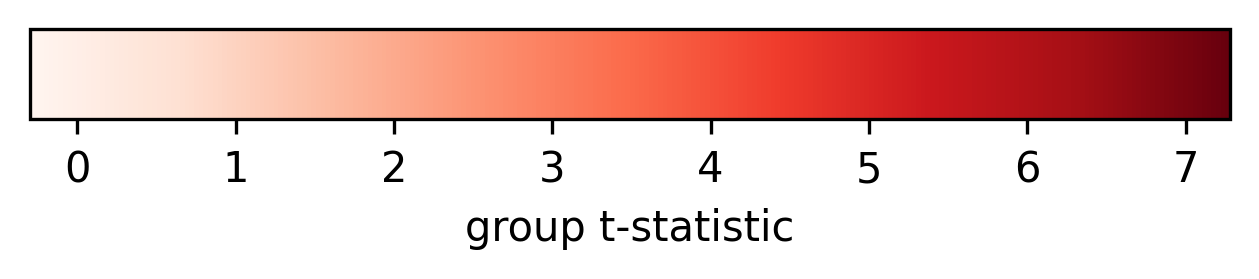

In [54]:
a = np.array([[min(color_values), max(color_values)]])
plt.figure(figsize=(5, 0.5), dpi=300)
img = plt.imshow(a, cmap=colormap)
plt.gca().set_visible(False)
cax = plt.axes([0.1, 0.2, 0.8, 0.6])
#cbar = plt.colorbar(orientation="horizontal", cax=cax, label='group t-statistic')
plt.colorbar(orientation="horizontal", cax=cax, label='group t-statistic')
#cbar.ax.get_yaxis().labelpad = 15
plt.savefig(f"out-figure_group-all_contrast-{contrast_label}_network-{network_name}_revision_colorbar.svg")

### Make 3D plots - early - final runs

In [55]:
p_values

[0.2991608512447118,
 0.1868817754213744,
 0.0004251441399476051,
 1.5827332754144564e-05,
 0.4704724871352012,
 0.7709751656980375,
 0.25349815469018444,
 0.06705254586128652]

In [56]:
from scipy.stats import ttest_rel

roi_df_collapsed = roi_df_long.groupby(["participant_id", "region_hemi", 'learning_stage'], 
                                       as_index=False).agg({"beta": "mean"})

# Collect p-values
p_values = []
t_stats = []
comparisons = []

for region_stage, data in roi_df_collapsed.groupby(["region_hemi"]):
    t_stat, p_val = ttest_rel(data[data.learning_stage=='final']['beta'], 
                              data[data.learning_stage=='early']['beta'])
    p_values.append(p_val)
    comparisons.append((region_stage[0], t_stat))
    t_stats.append(t_stat)

# Apply FDR correction
_, p_corrected, _, _ = multipletests(p_values, method='fdr_bh')

# Print corrected results
for (region, t_stat), p_val_corr in zip(comparisons, p_corrected):
    print(f"Region: {region}, final vs. early stage, t = {t_stat:.2f}; corrected p = {p_val_corr:.4f}")



Region: aCAU-lh, final vs. early stage, t = -3.67; corrected p = 0.0147
Region: aCAU-rh, final vs. early stage, t = -3.82; corrected p = 0.0147
Region: aPUT-lh, final vs. early stage, t = -0.91; corrected p = 0.4344
Region: aPUT-rh, final vs. early stage, t = 0.08; corrected p = 0.9347
Region: pCAU-lh, final vs. early stage, t = -1.74; corrected p = 0.1753
Region: pCAU-rh, final vs. early stage, t = -1.53; corrected p = 0.2067
Region: pPUT-lh, final vs. early stage, t = -2.04; corrected p = 0.1330
Region: pPUT-rh, final vs. early stage, t = -2.42; corrected p = 0.0906


In [57]:
region_list = region_dict[network_name]

mask_dict = dict(zip(mask_path_list, 
                     range(1,len(mask_path_list)+1)))

stat_dict = dict(zip(range(1,len(t_stats)+1), 
                     t_stats))

from matplotlib import cm

# Load NIfTI files into a list
nifti_files = mask_path_list

# Define a colormap
colormap = cm.get_cmap('coolwarm')

# Define the list of values for color plotting
color_values = t_stats  # Adjust these values as needed

/scratch/slurm-7031981/ipykernel_3094060/2094431203.py:15: MatplotlibDeprecationWarning:

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.



In [134]:
import plotly.graph_objs as go
from plotly.subplots import make_subplots
from matplotlib import cm
from skimage import measure
from scipy.ndimage import gaussian_filter
from IPython.display import clear_output

# Load NIfTI files into a list
nifti_files = mask_path_list

# Define a colormap
colormap = cm.get_cmap('Blues_r') # 'coolwarm', 'Reds'

# Define the list of values for color plotting
color_values = t_stats  # Adjust these values as needed

# Create a list to hold the data for each segmentation
segmentations = []

# Loop through each NIfTI file and extract segmentation data
for nifti_file in nifti_files:
    nifti_data = nib.load(nifti_file)
    segmentation = nifti_data.get_fdata()
    segmentations.append(segmentation)

# Combine all segmentations into a single binary mask
combined_segmentation = np.any(segmentations, axis=0)

# Upsample the voxel data to a higher resolution grid
upsampled_segmentation = np.repeat(np.repeat(np.repeat(combined_segmentation, 2, axis=0), 2, axis=1), 2, axis=2)

# Smooth the upsampled voxel data with a Gaussian filter
smoothed_segmentation = gaussian_filter(upsampled_segmentation, sigma=1)

# Extract the surface mesh of the smoothed segmented region with adjusted level
vertices, faces, _, _ = measure.marching_cubes(smoothed_segmentation, level=smoothed_segmentation.mean())

# Translate vertices closer to the origin
center = vertices.mean(axis=0)
vertices -= center

# Create a subplot for the 3D plot with a larger size
fig = make_subplots(rows=1, cols=1, specs=[[{'type': 'mesh3d'}]], print_grid=False)

# Loop through each segmentation and add its surface plot to the subplot
for i, segmentation in enumerate(segmentations):
    # Upsample the voxel data to a higher resolution grid
    upsampled_segmentation = np.repeat(np.repeat(np.repeat(segmentation, 2, axis=0), 2, axis=1), 2, axis=2)
    
    # Smooth the upsampled voxel data with a Gaussian filter
    smoothed_segmentation = gaussian_filter(upsampled_segmentation, sigma=1)
    
    # Extract the surface mesh of the smoothed segmented region with adjusted level
    vertices, faces, _, _ = measure.marching_cubes(smoothed_segmentation, level=smoothed_segmentation.mean())
    
    vertices -= center
    
    # Map the color value to the colormap
    colormap_value = (color_values[i] - min(color_values)) / (max(color_values) - min(color_values))
    color = colormap(colormap_value)
    
    # Add the surface plot to the subplot
    fig.add_trace(go.Mesh3d(
        x=vertices[:, 0],
        y=vertices[:, 1],
        z=vertices[:, 2],
        i=faces[:, 0],
        j=faces[:, 1],
        k=faces[:, 2],
        color=f'rgb({int(color[0]*255)}, {int(color[1]*255)}, {int(color[2]*255)})',
        opacity=1,
        name= region_list[i] # f'Segmentation {i+1}'
    ))

# Set starting camera angle
camera = dict(
    up=dict(x=0, y=0, z=1),
    center=dict(x=0, y=0, z=0),
    eye=dict(x=-1.25, y=1.25, z=1.25)
)

# Update layout for the 3D plot to set a larger size and transparent background
fig.update_layout(
    scene=dict(
        xaxis=dict(title=None, showbackground=False, linecolor='rgba(0,0,0,0)', 
                   showgrid=False, showticklabels=False),
        yaxis=dict(title=None, showbackground=False, linecolor='rgba(0,0,0,0)', 
                   showgrid=False, showticklabels=False),
        zaxis=dict(title=None, showbackground=False, linecolor='rgba(0,0,0,0)', 
                   showgrid=False, showticklabels=False),
        bgcolor='rgba(0,0,0,0)',  # Set background color to transparent
        camera=camera  # Set starting camera angle
    ),
    #title=f'All participants contrast-{contrast_label}',
    width=800,  # Set width of the plot
    height=600,  # Set height of the plot
)

# Show the interactive plot
fig.show()

# Save the interactive plot as an SVG file
fig.write_image(f'out-figure_group-all_contrast-{contrast_label}_rungroup-final_network-{network_name}_revision_surface.svg')
clear_output() # very large – clear it after using

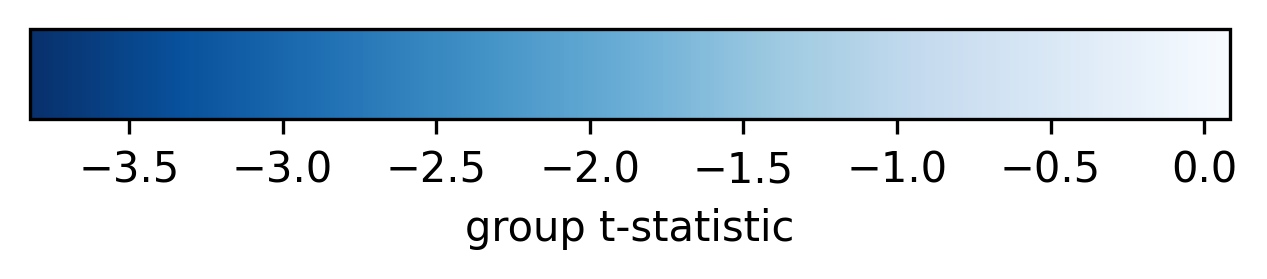

In [135]:
a = np.array([[min(color_values), max(color_values)]])
plt.figure(figsize=(5, 0.5), dpi=300)
img = plt.imshow(a, cmap=colormap)
plt.gca().set_visible(False)
cax = plt.axes([0.1, 0.2, 0.8, 0.6])
#cbar = plt.colorbar(orientation="horizontal", cax=cax, label='group t-statistic')
plt.colorbar(orientation="horizontal", cax=cax, label='group t-statistic')
#cbar.ax.get_yaxis().labelpad = 15
plt.savefig(f"out-figure_group-all_contrast-{contrast_label}_rungroup-final_network-{network_name}_revision_colorbar.svg")

## `contrast-fb` for cortical network

In [172]:
# get the beta map for the contrast of interest for each subject
network_name = network_list[0]
contrast_label = contrast_list[2]
print('network_name:', network_name)
print('contrast_label:', contrast_label)

statmap_earlythird_dict = {}
for sub_id in sub_list_nman:
    statmap_earlythird_dict[sub_id] = sorted(glob(l1_dir+f'/{sub_id}_space-{space_label}/grouped_runs/earlythird/*{contrast_label}_map-beta.nii.gz'))[0]
    
statmap_middlethird_dict = {}
for sub_id in sub_list_nman:
    statmap_middlethird_dict[sub_id] = sorted(glob(l1_dir+f'/{sub_id}_space-{space_label}/grouped_runs/middlethird/*{contrast_label}_map-beta.nii.gz'))[0]
    
statmap_latethird_dict = {}
for sub_id in sub_list_nman:
    statmap_latethird_dict[sub_id] = sorted(glob(l1_dir+f'/{sub_id}_space-{space_label}/grouped_runs/latethird/*{contrast_label}_map-beta.nii.gz'))[0]

network_name: auditory
contrast_label: fb-correct-vs-wrong


In [ ]:
# mask the stat maps per learning stage by region - ONLY RUN ONCE
'''
print(f'masking {contrast_label} stat maps for the {network_name} network')

print(f'creating dictionary for early learning stage')
roi_earlythird_mean_dict, mask_path_list = mask_stat_maps(region_dict[network_name], 
                                               statmap_earlythird_dict, 
                                               masks_dir, 
                                               network_name,
                                               space_label)

print(f'creating dictionary for middle learning stage')
roi_middlethird_mean_dict, mask_path_list = mask_stat_maps(region_dict[network_name], 
                                               statmap_middlethird_dict, 
                                               masks_dir, 
                                               network_name,
                                               space_label)

print(f'creating dictionary for final learning stage')
roi_latethird_mean_dict, mask_path_list = mask_stat_maps(region_dict[network_name], 
                                               statmap_latethird_dict, 
                                               masks_dir, 
                                               network_name,
                                               space_label)

# add `learning_stage` column and combine into single dataframe
roi_earlythird_df_long = make_stats_df(roi_earlythird_mean_dict, participants_nman_df, network_name)
roi_earlythird_df_long['learning_stage'] = 'early'
roi_middlethird_df_long = make_stats_df(roi_middlethird_mean_dict, participants_nman_df, network_name)
roi_middlethird_df_long['learning_stage'] = 'middle'
roi_latethird_df_long = make_stats_df(roi_latethird_mean_dict, participants_nman_df, network_name)
roi_latethird_df_long['learning_stage'] = 'final'

# combine into a single long dataframe
roi_df_long = pd.concat([roi_earlythird_df_long, roi_middlethird_df_long, roi_latethird_df_long],)

# save the DataFrame for easier access
out_fname = f'univariate-results_network-{network_name}_contrast-{contrast_label}.tsv'
roi_df_long.to_csv(os.path.join(group_out_dir, out_fname), sep='\t', index=False)
'''

In [173]:
# load the DataFrame if already exists
out_fname = f'univariate-results_network-{network_name}_contrast-{contrast_label}.tsv'
roi_df_long = pd.read_csv(os.path.join(group_out_dir, out_fname), sep='\t')

# create a bilateral-averaged dataframe (for across-contrast analysis)
feedback_cortex_df = bilateral_mean(roi_df_long)


In [174]:
roi_df_long.participant_id.unique()

array(['sub-FLT02', 'sub-FLT04', 'sub-FLT06', 'sub-FLT09', 'sub-FLT11',
       'sub-FLT12', 'sub-FLT13', 'sub-FLT14', 'sub-FLT20', 'sub-FLT25',
       'sub-FLT28', 'sub-FLT30'], dtype=object)

In [175]:
roi_df_long.region.unique()

array(['HG', 'PT', 'PP', 'STGp', 'STGa', 'ParsOp', 'ParsTri'],
      dtype=object)

In [176]:
non_mandarin_df = roi_df_long

In [177]:
plot_order = ['HG', 'PT', 'PP', 'STGp', 'STGa', 'ParsOp', 'ParsTri', ]

/scratch/slurm-8704965/ipykernel_4038713/1168370847.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center')


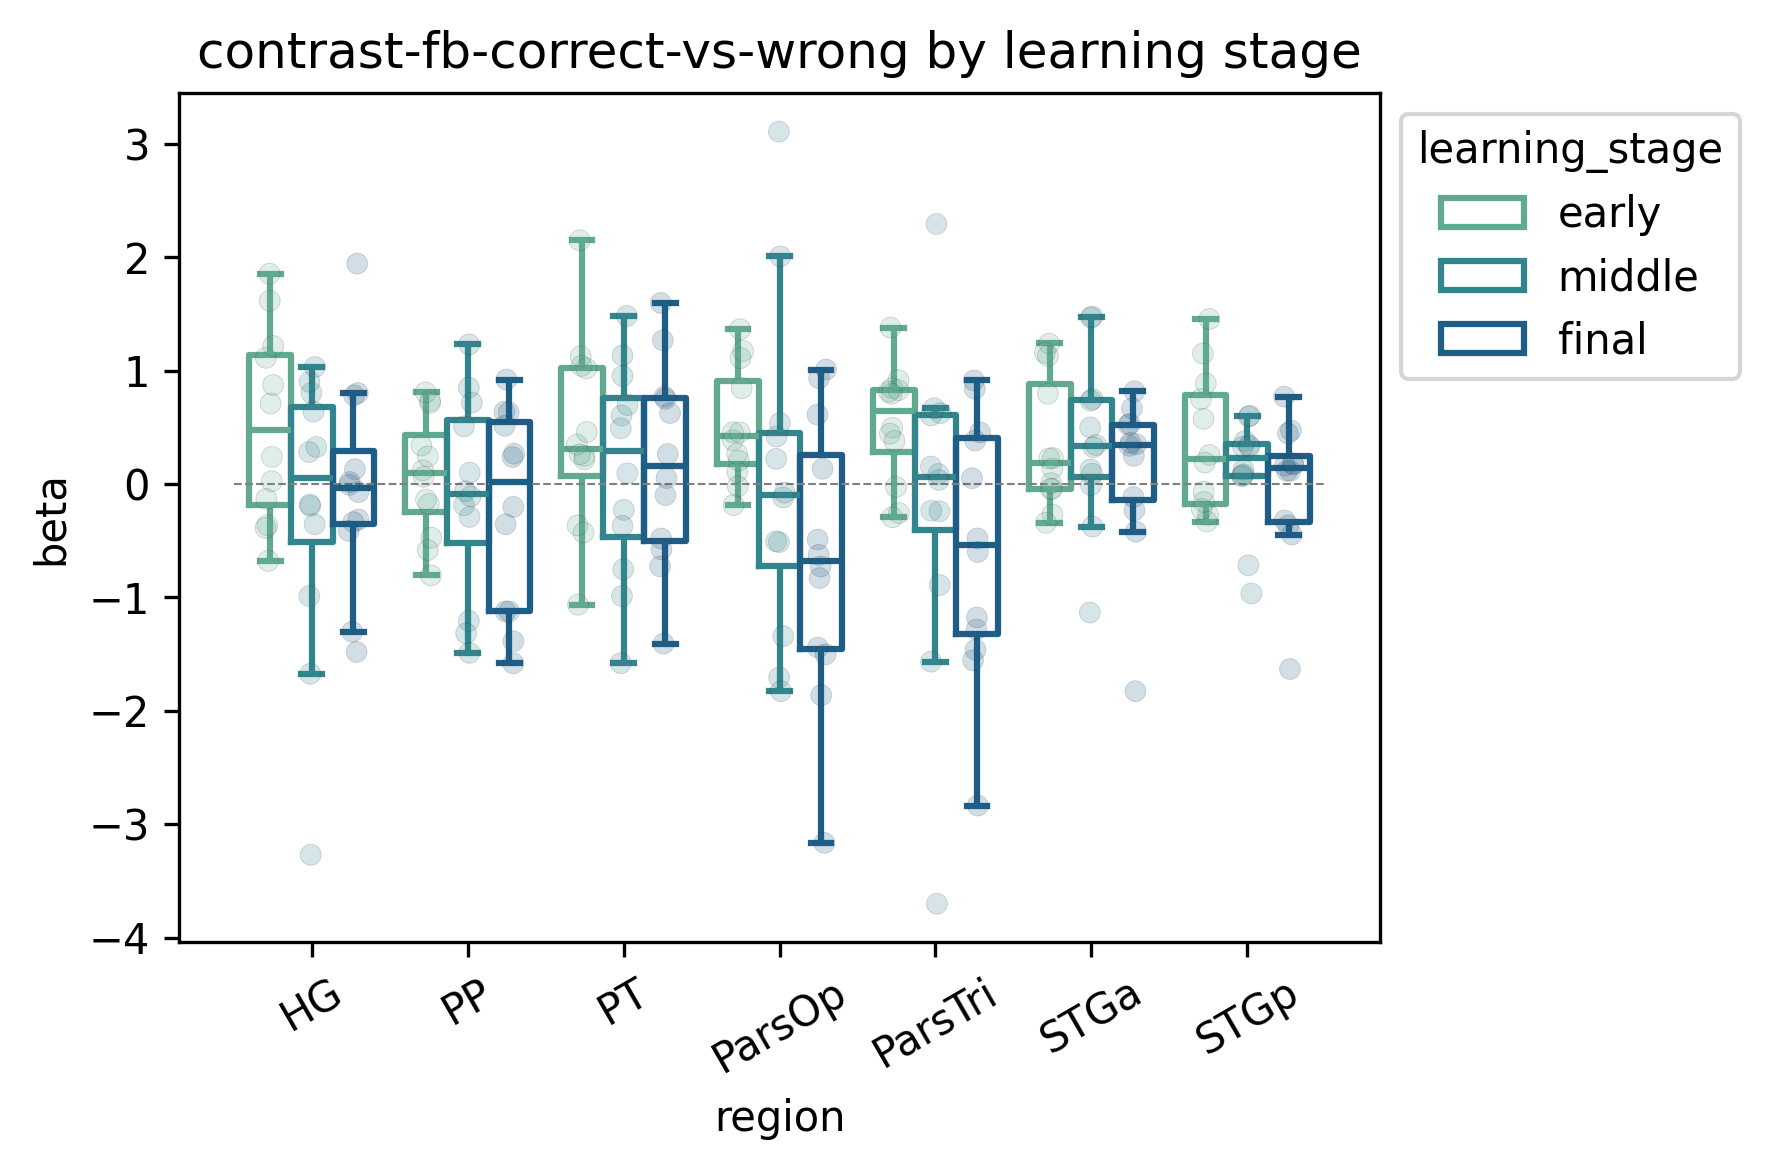

In [178]:
fig, ax = plt.subplots(1, 1, figsize=(6,4), dpi=300)

roi_df_collapsed = roi_df_long.groupby(["participant_id", "region", 'learning_stage'], 
                                       as_index=False).agg({"beta": "mean"})

sns.boxplot(data=roi_df_collapsed, 
              x='region', y='beta', 
              hue='learning_stage', hue_order=['early', 'middle', 'final'],
              palette='crest',
              fliersize = 0,            
              linewidth=1.5,
              fill=False,
              #legend=None,
              ax=ax);
sns.stripplot(data=roi_df_collapsed, 
              x='region', y='beta', 
              hue='learning_stage', hue_order=['early', 'middle', 'final'],
              palette='crest',
              dodge=True,
              linewidth=0.2,
              alpha=.2,
              legend=None,
              ax=ax);


xmin, xmax = ax.get_xlim()
ax.hlines(y=0, xmin=xmin, xmax=xmax, color='0.5', linestyle='--', linewidth=0.5)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_title(f'contrast-{contrast_label} by learning stage');
#ax.set_ylim([-5, 5])

fig.tight_layout()


### Brain-behavior correlations

In [179]:
# map runs to learning stages matching your thirds
stage_map = {'run-01': 'early', 'run-02': 'early',
             'run-03': 'middle', 'run-04': 'middle',
             'run-05': 'final', 'run-06': 'final'}

acc_df['learning_stage'] = acc_df['run'].map(stage_map)
acc_stage_df = acc_df.groupby(['participant_id', 'learning_stage'])['accuracy'].mean().reset_index()

#### Averaged across learning stages

In [180]:
# merge into roi_df_long — assumes participant_id and learning_stage columns exist in both
roi_df_bilateral = (roi_df_long.groupby(['participant_id', 'region'], as_index=False)['beta'].mean())
roi_behav_df = roi_df_bilateral.merge(acc_stage_df, on=['participant_id'])

# verify
roi_behav_df.groupby(['region']).size().unique()  # should be array([12])


array([36])

In [181]:
roi_behav_df.groupby(['region','learning_stage']).size().unique()


array([12])

In [182]:
results = []
for roi in roi_behav_df['region'].unique():
    sub_df = roi_behav_df[roi_behav_df['region'] == roi]
    r = pg.corr(sub_df['accuracy'], sub_df['beta'], method='pearson')
    results.append({
        'roi': roi,
        'r': r['r'].values[0],
        'p': r['p-val'].values[0],
        'n': r['n'].values[0],
        'stat_str': stat_str('r', r['r'].values[0], r['p-val'].values[0])
    })

behav_corr_df = pd.DataFrame(results)

In [183]:
behav_corr_df

,roi,r,p,n,stat_str
0,HG,0.0358,0.8359,36,"r = .04, p = .836"
1,PP,-0.2496,0.1421,36,"r = -.25, p = .142"
2,PT,0.1366,0.4269,36,"r = .14, p = .427"
3,ParsOp,-0.1329,0.4397,36,"r = -.13, p = .440"
4,ParsTri,-0.1292,0.4525,36,"r = -.13, p = .453"
5,STGa,-0.1527,0.3741,36,"r = -.15, p = .374"
6,STGp,-0.4236,0.0100,36,"r = -.42, p = .010"


#### Per learning stage

In [184]:
# merge into roi_df_long — assumes participant_id and learning_stage columns exist in both
roi_df_bilateral = (roi_df_long.groupby(['participant_id', 'region', 'learning_stage'], as_index=False)['beta'].mean())
roi_behav_df = roi_df_bilateral.merge(acc_stage_df, on=['participant_id', 'learning_stage'])

# verify
roi_behav_df.groupby(['region', 'learning_stage']).size().unique()  # should be array([12])


array([12])

In [185]:
results = []
for stage in ['early', 'middle', 'final']:
    stage_df = roi_behav_df[roi_behav_df['learning_stage'] == stage]
    for roi in plot_order: # stage_df['region'].unique():
        sub_df = stage_df[stage_df['region'] == roi]
        r = pg.corr(sub_df['accuracy'], sub_df['beta'], method='pearson')
        results.append({
            'roi': roi,
            'learning_stage': stage,
            'r': r['r'].values[0],
            'p': r['p-val'].values[0],
            'n': r['n'].values[0],
            'stat_str': stat_str('r', r['r'].values[0], r['p-val'].values[0])
        })

behav_corr_df = pd.DataFrame(results)

In [186]:
behav_corr_df

,roi,learning_stage,r,p,n,stat_str
0,HG,early,0.5881,0.0443,12,"r = .59, p = .044"
1,PT,early,0.7719,0.0033,12,"r = .77, p = .003"
2,PP,early,0.4227,0.1710,12,"r = .42, p = .171"
3,STGp,early,0.3497,0.2652,12,"r = .35, p = .265"
4,STGa,early,0.2745,0.3880,12,"r = .27, p = .388"
5,ParsOp,early,-0.1752,0.5860,12,"r = -.18, p = .586"
6,ParsTri,early,-0.0271,0.9333,12,"r = -.03, p = .933"
7,HG,middle,-0.2956,0.3509,12,"r = -.30, p = .351"
8,PT,middle,-0.0377,0.9073,12,"r = -.04, p = .907"
9,PP,middle,-0.2378,0.4568,12,"r = -.24, p = .457"


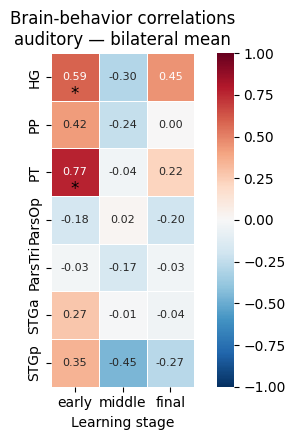

In [187]:
# pivot to ROI × stage matrix
r_matrix = behav_corr_df.pivot(index='roi', columns='learning_stage', values='r')[['early', 'middle', 'final']]
p_matrix = behav_corr_df.pivot(index='roi', columns='learning_stage', values='p')[['early', 'middle', 'final']]

fig, ax = plt.subplots(figsize=(5, len(r_matrix) * 0.5 + 1), dpi=100)
sns.heatmap(r_matrix, ax=ax, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, annot=True, fmt='.2f', annot_kws={'size': 8},
            square=True)

# mark significant cells with an asterisk
for i, roi in enumerate(r_matrix.index):
    for j, stage in enumerate(['early', 'middle', 'final']):
        p = p_matrix.loc[roi, stage]
        if p < 0.05:
            ax.text(j + 0.5, i + 0.85, '*', ha='center', va='center',
                    fontsize=12, color='black')

ax.set_title(f'Brain-behavior correlations\n{network_name} — bilateral mean')
ax.set_ylabel('')
ax.set_xlabel('Learning stage')
plt.tight_layout()

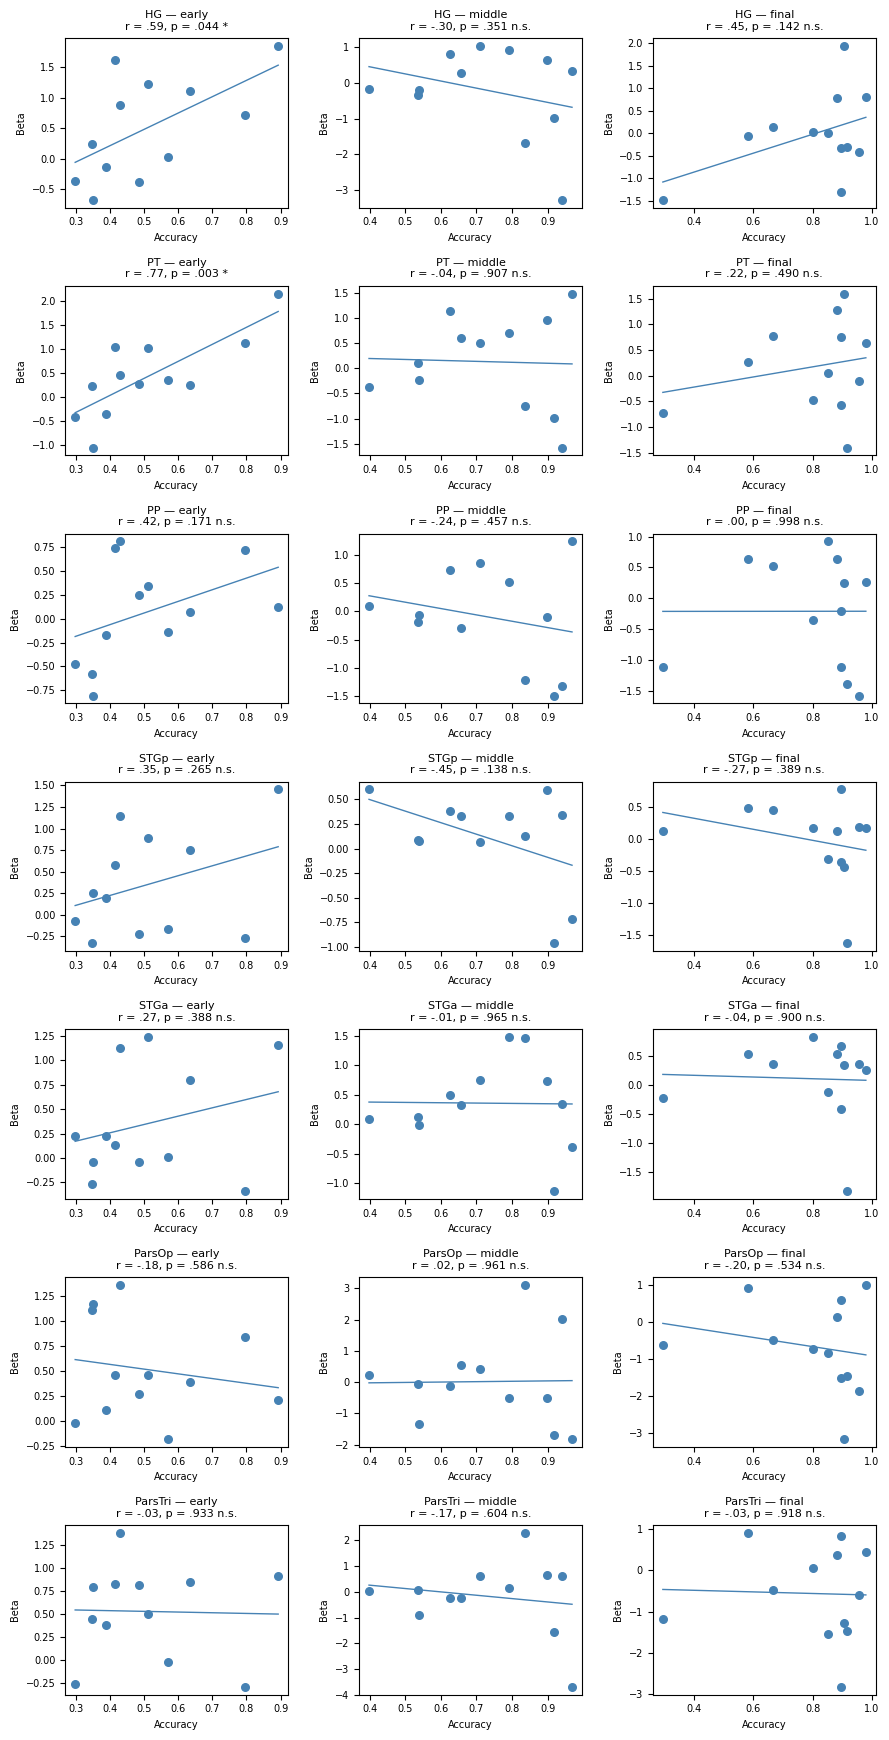

In [188]:
rois = behav_corr_df['roi'].unique()
stages = ['early', 'middle', 'final']
rois = plot_order # behav_corr_df['roi'].unique()

fig, axes = plt.subplots(len(rois), 3, figsize=(9, len(rois) * 2.5), dpi=100, sharex=False, sharey=False)

for ri, roi in enumerate(rois):
    for si, stage in enumerate(stages):
        ax = axes[ri, si]
        sub_df = roi_behav_df[(roi_behav_df['region'] == roi) & 
                              (roi_behav_df['learning_stage'] == stage)]
        
        ax.scatter(sub_df['accuracy'], sub_df['beta'], s=30, color='steelblue', zorder=3)
        
        # regression line
        m, b = np.polyfit(sub_df['accuracy'], sub_df['beta'], 1)
        x_range = np.linspace(sub_df['accuracy'].min(), sub_df['accuracy'].max(), 100)
        ax.plot(x_range, m * x_range + b, color='steelblue', linewidth=1)
        
        # stat annotation
        row = behav_corr_df[(behav_corr_df['roi'] == roi) & 
                            (behav_corr_df['learning_stage'] == stage)].iloc[0]
        p_str = '*' if row['p'] < 0.05 else 'n.s.'
        ax.set_title(f"{roi} — {stage}\n{row['stat_str']} {p_str}", fontsize=8)
        ax.set_xlabel('Accuracy', fontsize=7)
        ax.set_ylabel('Beta', fontsize=7)
        ax.tick_params(labelsize=7)

plt.tight_layout()


HG early: r = .59, p = .044 *
HG middle: r = -.30, p = .351 n.s.
HG final: r = .45, p = .142 n.s.
PT early: r = .77, p = .003 *
PT middle: r = -.04, p = .907 n.s.
PT final: r = .22, p = .490 n.s.
PP early: r = .42, p = .171 n.s.
PP middle: r = -.24, p = .457 n.s.
PP final: r = .00, p = .998 n.s.
STGp early: r = .35, p = .265 n.s.
STGp middle: r = -.45, p = .138 n.s.
STGp final: r = -.27, p = .389 n.s.
STGa early: r = .27, p = .388 n.s.
STGa middle: r = -.01, p = .965 n.s.
STGa final: r = -.04, p = .900 n.s.
ParsOp early: r = -.18, p = .586 n.s.
ParsOp middle: r = .02, p = .961 n.s.
ParsOp final: r = -.20, p = .534 n.s.
ParsTri early: r = -.03, p = .933 n.s.
ParsTri middle: r = -.17, p = .604 n.s.
ParsTri final: r = -.03, p = .918 n.s.


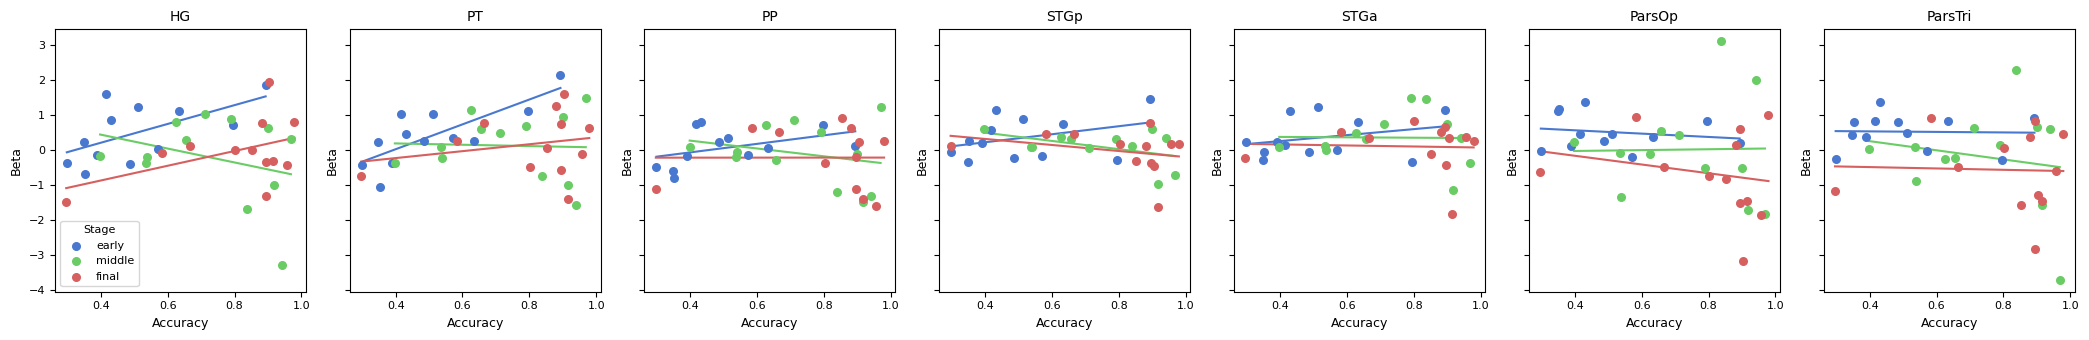

In [189]:
stage_colors = {'early': '#4878CF', 'middle': '#6ACC65', 'final': '#D65F5F'}
stages = ['early', 'middle', 'final']
rois = plot_order # behav_corr_df['roi'].unique()

fig, axes = plt.subplots(1, len(rois), figsize=(3 * len(rois), 3.5), dpi=100, sharey=True)
if len(rois) == 1:
    axes = [axes]

for ri, roi in enumerate(rois):
    ax = axes[ri]
    for stage in stages:
        color = stage_colors[stage]
        sub_df = roi_behav_df[(roi_behav_df['region'] == roi) &
                              (roi_behav_df['learning_stage'] == stage)]

        ax.scatter(sub_df['accuracy'], sub_df['beta'], s=30,
                   color=color, label=stage, zorder=3)

        m, b = np.polyfit(sub_df['accuracy'], sub_df['beta'], 1)
        x_range = np.linspace(sub_df['accuracy'].min(), sub_df['accuracy'].max(), 100)
        ax.plot(x_range, m * x_range + b, color=color, linewidth=1.5)

        # stat annotation per stage
        row = behav_corr_df[(behav_corr_df['roi'] == roi) &
                            (behav_corr_df['learning_stage'] == stage)].iloc[0]
        p_str = '*' if row['p'] < 0.05 else 'n.s.'
        print(f"{roi} {stage}: {row['stat_str']} {p_str}")

    ax.set_title(roi, fontsize=10)
    ax.set_xlabel('Accuracy', fontsize=9)
    ax.set_ylabel('Beta', fontsize=9)
    ax.tick_params(labelsize=8)

axes[0].legend(title='Stage', fontsize=8, title_fontsize=8)
plt.tight_layout()


### omnibus ANOVA stats

In [190]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import AnovaRM

# Mixed-Effects ANOVA with Hemisphere, Region, and Interaction
aov = AnovaRM(non_mandarin_df, 
              aggregate_func='mean',
              depvar='beta', 
              subject='participant_id', 
              within=['hemisphere', 'learning_stage','region', ]).fit()

# Display results
print('network:', network_name)
print('contrast:', contrast_label)
print(aov)


network: auditory
contrast: fb-correct-vs-wrong
                             Anova
                                 F Value  Num DF  Den DF  Pr > F
----------------------------------------------------------------
hemisphere                        0.0132  1.0000  11.0000 0.9107
learning_stage                    3.6421  2.0000  22.0000 0.0430
region                            1.4349  6.0000  66.0000 0.2147
hemisphere:learning_stage         1.3513  2.0000  22.0000 0.2796
hemisphere:region                 1.0940  6.0000  66.0000 0.3753
learning_stage:region             1.0788 12.0000 132.0000 0.3830
hemisphere:learning_stage:region  0.5993 12.0000 132.0000 0.8397



/bgfs/bchandrasekaran/krs228/software/miniconda3/envs/py3/lib/python3.9/site-packages/statsmodels/iolib/summary2.py:579: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  dat = dat.applymap(lambda x: _formatter(x, float_format))


In [191]:
aov.summary().tables[0]

,F Value,Num DF,Den DF,Pr > F
hemisphere,0.0132,1.0000,11.0000,0.9107
learning_stage,3.6421,2.0000,22.0000,0.0430
region,1.4349,6.0000,66.0000,0.2147
hemisphere:learning_stage,1.3513,2.0000,22.0000,0.2796
hemisphere:region,1.0940,6.0000,66.0000,0.3753
learning_stage:region,1.0788,12.0000,132.0000,0.3830
hemisphere:learning_stage:region,0.5993,12.0000,132.0000,0.8397


In [192]:
# pairwise by region, no learning stage

# Pairwise comparisons for region with FDR correction
pairwise_by_region_only = pg.pairwise_tests(data=non_mandarin_df,
                             dv='beta', 
                             within=['learning_stage', ],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise_by_region_only.columns)

# Display key columns (without 'effsize' and 'CIs' if missing)
print("\nPost-hoc Pairwise Comparisons:")
#print(pairwise_by_region_only)
pairwise_by_region_only[['Contrast', 'Contrast', 'A', 'B', 'T', 'dof', 'p-unc', 'p-corr', 'BF10']]  # Keep only available columns


Available columns: Index(['Contrast', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof', 'alternative',
       'p-unc', 'p-corr', 'p-adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Contrast,A,B,T,dof,p-unc,p-corr,BF10
0,learning_stage,learning_stage,early,final,2.5044,11.0000,0.0293,0.0878,2.51
1,learning_stage,learning_stage,early,middle,1.6660,11.0000,0.1239,0.1858,0.847
2,learning_stage,learning_stage,final,middle,-1.0143,11.0000,0.3322,0.3322,0.442


In [193]:
export_posthoc(pairwise_by_region_only, f'{contrast_label}_{network_name}_learning-stage', stats_out_dir)

,Contrast,A,B,t,df,p,p_fdr,stat_str,p_fdr_str
0,learning_stage,early,final,2.5044,11.0000,0.0293,0.0878,"t(11) = 2.50, p = .029",p = .088
1,learning_stage,early,middle,1.6660,11.0000,0.1239,0.1858,"t(11) = 1.67, p = .124",p = .186
2,learning_stage,final,middle,-1.0143,11.0000,0.3322,0.3322,"t(11) = -1.01, p = .332",p = .332


#### Collapse (average) over non-significant factors

In [194]:
roi_df_collapsed = roi_df_long.groupby(["participant_id", "region", 'learning_stage'], 
                                       as_index=False).agg({"beta": "mean"})


In [195]:
from statsmodels.stats.multitest import multipletests
from scipy.stats import ttest_1samp


# Collect p-values
p_values = []
t_stats = []
comparisons = []

for region_stage, data in roi_df_collapsed.groupby(["region",'learning_stage']):
    #print(region_stage)
    t_stat, p_val = ttest_1samp(data["beta"], 0)
    p_values.append(p_val)
    comparisons.append((region_stage[0], region_stage[1], t_stat))
    t_stats.append(t_stat)

# Apply FDR correction
_, p_corrected, _, _ = multipletests(p_values, method='fdr_bh')

# Print corrected results
for (region, stage, t_stat), p_val_corr in zip(comparisons, p_corrected):
    print(f"Region: {region}, stage: {stage}, t = {t_stat:.2f}; corrected p = {p_val_corr:.4f}")


Region: HG, stage: early, t = 2.09; corrected p = 0.2710
Region: HG, stage: final, t = -0.08; corrected p = 0.9669
Region: HG, stage: middle, t = -0.62; corrected p = 0.8032
Region: PP, stage: early, t = 0.47; corrected p = 0.8032
Region: PP, stage: final, t = -0.83; corrected p = 0.8032
Region: PP, stage: middle, t = -0.41; corrected p = 0.8032
Region: PT, stage: early, t = 1.71; corrected p = 0.2710
Region: PT, stage: final, t = 0.67; corrected p = 0.8032
Region: PT, stage: middle, t = 0.48; corrected p = 0.8032
Region: ParsOp, stage: early, t = 3.57; corrected p = 0.0464
Region: ParsOp, stage: final, t = -1.86; corrected p = 0.2710
Region: ParsOp, stage: middle, t = 0.04; corrected p = 0.9669
Region: ParsTri, stage: early, t = 3.59; corrected p = 0.0464
Region: ParsTri, stage: final, t = -1.71; corrected p = 0.2710
Region: ParsTri, stage: middle, t = -0.43; corrected p = 0.8032
Region: STGa, stage: early, t = 2.13; corrected p = 0.2710
Region: STGa, stage: final, t = 0.51; corrected

In [196]:
# Collect p-values
p_values = []
t_stats = []
comparisons = []

for region, data in roi_df_collapsed.groupby(["region"]):
    t_stat, p_val = ttest_1samp(data["beta"], 0)
    p_values.append(p_val)
    comparisons.append((region[0], t_stat))
    t_stats.append(t_stat)

# Apply FDR correction
_, p_corrected, _, _ = multipletests(p_values, method='fdr_bh')

# Print corrected results
for (region, t_stat), p_val_corr in zip(comparisons, p_corrected):
    print(f"Region: {region}, t = {t_stat:.2f}; corrected p = {p_val_corr:.4f}")


Region: HG, t = 0.51; corrected p = 0.8298
Region: PP, t = -0.64; corrected p = 0.8298
Region: PT, t = 1.65; corrected p = 0.3400
Region: ParsOp, t = -0.22; corrected p = 0.8298
Region: ParsTri, t = -0.37; corrected p = 0.8298
Region: STGa, t = 2.45; corrected p = 0.1354
Region: STGp, t = 1.49; corrected p = 0.3400


In [197]:
_records = [{'region': c[0], 't': c[1], 'df': len(sub_list_nman) - 1, 'p': p}
            for c, p in zip(comparisons, p_values)]
export_ttests(_records, f'{contrast_label}_{network_name}_baseline_by_region', stats_out_dir)

,region,t,df,p,p_fdr,stat_str,p_fdr_str
0,HG,0.5110,11,0.6126,0.8298,"t(11) = 0.51, p = .613",p = .830
1,PP,-0.6398,11,0.5265,0.8298,"t(11) = -0.64, p = .526",p = .830
2,PT,1.6497,11,0.1080,0.3400,"t(11) = 1.65, p = .108",p = .340
3,ParsOp,-0.2165,11,0.8298,0.8298,"t(11) = -0.22, p = .830",p = .830
4,ParsTri,-0.3669,11,0.7159,0.8298,"t(11) = -0.37, p = .716",p = .830
5,STGa,2.4520,11,0.0193,0.1354,"t(11) = 2.45, p = .019",p = .135
6,STGp,1.4880,11,0.1457,0.3400,"t(11) = 1.49, p = .146",p = .340


In [198]:
# Collect results
results = []

for region, data in roi_df_collapsed.groupby("region"):
    t_stat, p_val = ttest_1samp(data["beta"], 0)
    results.append({
        "region": region,
        "t_stat": t_stat,
        "p_val": p_val
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Apply FDR correction
results_df["p_val_fdr"] = multipletests(results_df["p_val"], method="fdr_bh")[1]

# Print or export the table
results_df

# Optional: export
# results_df.to_csv("roi_stats.csv", index=False)
# results_df.to_excel("roi_stats.xlsx", index=False)


,region,t_stat,p_val,p_val_fdr
0,HG,0.5110,0.6126,0.8298
1,PP,-0.6398,0.5265,0.8298
2,PT,1.6497,0.1080,0.3400
3,ParsOp,-0.2165,0.8298,0.8298
4,ParsTri,-0.3669,0.7159,0.8298
5,STGa,2.4520,0.0193,0.1354
6,STGp,1.4880,0.1457,0.3400


In [199]:
_export = results_df.rename(columns={'t_stat': 't', 'p_val': 'p'}).copy()
_export['df'] = len(sub_list_nman) - 1
export_ttests(_export.to_dict('records'), f'{contrast_label}_{network_name}_baseline_by_region', stats_out_dir)

,region,t,p,p_val_fdr,df,p_fdr,stat_str,p_fdr_str
0,HG,0.5110,0.6126,0.8298,11,0.8298,"t(11) = 0.51, p = .613",p = .830
1,PP,-0.6398,0.5265,0.8298,11,0.8298,"t(11) = -0.64, p = .526",p = .830
2,PT,1.6497,0.1080,0.3400,11,0.3400,"t(11) = 1.65, p = .108",p = .340
3,ParsOp,-0.2165,0.8298,0.8298,11,0.8298,"t(11) = -0.22, p = .830",p = .830
4,ParsTri,-0.3669,0.7159,0.8298,11,0.8298,"t(11) = -0.37, p = .716",p = .830
5,STGa,2.4520,0.0193,0.1354,11,0.1354,"t(11) = 2.45, p = .019",p = .135
6,STGp,1.4880,0.1457,0.3400,11,0.3400,"t(11) = 1.49, p = .146",p = .340


In [200]:
# Collect results
results = []

for (region, stage), data in roi_df_collapsed.groupby(["region", "learning_stage"]):
    t_stat, p_val = ttest_1samp(data["beta"], 0)
    results.append({
        "region": region,
        "learning_stage": stage,
        "t_stat": t_stat,
        "p_val": p_val
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Apply FDR correction
results_df["p_val_fdr"] = multipletests(results_df["p_val"], method="fdr_bh")[1]

stage_order = ["early", "middle", "final"]

results_df["learning_stage"] = pd.Categorical(
    results_df["learning_stage"],
    categories=stage_order,
    ordered=True
)

# Now sort
results_df = results_df.sort_values(["learning_stage", "region"])


# Print or export the table
results_df

# Optional: export
# results_df.to_csv("roi_stats.csv", index=False)
# results_df.to_excel("roi_stats.xlsx", index=False)


,region,learning_stage,t_stat,p_val,p_val_fdr
0,HG,early,2.0945,0.0602,0.2710
3,PP,early,0.4657,0.6505,0.8032
6,PT,early,1.7125,0.1148,0.2710
9,ParsOp,early,3.5671,0.0044,0.0464
12,ParsTri,early,3.5931,0.0042,0.0464
15,STGa,early,2.1317,0.0564,0.2710
18,STGp,early,2.0193,0.0685,0.2710
2,HG,middle,-0.6168,0.5499,0.8032
5,PP,middle,-0.4117,0.6885,0.8032
8,PT,middle,0.4794,0.6410,0.8032


In [201]:
_export = results_df.rename(columns={'t_stat': 't', 'p_val': 'p'}).copy()
_export['df'] = len(sub_list_nman) - 1
export_ttests(_export.to_dict('records'), f'{contrast_label}_{network_name}_baseline_by_region_stage', stats_out_dir)

,region,learning_stage,t,p,p_val_fdr,df,p_fdr,stat_str,p_fdr_str
0,HG,early,2.0945,0.0602,0.2710,11,0.2710,"t(11) = 2.09, p = .060",p = .271
1,PP,early,0.4657,0.6505,0.8032,11,0.8032,"t(11) = 0.47, p = .651",p = .803
2,PT,early,1.7125,0.1148,0.2710,11,0.2710,"t(11) = 1.71, p = .115",p = .271
3,ParsOp,early,3.5671,0.0044,0.0464,11,0.0464,"t(11) = 3.57, p = .004",p = .046
4,ParsTri,early,3.5931,0.0042,0.0464,11,0.0464,"t(11) = 3.59, p = .004",p = .046
5,STGa,early,2.1317,0.0564,0.2710,11,0.2710,"t(11) = 2.13, p = .056",p = .271
6,STGp,early,2.0193,0.0685,0.2710,11,0.2710,"t(11) = 2.02, p = .069",p = .271
7,HG,middle,-0.6168,0.5499,0.8032,11,0.8032,"t(11) = -0.62, p = .550",p = .803
8,PP,middle,-0.4117,0.6885,0.8032,11,0.8032,"t(11) = -0.41, p = .688",p = .803
9,PT,middle,0.4794,0.6410,0.8032,11,0.8032,"t(11) = 0.48, p = .641",p = .803


## Compare contrasts

In [340]:
sound_striatum_df['event_type'] = 'sound'
sound_striatum_df['network'] = 'striatum'

feedback_striatum_df['event_type'] = 'feedback'
feedback_striatum_df['network'] = 'striatum'

sound_cortex_df['event_type'] = 'sound'
sound_cortex_df['network'] = 'cortex'

feedback_cortex_df['event_type'] = 'feedback'
feedback_cortex_df['network'] = 'cortex'

all_df = pd.concat([sound_striatum_df, feedback_striatum_df,
                    sound_cortex_df, feedback_cortex_df])


In [342]:
from statsmodels.stats.anova import AnovaRM

results = []
for roi in all_df['region'].unique():
    sub_df = all_df[all_df['region'] == roi]
    
    aov = AnovaRM(data=sub_df, depvar='beta', subject='participant_id',
                  within=['event_type', 'learning_stage']).fit()
    
    table = aov.anova_table
    
    for effect in ['event_type', 'learning_stage', 'event_type:learning_stage']:
        row = table.loc[effect]
        results.append({
            'roi': roi,
            'effect': effect,
            'F': row['F Value'],
            'df_num': row['Num DF'],
            'df_den': row['Den DF'],
            'p': row['Pr > F'],
            'stat_str': stat_str('F', int(row['Num DF']), int(row['Den DF']),
                                 row['F Value'], row['Pr > F'])
        })

interaction_df = pd.DataFrame(results)


In [357]:
interaction_df.sort_values(by=['effect', 'roi'])

,roi,effect,F,df_num,df_den,p,stat_str
12,HG,event_type,21.4772,1.0000,11.0000,0.0007,"F(1, 11) = 21.48, p < .001"
15,PP,event_type,37.4064,1.0000,11.0000,0.0001,"F(1, 11) = 37.41, p < .001"
18,PT,event_type,29.9952,1.0000,11.0000,0.0002,"F(1, 11) = 30.00, p < .001"
21,ParsOp,event_type,8.9623,1.0000,11.0000,0.0122,"F(1, 11) = 8.96, p = .012"
24,ParsTri,event_type,0.0005,1.0000,11.0000,0.9823,"F(1, 11) = 0.00, p = .982"
27,STGa,event_type,30.6129,1.0000,11.0000,0.0002,"F(1, 11) = 30.61, p < .001"
30,STGp,event_type,52.3977,1.0000,11.0000,0.0000,"F(1, 11) = 52.40, p < .001"
0,aCAU,event_type,9.0402,1.0000,11.0000,0.0119,"F(1, 11) = 9.04, p = .012"
3,aPUT,event_type,77.6334,1.0000,11.0000,0.0000,"F(1, 11) = 77.63, p < .001"
6,pCAU,event_type,4.1195,1.0000,11.0000,0.0673,"F(1, 11) = 4.12, p = .067"


In [344]:
from statsmodels.stats.anova import AnovaRM

pput_df = all_df[all_df['region'] == 'pPUT']

for event in ['sound', 'feedback']:
    sub_df = pput_df[pput_df['event_type'] == event]
    aov = AnovaRM(data=sub_df, depvar='beta', subject='participant_id',
                  within=['learning_stage']).fit()
    print(f'\n--- pPUT {event} ---')
    print(aov.anova_table)



--- pPUT sound ---
                F Value  Num DF  Den DF  Pr > F
learning_stage   9.9938  2.0000 22.0000  0.0008

--- pPUT feedback ---
                F Value  Num DF  Den DF  Pr > F
learning_stage   2.8966  2.0000 22.0000  0.0764


In [362]:
from statsmodels.stats.anova import AnovaRM

pput_df = all_df[all_df['region'] == 'pPUT']

for learning_stage in ['early', 'middle', 'final']:
    sub_df = pput_df[pput_df['learning_stage'] == learning_stage]
    aov = AnovaRM(data=sub_df, depvar='beta', subject='participant_id',
                  within=['event_type']).fit()
    print(f'\n--- pPUT {learning_stage} ---')
    print(aov.anova_table)


--- pPUT early ---
            F Value  Num DF  Den DF  Pr > F
event_type  15.6661  1.0000 11.0000  0.0022

--- pPUT middle ---
            F Value  Num DF  Den DF  Pr > F
event_type   0.0690  1.0000 11.0000  0.7977

--- pPUT final ---
            F Value  Num DF  Den DF  Pr > F
event_type   1.6603  1.0000 11.0000  0.2240


In [352]:
from scipy.stats import ttest_rel

stage_pairs = [('early', 'middle'), ('middle', 'final'), ('early', 'final')]

for event in ['sound', 'feedback']:
    print(f'\n--- pPUT {event} ---')
    sub_df = pput_df[pput_df['event_type'] == event]
    
    for s1, s2 in stage_pairs:
        vals1 = sub_df[sub_df['learning_stage'] == s1].set_index('participant_id')['beta']
        vals2 = sub_df[sub_df['learning_stage'] == s2].set_index('participant_id')['beta']
        # align by subject
        vals1, vals2 = vals1.align(vals2)
        t, p = ttest_rel(vals1, vals2)
        print(f"  {s1} vs {s2}: {stat_str('t', 11, t, p)}")



--- pPUT sound ---
  early vs middle: t(11) = 4.04, p = .002
  middle vs final: t(11) = -1.67, p = .123
  early vs final: t(11) = 2.70, p = .021

--- pPUT feedback ---
  early vs middle: t(11) = 1.31, p = .217
  middle vs final: t(11) = 1.11, p = .290
  early vs final: t(11) = 2.34, p = .039


In [366]:
from scipy.stats import ttest_1samp

for event in ['sound', 'feedback']:
    print(f'\n--- pPUT {event} ---')
    sub_df = pput_df[pput_df['event_type'] == event]
    
    for learning_stage in ['early', 'middle', 'final']:
        vals1 = sub_df[sub_df['learning_stage'] == learning_stage].set_index('participant_id')['beta']
        t, p = ttest_1samp(vals1, popmean=0)
        print(f"  {event} vs {0}: {stat_str('t', 11, t, p)}")



--- pPUT sound ---
  sound vs 0: t(11) = 5.97, p < .001
  sound vs 0: t(11) = 0.78, p = .450
  sound vs 0: t(11) = 1.44, p = .178

--- pPUT feedback ---
  feedback vs 0: t(11) = 2.76, p = .019
  feedback vs 0: t(11) = 1.28, p = .227
  feedback vs 0: t(11) = -0.06, p = .950


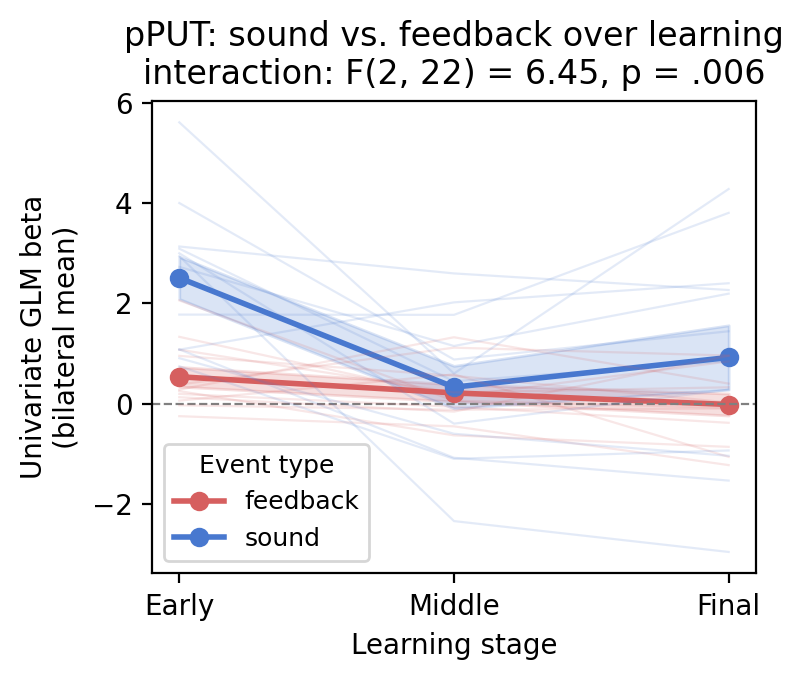

In [349]:
import matplotlib.pyplot as plt
import numpy as np

pput_df = all_df[all_df['region'] == 'pPUT']

# compute means and SEM across subjects
summary = (pput_df.groupby(['event_type', 'learning_stage'])['beta']
           .agg(['mean', 'sem'])
           .reset_index())

stage_order = ['early', 'middle', 'final']
stage_x = {s: i for i, s in enumerate(stage_order)}
event_colors = {'sound': '#4878CF', 'feedback': '#D65F5F'}

fig, ax = plt.subplots(figsize=(4, 3.5), dpi=200)

for event, grp in summary.groupby('event_type'):
    grp = grp.set_index('learning_stage').loc[stage_order].reset_index()
    x = [stage_x[s] for s in grp['learning_stage']]
    color = event_colors[event]
    
    ax.plot(x, grp['mean'], marker='o', color=color, label=event, linewidth=2)
    ax.fill_between(x,
                    grp['mean'] - grp['sem'],
                    grp['mean'] + grp['sem'],
                    alpha=0.2, color=color)

ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['Early', 'Middle', 'Final'])
ax.set_xlabel('Learning stage')
ax.set_ylabel('Univariate GLM beta\n(bilateral mean)')
ax.set_title('pPUT: sound vs. feedback over learning\n'
             f"interaction: {interaction_df[(interaction_df['roi']=='pPUT') & (interaction_df['effect']=='event_type:learning_stage')]['stat_str'].values[0]}")
ax.legend(title='Event type', fontsize=9, title_fontsize=9)
ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')

for event, grp in pput_df.groupby('event_type'):
    grp = grp.set_index('learning_stage').loc[stage_order].reset_index() \
             if False else grp  # reorder not needed here
    color = event_colors[event]
    for sub, sdf in grp.groupby('participant_id'):
        sdf = sdf.set_index('learning_stage').reindex(stage_order).reset_index()
        ax.plot([stage_x[s] for s in sdf['learning_stage']],
                sdf['beta'], color=color, alpha=0.15, linewidth=0.8)


plt.tight_layout()
